In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from vivarium import Artifact

from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import PercentFormatter


!date
!whoami
!uname -a
!pwd

Fri Mar 27 17:48:07 PDT 2026
ndbs
Linux int-slurm-sarchive-p0008 5.4.0-216-generic #236-Ubuntu SMP Fri Apr 11 19:53:21 UTC 2025 x86_64 x86_64 x86_64 GNU/Linux
/mnt/share/code/ndbs/vivarium_research_alzheimers/plots


In [2]:
VAL_COLS = ["Mean", "95% UI Lower", "95% UI Upper"]
UI_COLS = ["95% UI Lower", "95% UI Upper"]
AGES = [
    # "25_to_59",
    # "60_to_64",
    "30_to_64",
    "65_to_69",
    "70_to_74",
    "75_to_79",
    "80_to_84",
    "85_to_89",
    "90_to_94",
    "95_plus",
]

In [3]:
results_dir_old = "/snfs1/Project/simulation_science/alzheimers/results_10_31_2025"
results_dir_v1 = (
    "/snfs1/Project/simulation_science/alzheimers/results_in_progress/version1"
)
results_dir_v2 = (
    "/snfs1/Project/simulation_science/alzheimers/results_in_progress/version2"
)
results_dir_v3 = (
    # Previous "final" results from around Dec. 1, 2025
    "/snfs1/Project/simulation_science/alzheimers/results_in_progress/version3"
)
results_dir_new = "/snfs1/Project/simulation_science/alzheimers/results_in_progress"
inc = pd.read_csv(Path(results_dir_new) / "incidence.csv")
prev = pd.read_csv(Path(results_dir_new) / "prevalence.csv")
deaths = pd.read_csv(Path(results_dir_new) / "deaths.csv")
res = pd.concat([prev, inc, deaths])

# Define additional column sets based on most recent data
DRAW_COLS = [c for c in res if c.startswith("draw_")]
INDEX_COLS = res.columns.difference(VAL_COLS + DRAW_COLS).to_list()

v2_res = pd.concat(
    [
        pd.read_csv(Path(results_dir_v2) / "prevalence.csv"),
        pd.read_csv(Path(results_dir_v2) / "incidence.csv"),
        pd.read_csv(Path(results_dir_v2) / "deaths.csv"),
    ]
)
v3_res = pd.concat(
    [
        pd.read_csv(Path(results_dir_v3) / "prevalence.csv"),
        pd.read_csv(Path(results_dir_v3) / "incidence.csv"),
        pd.read_csv(Path(results_dir_v3) / "deaths.csv"),
    ]
)
res

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
0,2025,Brazil,65_to_69,Female,Preclinical AD,Reference,Prevalence,Number,187036.882381,162433.461894,...,196009.840992,193474.100426,182652.646418,182955.906262,173085.356946,185232.393837,185910.998505,201850.237628,184571.056742,163842.155638
1,2025,Brazil,65_to_69,Male,Preclinical AD,Reference,Prevalence,Number,72372.922748,52305.030077,...,76462.226069,94882.702103,76860.892904,92282.676043,50414.205521,75152.987224,74821.443380,86088.717948,66905.459162,60027.447762
2,2025,Brazil,65_to_69,Both,Preclinical AD,Reference,Prevalence,Number,259409.805129,222965.015052,...,272472.067061,288356.802529,259513.539322,275238.582305,223499.562468,260385.381061,260732.441885,287938.955576,251476.515903,223869.603400
3,2025,Brazil,65_to_69,Female,Preclinical AD,BBBM Testing Only,Prevalence,Number,187036.882381,162433.461894,...,196009.840992,193474.100426,182652.646418,182955.906262,173085.356946,185232.393837,185910.998505,201850.237628,184571.056742,163842.155638
4,2025,Brazil,65_to_69,Male,Preclinical AD,BBBM Testing Only,Prevalence,Number,72372.922748,52305.030077,...,76462.226069,94882.702103,76860.892904,92282.676043,50414.205521,75152.987224,74821.443380,86088.717948,66905.459162,60027.447762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341995,2100,United States of America,65_plus,Male,AD Dementia,BBBM Testing Only,Averted Deaths Associated with AD,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
341996,2100,United States of America,65_plus,Both,AD Dementia,BBBM Testing Only,Averted Deaths Associated with AD,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
341997,2100,United States of America,65_plus,Female,AD Dementia,BBBM Testing and Treatment,Averted Deaths Associated with AD,Rate,0.000149,0.000110,...,0.000124,0.000166,0.000121,0.000148,0.000142,0.000163,0.000156,0.000154,0.000165,0.000175
341998,2100,United States of America,65_plus,Male,AD Dementia,BBBM Testing and Treatment,Averted Deaths Associated with AD,Rate,0.000094,0.000064,...,0.000082,0.000099,0.000074,0.000081,0.000094,0.000100,0.000104,0.000120,0.000093,0.000104


In [4]:
display(
    res.query(
        "Year == 2065 & Location == 'United States of America' & Age == '75_to_79' & Sex == 'Female' & `Disease Stage` == 'AD Dementia' & Scenario == 'Reference' & Measure == 'Prevalence' & Metric == 'Number'"
    )
)
display(
    v2_res.query(
        "Year == 2065 & Location == 'United States of America' & Age == '75_to_79' & Sex == 'Female' & `Disease Stage` == 'AD Dementia' & Scenario == 'Reference' & Measure == 'Prevalence' & Metric == 'Number'"
    )
)

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
204120,2065,United States of America,75_to_79,Female,AD Dementia,Reference,Prevalence,Number,593251.488427,537907.683143,...,645322.743109,636848.641368,673970.555016,635395.124244,587952.251117,617618.249716,565957.715695,576784.216821,590418.975679,577059.088627


,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,95% UI Upper
299666,2065,United States of America,75_to_79,Female,AD Dementia,Reference,Prevalence,Number,298670.943703,277521.905124,316415.902332


In [5]:
# Check 2099 vs 2100 data
display(
    res[
        (res["Year"] == 2099)
        & ((res["Age"] == "70_to_74") | (res["Age"] == "70_to_75"))
        & (res["Location"] == "United States of America")
        & (res["Sex"] == "Female")
    ]
)
display(
    res[
        (res["Year"] == 2100)
        & ((res["Age"] == "70_to_74") | (res["Age"] == "70_to_75"))
        & (res["Location"] == "United States of America")
        & (res["Sex"] == "Female")
    ]
)

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
132180,2099,United States of America,70_to_74,Female,Preclinical AD,Reference,Prevalence,Number,768945.778361,699118.300006,...,800980.438833,816731.705885,872154.252045,783899.133965,749493.542870,788351.285872,726731.049856,770903.838102,810615.491092,784153.191461
132183,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,Prevalence,Number,768945.778361,699118.300006,...,800980.438833,816731.705885,872154.252045,783899.133965,749493.542870,788351.285872,726731.049856,770903.838102,810615.491092,784153.191461
132186,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,Prevalence,Number,792731.318759,722269.026133,...,823651.686114,844295.496870,893070.872922,809936.189260,771716.364026,815304.351840,751132.101705,795314.455974,836059.307153,809775.061678
132189,2099,United States of America,70_to_74,Female,Preclinical AD,Reference,Prevalence,Rate,0.085307,0.080267,...,0.087748,0.088233,0.089086,0.088271,0.086994,0.087174,0.086444,0.085529,0.088352,0.089600
132192,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,Prevalence,Rate,0.085307,0.080267,...,0.087748,0.088233,0.089086,0.088271,0.086994,0.087174,0.086444,0.085529,0.088352,0.089600
132195,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,Prevalence,Rate,0.087938,0.082803,...,0.090224,0.091202,0.091214,0.091193,0.089563,0.090142,0.089334,0.088226,0.091112,0.092515
132198,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,Change in Prevalence from Reference,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132201,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,Change in Prevalence from Reference,Number,23785.540397,17615.193925,...,22671.247281,27563.790985,20916.620877,26037.055295,22222.821156,26953.065968,24401.051849,24410.617872,25443.816061,25621.870217
132204,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,Change in Prevalence from Reference,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132207,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,Change in Prevalence from Reference,Rate,0.002640,0.001971,...,0.002483,0.002977,0.002136,0.002932,0.002579,0.002980,0.002902,0.002708,0.002773,0.002927


,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
132210,2100,United States of America,70_to_74,Female,Preclinical AD,Reference,Prevalence,Number,768484.369977,699251.173385,...,800014.462931,817914.534763,872981.105415,783356.922750,747954.042620,788031.476015,726462.296709,768456.477279,809697.168117,784598.141840
132213,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,Prevalence,Number,768484.369977,699251.173385,...,800014.462931,817914.534763,872981.105415,783356.922750,747954.042620,788031.476015,726462.296709,768456.477279,809697.168117,784598.141840
132216,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,Prevalence,Number,792508.865385,722734.409829,...,822597.209497,845755.611862,894131.144228,809526.801598,770459.555634,815235.301984,750604.998759,793085.708760,835389.927153,810701.320247
132219,2100,United States of America,70_to_74,Female,Preclinical AD,Reference,Prevalence,Rate,0.085257,0.080172,...,0.087642,0.088361,0.089171,0.088210,0.086816,0.087139,0.086412,0.085257,0.088252,0.089651
132222,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,Prevalence,Rate,0.085257,0.080172,...,0.087642,0.088361,0.089171,0.088210,0.086816,0.087139,0.086412,0.085257,0.088252,0.089651
132225,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,Prevalence,Rate,0.087913,0.082659,...,0.090107,0.091359,0.091323,0.091147,0.089417,0.090134,0.089271,0.087979,0.091040,0.092621
132228,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,Change in Prevalence from Reference,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132231,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,Change in Prevalence from Reference,Number,24024.495408,17662.941838,...,22582.746565,27841.077099,21150.038813,26169.878848,22505.513015,27203.825970,24142.702050,24629.231481,25692.759036,26103.178408
132234,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,Change in Prevalence from Reference,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132237,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,Change in Prevalence from Reference,Rate,0.002666,0.001983,...,0.002474,0.003007,0.002160,0.002947,0.002612,0.003008,0.002871,0.002732,0.002800,0.002982


In [6]:
res.Measure.unique()

array(['Prevalence', 'Change in Prevalence from Reference', 'Incidence',
       'Deaths Associated with AD', 'Averted Deaths Associated with AD'],
      dtype=object)

### Confirm that 25_to_29 age group contains all 0s, but 30_to_34 doesn't

In [7]:
res.query("Age == '25_to_29'").Mean.describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Mean, dtype: float64

In [8]:
res.query("Age == '30_to_34'").Mean.describe()

count    132240.000000
mean          0.013783
std           0.101518
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           2.947313
Name: Mean, dtype: float64

In [9]:
v2_res.query("Age == '25_to_29'").Mean.describe()

count    69920.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: Mean, dtype: float64

In [10]:
v2_res.query("Age == '30_to_34'").Mean.describe()

count    6.992000e+04
mean     2.841746e-02
std      1.520738e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.473181e-08
max      2.902464e+00
Name: Mean, dtype: float64

# Define function for filtering and aggregating/stratifying results

In [11]:
def filter_results(
    df,
    keep_stratified,
    year=None,
    location=None,
    age=None,
    sex=None,
    stage=None,
    scenario=["Reference"],
    measure=None,
    metric=["Number"],
):
    # df may or may not have draw columns, depending on version of .csv files
    draw_cols = [c for c in df if c.startswith("draw_")]
    if "Age" in df.columns:
        # Use .assign to not overwrite input dataframe
        df = df.assign(Age=df["Age"].replace(
            [
                "25_to_29", # These are now all 0s, we'll pretend like they don't exist
                "30_to_34",
                "35_to_39",
                "40_to_44",
                "45_to_49",
                "50_to_54",
                "55_to_59",
                "60_to_64",
            ],
            "30_to_64",
        ))
        df = (
            df.groupby(list(df.columns.difference(VAL_COLS + draw_cols, sort=False)))
            [VAL_COLS + draw_cols]
            .sum()
            .reset_index()
        )

    # automatically exclude 60_plus or 65_plus age group if maintaining age stratification
    if not age and "Age" in keep_stratified:
        age = AGES

    # remove 60_plus or 65_plus age group and both sexes group if not filtering by those groups and not maintaining those stratifications
    if not age and not "Age" in keep_stratified:
        df = df[~df["Age"].isin(["60_plus", "65_plus"])]

    if not sex and not "Sex" in keep_stratified:
        df = df[df["Sex"] != "Both"]

    cols = {
        "Year": year,
        "Location": location,
        "Age": age,
        "Sex": sex,
        "Disease Stage": stage,
        "Scenario": scenario,
        "Measure": measure,
        "Metric": metric,
    }

    for col_name, filter_vals in cols.items():
        if col_name not in df.columns:
            continue
        if filter_vals:
            df = df[df[col_name].isin(filter_vals)]
        elif col_name not in keep_stratified:
            # print(col_name)
            # print(df.columns)
            # print(df.columns.difference(VAL_COLS + [col_name], sort=False))
            df = (
                df.groupby(
                    list(df.columns.difference(VAL_COLS + draw_cols + [col_name], sort=False))
                )
                [VAL_COLS + draw_cols]
                .sum()
                .reset_index()
                # .pipe(lambda df: print(df.columns) or df)
                # NOTE 2026-02-22: I don't know why this .drop is here
                # -- at this point the col_name column has already been
                # grouped out and is no longer in the dataframe, so this
                # .drop is just throwing an error.
                # .drop(col_name, axis=1)
            )
    return df


# Note: Can filter out some values for a column, but then still sum them and remove the stratification by using multiple passes

# Define functions for plotting

In [12]:
np.arange(2025, 2084, 10)

array([2025, 2035, 2045, 2055, 2065, 2075])

In [13]:
def ax_over_time(plot_data, lbl, x_axis="Year", marker=None):
    ax = plt.gca()
    ax.plot(plot_data[x_axis], plot_data["Mean"], label=lbl, marker=marker)
    if {"95% UI Lower", "95% UI Upper"}.issubset(plot_data.columns):
        ax.fill_between(
            plot_data[x_axis],
            plot_data["95% UI Lower"],
            plot_data["95% UI Upper"],
            alpha=0.2,
        )


def plot_over_time(
    title: str,
    x_label: str,
    ylabel: str,
    min,
    max,
    min_year=2025,
    max_year=2065,
    scale="linear",
    percent=False,
    set_formatters_and_legend=True, # formerly `show=True`
):
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(ylabel)
    if x_label == "Year":
        plt.xticks(np.arange(min_year, max_year+1, 10))
    plt.yscale(scale)
    if scale == "linear" and min >= 0:
        plt.ylim(bottom=0)
    plt.xlim(left=min_year, right=max_year)

    # NOTE: This used to be `if show: ...`, but I think that was
    # misleading since it doesn't actually control whether plt.show() is
    # called or not. I think the main thing related to "showint" was
    # that it called plt.figure() so that a new plot wouldn't overwrite
    # this one, but I restructured the code so that plt.figure() gets
    # called at the beginning of the plotting code instead. So now the
    # only thing happening in this block is the formatters and the
    # legend, so I renamed the boolean.
    if set_formatters_and_legend:
        if max > 10:
            # This formatter avoids using scientific notation for large
            # numbers, and also adds commas for easier readability
            formatter = StrMethodFormatter("{x:,.0f}")
            plt.gca().yaxis.set_major_formatter(formatter)
        elif percent:
            plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
        plt.legend(loc=(1.01, 0))
        # This creates a new figure -- I think its only purpose was to
        # prevent future plots from drawing on top of this one, but it
        # was causing issues with trying to get the figure object for
        # this plot, so I called it at the start of the plotting
        # function instead, which I think is more intuitive:
        # plt.figure() 


def make_forecast_plot(
    data,
    title,
    ylabel,
    strat_col="Location",
    min_year=2025,
    max_year=2065,
    scale="linear",
    percent=False,
    colors=None,
    marker=None,
    # NOTE: This prameter used to be called `show`, but I think that was
    # misleading since it doesn't actually control whether plt.show() is
    # called or not
    set_formatters_and_legend=True,
):
    # This creates a new figure so we don't draw on top of any existing
    # plots when calling this function multiple times in the same cell
    plt.figure()
    # Filter data to desired year range before plotting so that y-axis
    # limits are based on values in the year range (instead of on values
    # all the way out to 2100, for example, which may be larger than
    # necessary)
    data = data.query("@min_year <= Year <= @max_year")
    for strat_val in data[strat_col].unique():
        df = data[data[strat_col] == strat_val]
        ax_over_time(df, strat_val, marker=marker)
    if colors:
        ax = plt.gca()
        for idx, c in enumerate(colors):
            line = ax.lines[idx]
            line.set_color(c)
    # years_mask = (data["Year"] >= min_year) & (data["Year"] <= max_year)
    plot_over_time(
        title,
        "Year",
        ylabel,
        np.nanmin(data["Mean"]),
        np.nanmax(data["Mean"]),
        min_year,
        max_year,
        scale,
        percent,
        set_formatters_and_legend=set_formatters_and_legend,
    )


def make_age_plot(data, title, ylabel, strat_col="Location", min_year=2025, max_year=2065, scale="linear"):
    # data = data.drop(["95% Lower UI", "95% Upper UI"], axis=1)
    data = data.query("@min_year <= Year <= @max_year")
    for strat_val in data[strat_col].unique():
        df = data[data[strat_col] == strat_val]
        ax_over_time(df, strat_val, "Age")
    plot_over_time(
        title, "Age", ylabel, np.nanmin(data["Mean"]), np.nanmax(data["Mean"]), min_year, max_year, scale
    )

# Baseline (Health and Forecasting) Results

Possible TODOs:
* Rates
* Most plots level out around 2050 - is it ok to show through 2100
* Add age group distribution bar graph for US in 2025, 2037, 2050
* Dashed lines for younger half of age groups in line graphs

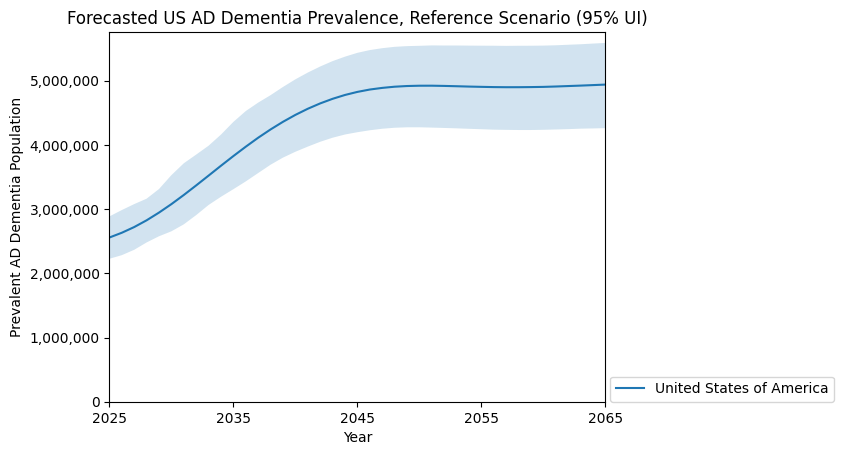

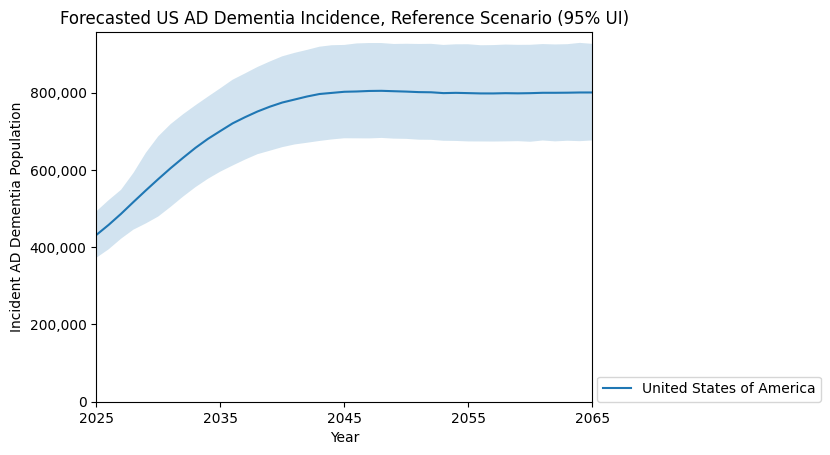

In [14]:
make_forecast_plot(
    filter_results(
        res,
        ["Year"],
        location=["United States of America"],
        stage=["AD Dementia"],
        measure=["Prevalence"],
    ),
    "Forecasted US AD Dementia Prevalence, Reference Scenario (95% UI)",
    "Prevalent AD Dementia Population",
)
make_forecast_plot(
    filter_results(
        res,
        ["Year"],
        location=["United States of America"],
        stage=["AD Dementia"],
        measure=["Incidence"],
    ),
    "Forecasted US AD Dementia Incidence, Reference Scenario (95% UI)",
    "Incident AD Dementia Population",
)

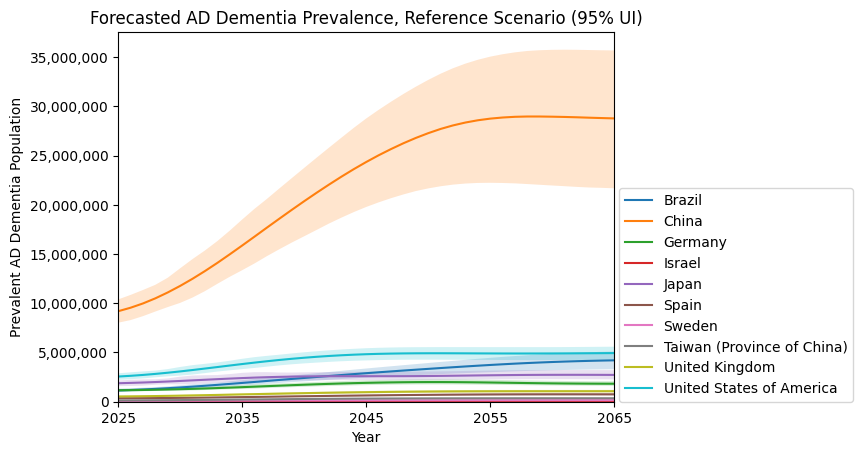

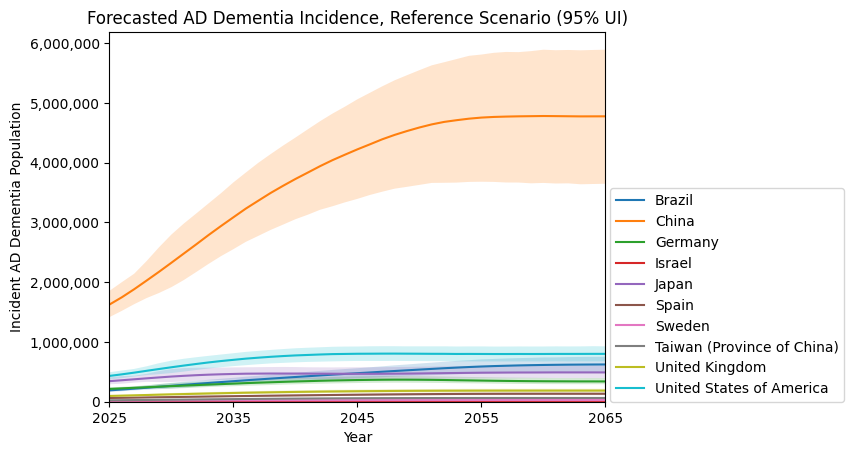

In [15]:
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Location"],
        stage=["AD Dementia"],
        measure=["Prevalence"],
    ),
    "Forecasted AD Dementia Prevalence, Reference Scenario (95% UI)",
    "Prevalent AD Dementia Population",
)
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Location"],
        stage=["AD Dementia"],
        measure=["Incidence"],
    ),
    "Forecasted AD Dementia Incidence, Reference Scenario (95% UI)",
    "Incident AD Dementia Population",
)

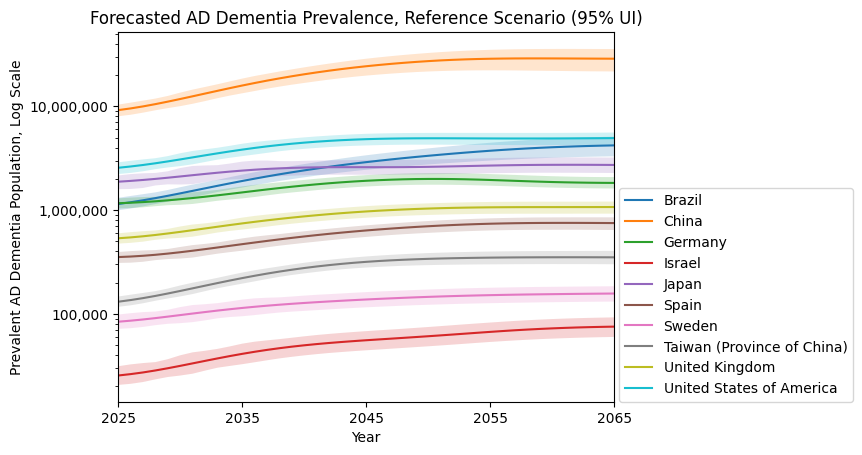

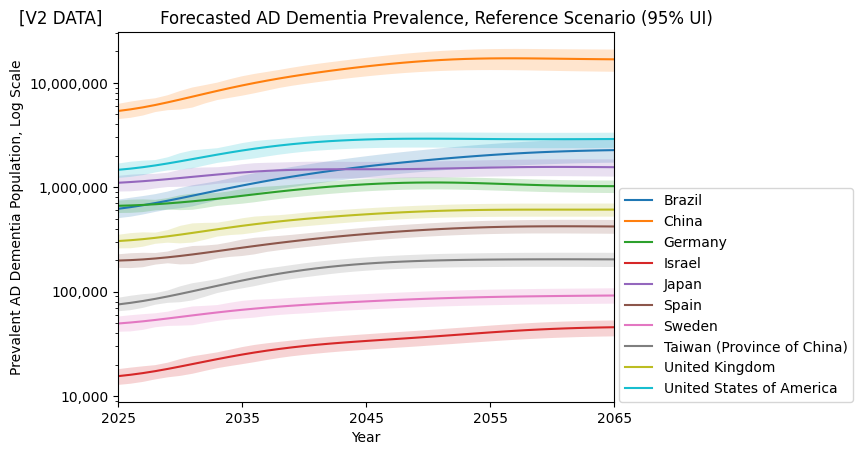

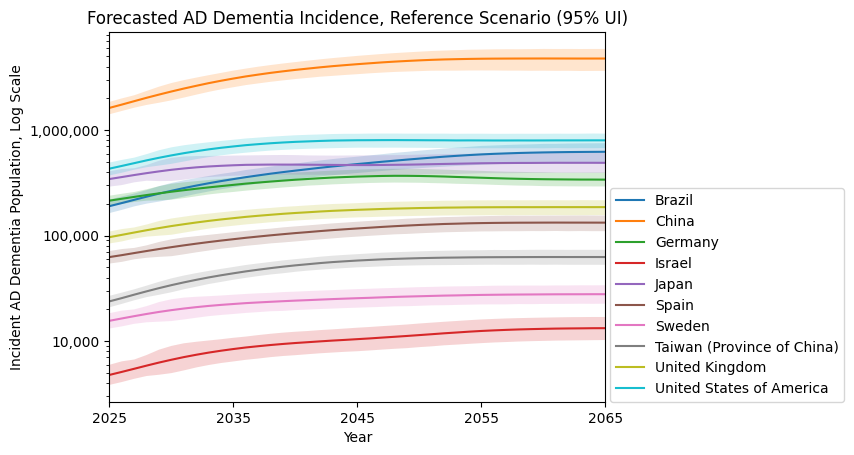

In [16]:
df = filter_results(
    res,
    ["Year", "Location"],
    stage=["AD Dementia"],
    measure=["Prevalence"],
)
make_forecast_plot(
    df,
    "Forecasted AD Dementia Prevalence, Reference Scenario (95% UI)",
    "Prevalent AD Dementia Population, Log Scale",
    scale="log",
)
df_v2 = filter_results(
    v2_res,
    ["Year", "Location"],
    stage=["AD Dementia"],
    measure=["Prevalence"],
)
make_forecast_plot(
    df_v2,
    "[V2 DATA]           Forecasted AD Dementia Prevalence, Reference Scenario (95% UI)",
    "Prevalent AD Dementia Population, Log Scale",
    scale="log",
)
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Location"],
        stage=["AD Dementia"],
        measure=["Incidence"],
    ),
    "Forecasted AD Dementia Incidence, Reference Scenario (95% UI)",
    "Incident AD Dementia Population, Log Scale",
    scale="log",
)

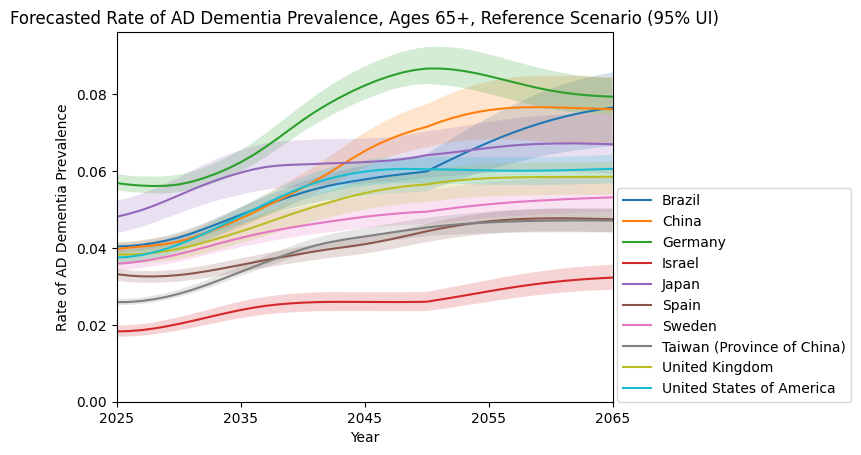

In [17]:
df = filter_results(
    res,
    ["Year", "Location"],
    age=["65_plus"],
    sex=["Both"],
    stage=["AD Dementia"],
    measure=["Prevalence"],
    metric=["Rate"],
)
make_forecast_plot(
    df,
    "Forecasted Rate of AD Dementia Prevalence, Ages 65+, Reference Scenario (95% UI)",
    "Rate of AD Dementia Prevalence",
)

In [18]:
# make_forecast_plot(
#    filter_results(
#        res,
#        ["Year", "Location"],
#        stage=["AD Dementia"],
#        measure=["Prevalence"],
#        metric=["Rate"],
#    ),
#    "Forecasted AD Dementia Prevalence, Reference Scenario (95% UI)",
#    "Rate of AD Dementia Prevalence",
# )
# make_forecast_plot(
#     filter_results(
#         res,
#         ["Year", "Location"],
#         stage=["AD Dementia"],
#         measure=["Incidence"],
#         metric=["Rate"],
#     ),
#     "Forecasted AD Dementia Incidence, Reference Scenario (95% UI)",
#     "Rate of AD Dementia Incidence",
# )

In [19]:
res

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
0,2025,Brazil,65_to_69,Female,Preclinical AD,Reference,Prevalence,Number,187036.882381,162433.461894,...,196009.840992,193474.100426,182652.646418,182955.906262,173085.356946,185232.393837,185910.998505,201850.237628,184571.056742,163842.155638
1,2025,Brazil,65_to_69,Male,Preclinical AD,Reference,Prevalence,Number,72372.922748,52305.030077,...,76462.226069,94882.702103,76860.892904,92282.676043,50414.205521,75152.987224,74821.443380,86088.717948,66905.459162,60027.447762
2,2025,Brazil,65_to_69,Both,Preclinical AD,Reference,Prevalence,Number,259409.805129,222965.015052,...,272472.067061,288356.802529,259513.539322,275238.582305,223499.562468,260385.381061,260732.441885,287938.955576,251476.515903,223869.603400
3,2025,Brazil,65_to_69,Female,Preclinical AD,BBBM Testing Only,Prevalence,Number,187036.882381,162433.461894,...,196009.840992,193474.100426,182652.646418,182955.906262,173085.356946,185232.393837,185910.998505,201850.237628,184571.056742,163842.155638
4,2025,Brazil,65_to_69,Male,Preclinical AD,BBBM Testing Only,Prevalence,Number,72372.922748,52305.030077,...,76462.226069,94882.702103,76860.892904,92282.676043,50414.205521,75152.987224,74821.443380,86088.717948,66905.459162,60027.447762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341995,2100,United States of America,65_plus,Male,AD Dementia,BBBM Testing Only,Averted Deaths Associated with AD,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
341996,2100,United States of America,65_plus,Both,AD Dementia,BBBM Testing Only,Averted Deaths Associated with AD,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
341997,2100,United States of America,65_plus,Female,AD Dementia,BBBM Testing and Treatment,Averted Deaths Associated with AD,Rate,0.000149,0.000110,...,0.000124,0.000166,0.000121,0.000148,0.000142,0.000163,0.000156,0.000154,0.000165,0.000175
341998,2100,United States of America,65_plus,Male,AD Dementia,BBBM Testing and Treatment,Averted Deaths Associated with AD,Rate,0.000094,0.000064,...,0.000082,0.000099,0.000074,0.000081,0.000094,0.000100,0.000104,0.000120,0.000093,0.000104


## Get prevalences of all disease stages in the US in 2025, for technical report

In [20]:
res.query(
    "Location == 'United States of America'"
    " and Age == '65_plus' and Sex == 'Both'"
    " and Year == 2025 and Scenario == 'Reference'"
    " and Measure == 'Prevalence' and Metric == 'Number'"
)

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
1019162,2025,United States of America,65_plus,Both,Preclinical AD,Reference,Prevalence,Number,4.048624e+06,3.653185e+06,...,4.166768e+06,4.376405e+06,4.471585e+06,4.077135e+06,4.022260e+06,4.056966e+06,3.875684e+06,4.192246e+06,4.189900e+06,3.935806e+06
1021442,2025,United States of America,65_plus,Both,MCI due to AD,Reference,Prevalence,Number,1.597484e+06,1.436573e+06,...,1.652713e+06,1.727694e+06,1.757870e+06,1.614328e+06,1.593538e+06,1.609485e+06,1.533582e+06,1.647570e+06,1.637307e+06,1.540766e+06
1023722,2025,United States of America,65_plus,Both,AD Dementia,Reference,Prevalence,Number,2.401377e+06,2.176871e+06,...,2.523357e+06,2.564008e+06,2.626195e+06,2.423331e+06,2.405079e+06,2.432190e+06,2.286106e+06,2.447807e+06,2.428122e+06,2.294959e+06


# AD Dementia prevalence and incidence forecasts

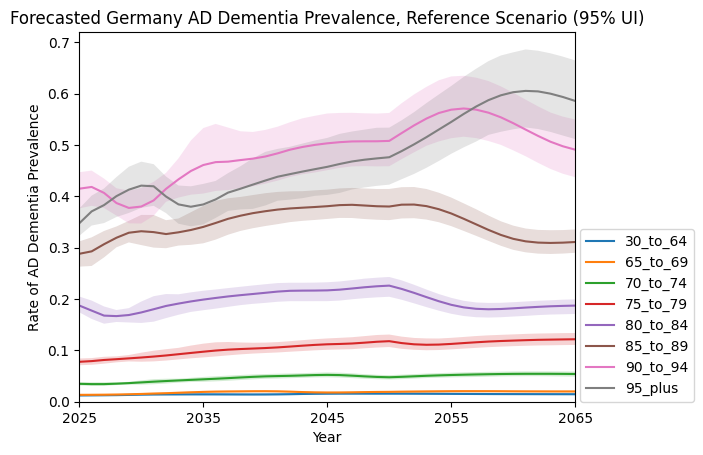

In [21]:
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Age"],
        location=["Germany"],
        stage=["AD Dementia"],
        measure=["Prevalence"],
        metric=["Rate"],
    ),
    "Forecasted Germany AD Dementia Prevalence, Reference Scenario (95% UI)",
    "Rate of AD Dementia Prevalence",
    "Age",
)

## Remake old US Prevalence plot (v3, 12/2025) for comparison with new version (v5, 2/2026)

OLD VERSION! (v3, 12/2025)


(0.0, 1300000.0)

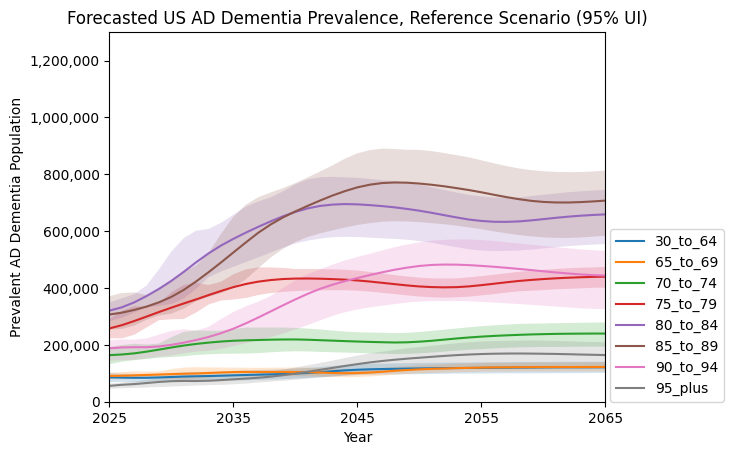

In [22]:
print("OLD VERSION! (v3, 12/2025)")


make_forecast_plot(
    filter_results(
        v3_res,
        ["Year", "Age"],
        location=["United States of America"],
        stage=["AD Dementia"],
        measure=["Prevalence"],
    ),
    "Forecasted US AD Dementia Prevalence, Reference Scenario (95% UI)",
    "Prevalent AD Dementia Population",
    strat_col="Age",
)
# Set y-limit higher to match new data for comparison
plt.ylim(0, 1_300_000)

## Updated AD Dementia prevalence and incidence plots for several countries

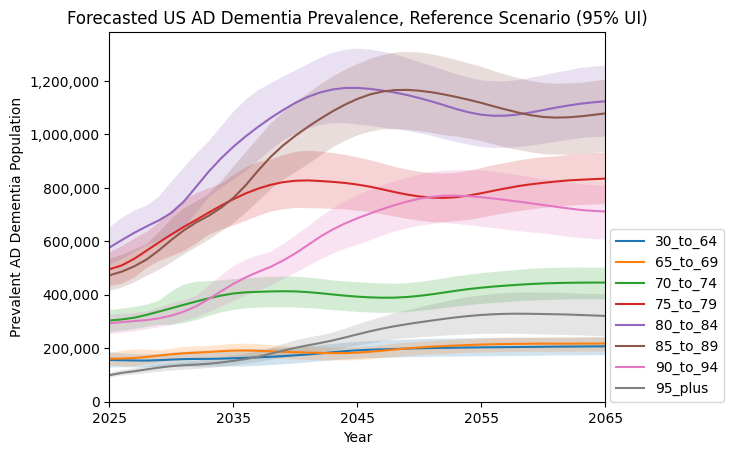

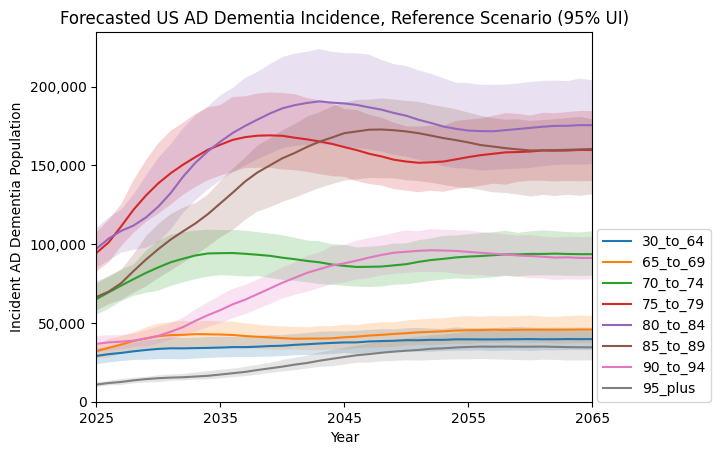

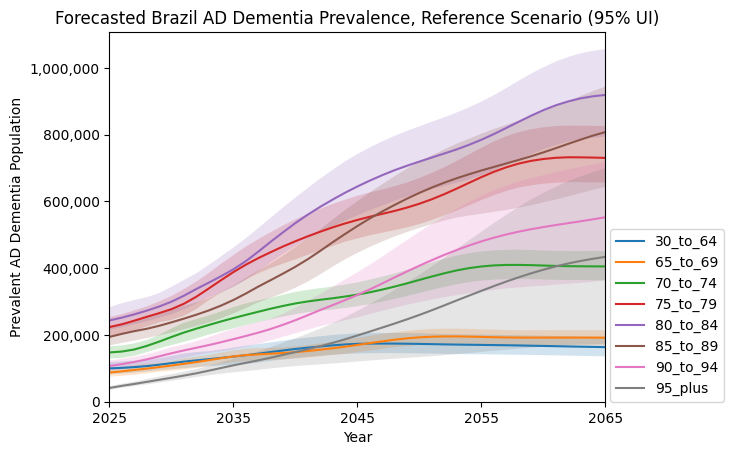

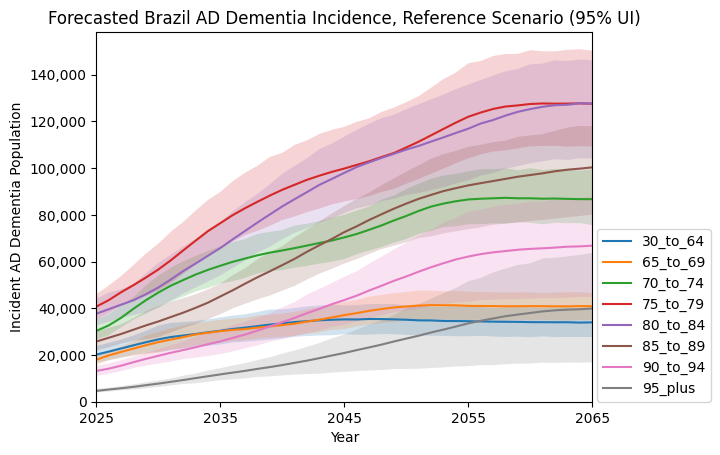

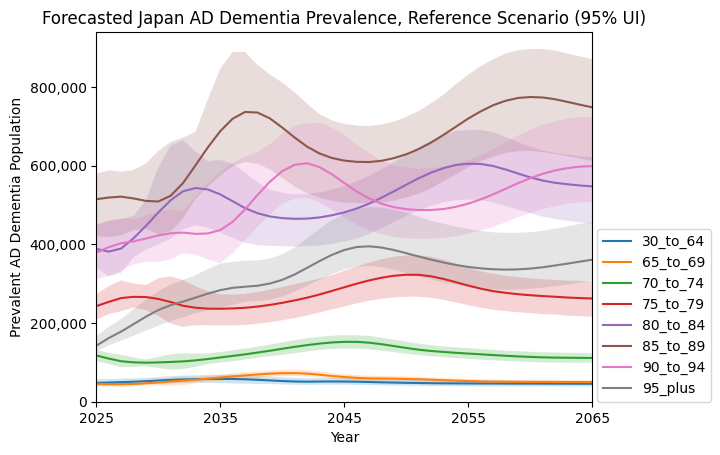

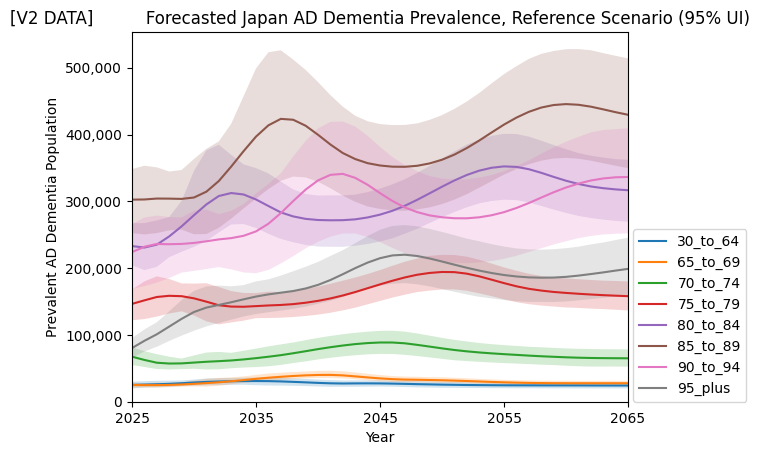

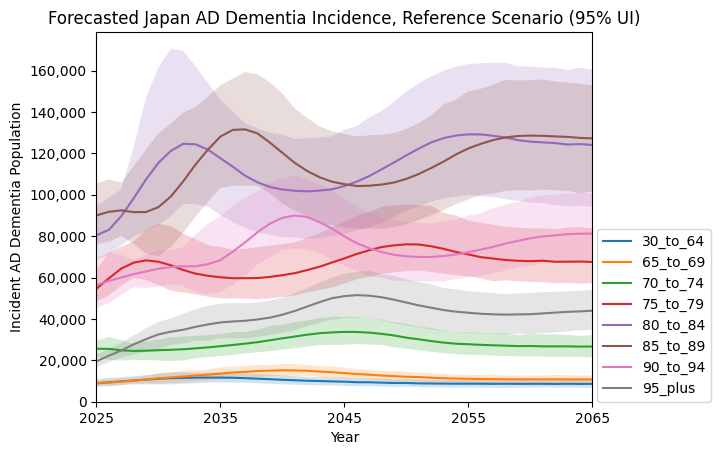

In [23]:
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Age"],
        location=["United States of America"],
        stage=["AD Dementia"],
        measure=["Prevalence"],
    ),
    "Forecasted US AD Dementia Prevalence, Reference Scenario (95% UI)",
    "Prevalent AD Dementia Population",
    strat_col="Age",
)
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Age"],
        location=["United States of America"],
        stage=["AD Dementia"],
        measure=["Incidence"],
    ),
    "Forecasted US AD Dementia Incidence, Reference Scenario (95% UI)",
    "Incident AD Dementia Population",
    strat_col="Age",
)
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Age"],
        location=["Brazil"],
        stage=["AD Dementia"],
        measure=["Prevalence"],
    ),
    "Forecasted Brazil AD Dementia Prevalence, Reference Scenario (95% UI)",
    "Prevalent AD Dementia Population",
    strat_col="Age",
)
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Age"],
        location=["Brazil"],
        stage=["AD Dementia"],
        measure=["Incidence"],
    ),
    "Forecasted Brazil AD Dementia Incidence, Reference Scenario (95% UI)",
    "Incident AD Dementia Population",
    strat_col="Age",
)
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Age"],
        location=["Japan"],
        stage=["AD Dementia"],
        measure=["Prevalence"],
    ),
    "Forecasted Japan AD Dementia Prevalence, Reference Scenario (95% UI)",
    "Prevalent AD Dementia Population",
    strat_col="Age",
)
make_forecast_plot(
    filter_results(
        v2_res,
        ["Year", "Age"],
        location=["Japan"],
        stage=["AD Dementia"],
        measure=["Prevalence"],
    ),
    "[V2 DATA]          Forecasted Japan AD Dementia Prevalence, Reference Scenario (95% UI)",
    "Prevalent AD Dementia Population",
    strat_col="Age",
)
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Age"],
        location=["Japan"],
        stage=["AD Dementia"],
        measure=["Incidence"],
    ),
    "Forecasted Japan AD Dementia Incidence, Reference Scenario (95% UI)",
    "Incident AD Dementia Population",
    strat_col="Age",
)

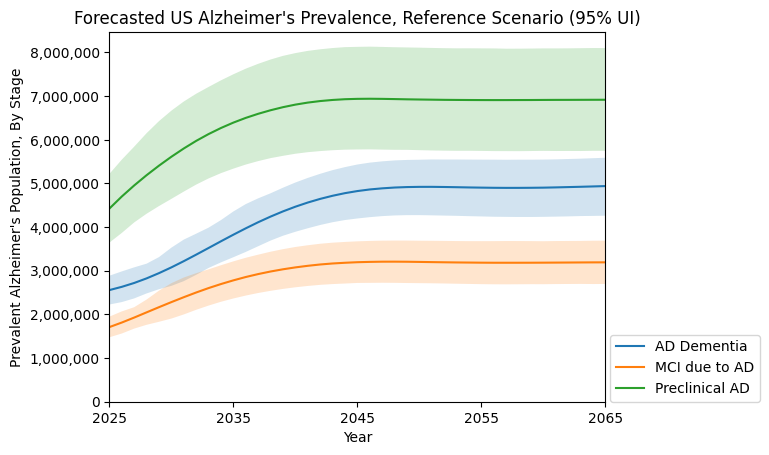

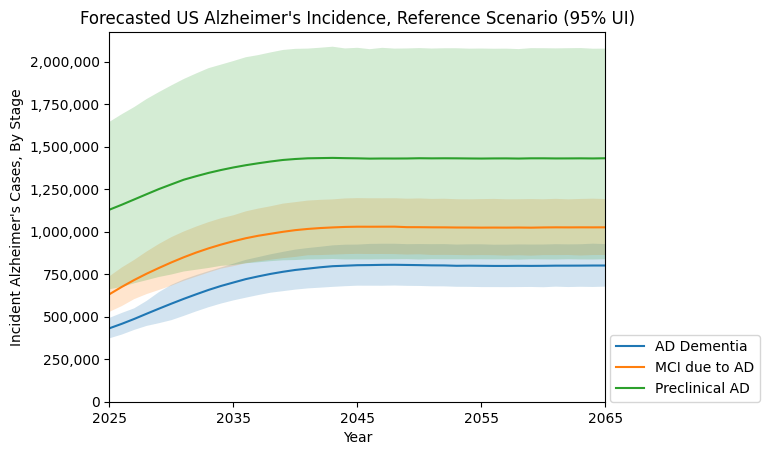

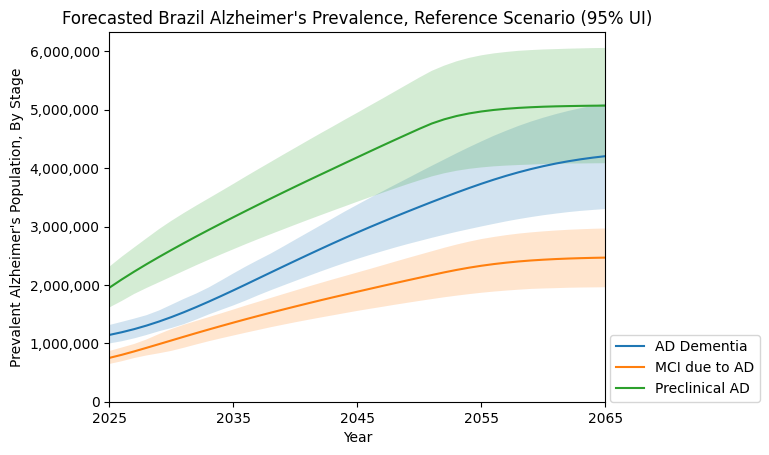

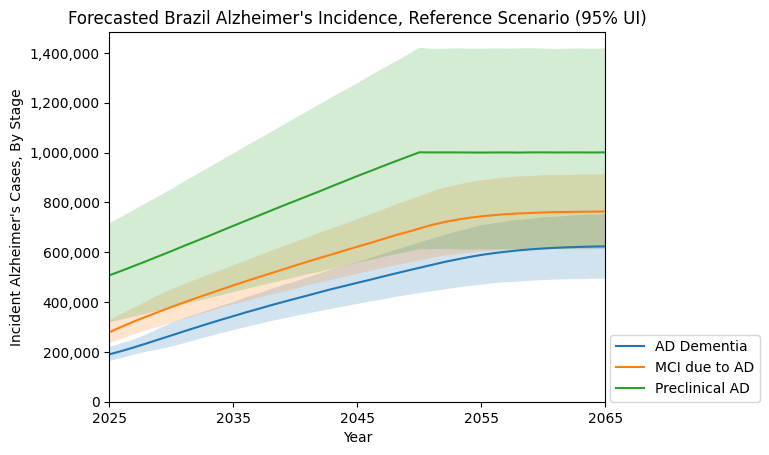

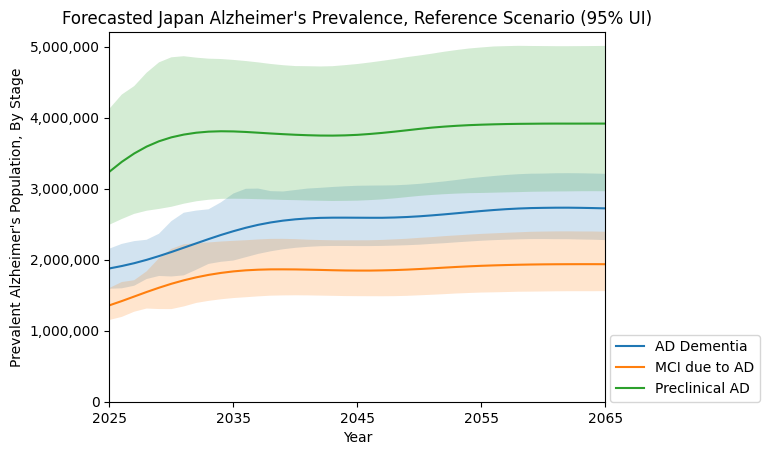

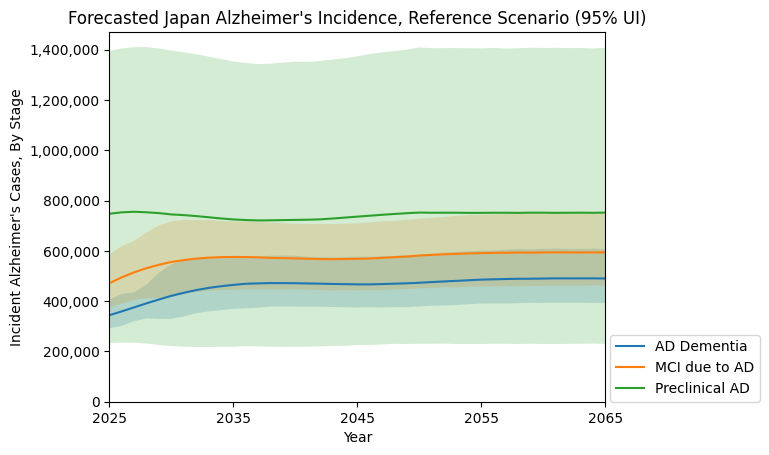

In [24]:
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Disease Stage"],
        location=["United States of America"],
        measure=["Prevalence"],
    ),
    "Forecasted US Alzheimer's Prevalence, Reference Scenario (95% UI)",
    "Prevalent Alzheimer's Population, By Stage",
    strat_col="Disease Stage",
)
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Disease Stage"],
        location=["United States of America"],
        measure=["Incidence"],
    ),
    "Forecasted US Alzheimer's Incidence, Reference Scenario (95% UI)",
    "Incident Alzheimer's Cases, By Stage",
    strat_col="Disease Stage",
)
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Disease Stage"],
        location=["Brazil"],
        measure=["Prevalence"],
    ),
    "Forecasted Brazil Alzheimer's Prevalence, Reference Scenario (95% UI)",
    "Prevalent Alzheimer's Population, By Stage",
    strat_col="Disease Stage",
)
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Disease Stage"],
        location=["Brazil"],
        measure=["Incidence"],
    ),
    "Forecasted Brazil Alzheimer's Incidence, Reference Scenario (95% UI)",
    "Incident Alzheimer's Cases, By Stage",
    strat_col="Disease Stage",
)
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Disease Stage"],
        location=["Japan"],
        measure=["Prevalence"],
    ),
    "Forecasted Japan Alzheimer's Prevalence, Reference Scenario (95% UI)",
    "Prevalent Alzheimer's Population, By Stage",
    strat_col="Disease Stage",
)
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Disease Stage"],
        location=["Japan"],
        measure=["Incidence"],
    ),
    "Forecasted Japan Alzheimer's Incidence, Reference Scenario (95% UI)",
    "Incident Alzheimer's Cases, By Stage",
    strat_col="Disease Stage",
)

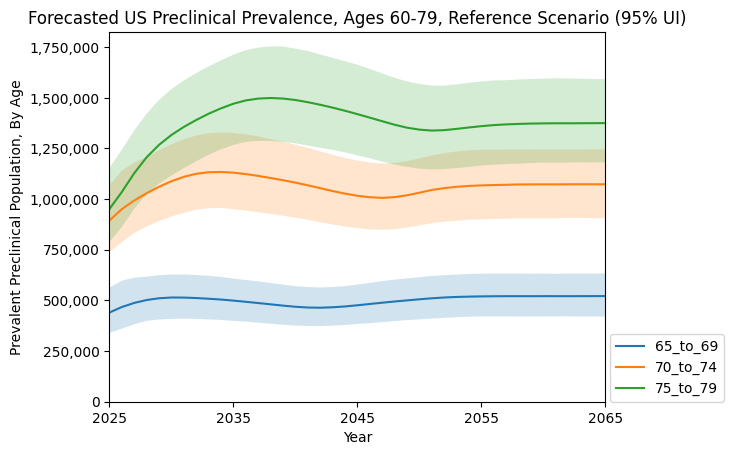

In [25]:
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Age"],
        location=["United States of America"],
        measure=["Prevalence"],
        stage=["Preclinical AD"],
        age=["60_to_64", "65_to_69", "70_to_74", "75_to_79"],
    ),
    "Forecasted US Preclinical Prevalence, Ages 60-79, Reference Scenario (95% UI)",
    "Prevalent Preclinical Population, By Age",
    strat_col="Age",
)

692934.7566819366

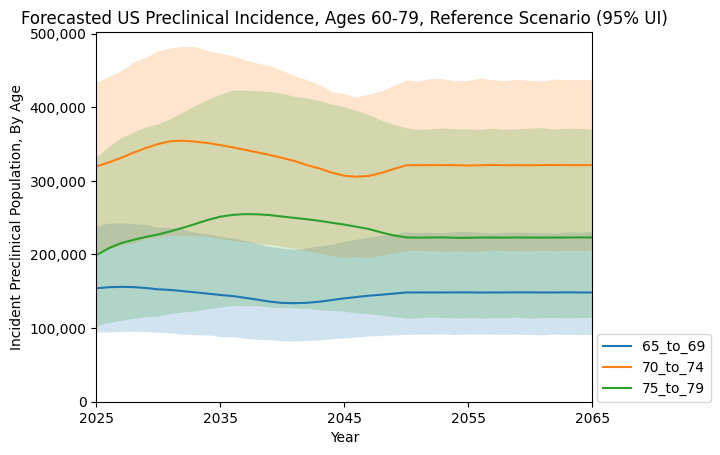

In [26]:
df = filter_results(
    res,
    ["Year"],
    location=["United States of America"],
    measure=["Incidence"],
    stage=["Preclinical AD"],
    age=["60_to_64", "65_to_69", "70_to_74", "75_to_79"],
)

make_forecast_plot(
    df,
    "Forecasted US Preclinical Incidence, Ages 60-79, Reference Scenario (95% UI)",
    "Incident Preclinical Population, By Age",
    strat_col="Age",
)

df[df["Year"] == 2100]["Mean"].sum()

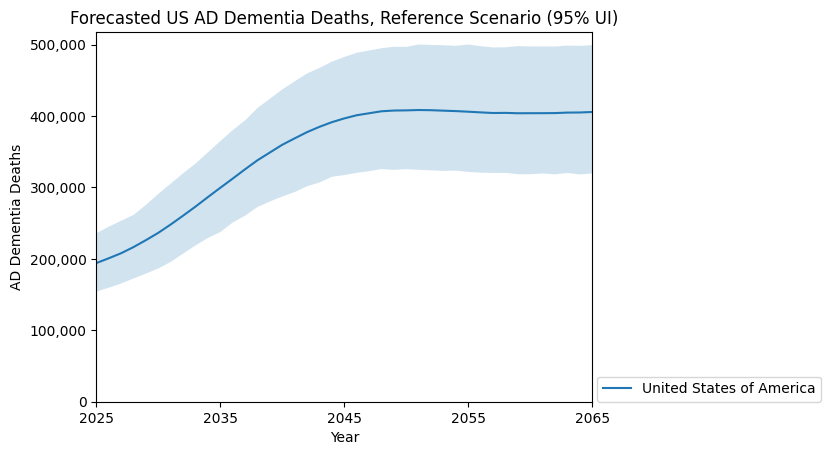

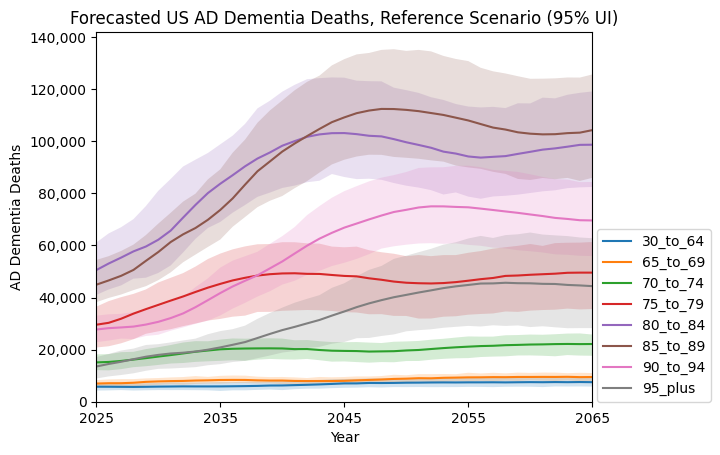

In [27]:
make_forecast_plot(
    filter_results(
        res,
        ["Year"],
        location=["United States of America"],
        measure=["Deaths Associated with AD"],
    ),
    "Forecasted US AD Dementia Deaths, Reference Scenario (95% UI)",
    "AD Dementia Deaths",
)
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Age"],
        location=["United States of America"],
        measure=["Deaths Associated with AD"],
    ),
    "Forecasted US AD Dementia Deaths, Reference Scenario (95% UI)",
    "AD Dementia Deaths",
    "Age",
)

# Testing

In [28]:
csf_pet = pd.read_csv(Path(results_dir_old) / "csf_pet_tests.csv")
bbbm = pd.read_csv(Path(results_dir_old) / "bbbm_tests.csv")
_res2_OLD = pd.concat([csf_pet, bbbm])
_res2_OLD

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,95% UI Upper
0,2025,Brazil,25_to_29,Female,MCI due to AD,Reference,Averted CSF Tests,Number,0.000000,0.000000,0.000000
1,2025,Brazil,25_to_29,Female,MCI due to AD,Reference,Averted PET Tests,Number,0.000000,0.000000,0.000000
2,2025,Brazil,25_to_29,Female,MCI due to AD,Reference,CSF Tests,Number,0.000000,0.000000,0.000000
3,2025,Brazil,25_to_29,Female,MCI due to AD,Reference,PET Tests,Number,0.000000,0.000000,0.000000
4,2025,Brazil,25_to_29,Female,MCI due to AD,BBBM Testing Only,Averted CSF Tests,Number,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
79655,2100,United States of America,75_to_80,Female,Susceptible,BBBM Testing and Treatment,BBBM False Positive Tests,Number,146774.863478,136236.289374,154975.735010
79656,2100,United States of America,60_to_65,Male,Susceptible,BBBM Testing and Treatment,BBBM False Positive Tests,Number,231725.331175,215371.159718,244914.562719
79657,2100,United States of America,65_to_70,Male,Susceptible,BBBM Testing and Treatment,BBBM False Positive Tests,Number,187697.518252,174450.639371,198380.795803
79658,2100,United States of America,70_to_75,Male,Susceptible,BBBM Testing and Treatment,BBBM False Positive Tests,Number,80018.415676,74371.062048,84572.865579


In [29]:
draw_level_results = pd.read_csv(
    "/snfs1/Project/simulation_science/alzheimers/results_11_14_2025_mslt/2025_11_14__14_11_42_outside_sim_results_draw_level.csv"
)
df = draw_level_results.query(
    "Year == 2100 & Location == 'United States of America' & Age == '75_to_79' & Sex == 'Male' & `Disease Stage` == 'Susceptible' & Scenario == 'BBBM Testing Only' & Measure == 'BBBM False Positive Tests'"
).drop(["Unnamed: 0", "Draw"], axis=1)
display(df.columns)
df.groupby(df.columns.drop("Value").tolist()).mean()

Index(['Year', 'Location', 'Age', 'Sex', 'Disease Stage', 'Scenario',
       'Measure', 'Metric', 'Value'],
      dtype='object')

,,,,,,,,Value
Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,
2100,United States of America,75_to_79,Male,Susceptible,BBBM Testing Only,BBBM False Positive Tests,Number,136831.490805


In [30]:
csf_pet = pd.read_csv(Path(results_dir_new) / "csf_pet_tests.csv")
bbbm = pd.read_csv(Path(results_dir_new) / "bbbm_tests.csv")
res2 = pd.concat([csf_pet, bbbm])
display(res2["Measure"].unique())
# display(res2[res2["Measure"] == "Positive BBBM Tests"])
# display(res2[res2["Measure"] == "BBBM Positive Tests"])
v2_res2 = pd.concat(
    [
        pd.read_csv(Path(results_dir_v2) / "csf_pet_tests.csv"),
        pd.read_csv(Path(results_dir_v2) / "bbbm_tests.csv"),
    ]
)
v1_res2 = pd.concat(
    [
        pd.read_csv(Path(results_dir_v1) / "csf_pet_tests.csv"),
        pd.read_csv(Path(results_dir_v1) / "bbbm_tests.csv"),
    ]
)
old_res2 = pd.concat(
    [
        pd.read_csv(Path(results_dir_old) / "csf_pet_tests.csv"),
        pd.read_csv(Path(results_dir_old) / "bbbm_tests.csv"),
    ]
)
res2[res2["Metric"] == "Number"]

array(['CSF Tests', 'PET Tests', 'Averted CSF Tests', 'Averted PET Tests',
       'BBBM Tests', 'Positive BBBM Tests'], dtype=object)

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
0,2025,Brazil,65_to_69,Female,MCI due to AD,Reference,CSF Tests,Number,3365.354044,1850.986316,...,5282.912217,1844.624657,2979.979069,2890.259512,2824.707602,3740.051078,1855.227421,4462.396099,2714.170045,3517.471481
1,2025,Brazil,65_to_69,Male,MCI due to AD,Reference,CSF Tests,Number,1320.010850,814.662530,...,1982.309716,924.667169,1269.471083,1436.344773,908.048937,1570.477324,723.874265,1800.744785,1048.693791,1350.732489
2,2025,Brazil,65_to_69,Both,MCI due to AD,Reference,CSF Tests,Number,4685.364895,2693.215770,...,7265.221933,2769.291826,4249.450152,4326.604285,3732.756539,5310.528403,2579.101686,6263.140884,3762.863835,4868.203969
3,2025,Brazil,65_to_69,Female,MCI due to AD,BBBM Testing Only,CSF Tests,Number,3365.354044,1850.986316,...,5282.912217,1844.624657,2979.979069,2890.259512,2824.707602,3740.051078,1855.227421,4462.396099,2714.170045,3517.471481
4,2025,Brazil,65_to_69,Male,MCI due to AD,BBBM Testing Only,CSF Tests,Number,1320.010850,814.662530,...,1982.309716,924.667169,1269.471083,1436.344773,908.048937,1570.477324,723.874265,1800.744785,1048.693791,1350.732489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145909,2100,United States of America,65_plus,Male,Susceptible,BBBM Testing Only,Positive BBBM Tests,Number,8840.639115,8030.646466,...,9031.773616,9159.463850,9651.018784,8703.739103,8432.131104,8836.128134,8211.832306,8824.510903,9020.080359,8557.788499
145910,2100,United States of America,65_plus,Both,Susceptible,BBBM Testing Only,Positive BBBM Tests,Number,18525.172079,16851.942175,...,18749.167628,19072.233981,20161.430417,18186.281425,17667.154097,18543.581744,17218.882179,18483.824651,18899.805614,17928.492938
145911,2100,United States of America,65_plus,Female,Susceptible,BBBM Testing and Treatment,Positive BBBM Tests,Number,9684.532964,8821.295710,...,9717.394013,9912.770131,10510.411632,9482.542322,9235.022993,9707.453610,9007.049873,9659.313748,9879.725255,9370.704439
145912,2100,United States of America,65_plus,Male,Susceptible,BBBM Testing and Treatment,Positive BBBM Tests,Number,8840.639115,8030.646466,...,9031.773616,9159.463850,9651.018784,8703.739103,8432.131104,8836.128134,8211.832306,8824.510903,9020.080359,8557.788499


In [31]:
# Check 2099 vs 2100 data
display(
    res2[
        (res2["Year"] == 2099)
        & (
            (res2["Age"] == "70_to_74") | (res2["Age"] == "70_to_75")
        )  # note my MSLT age group labels are off - I've fixed this for the plots in this nb and will fix it in the results as well when I rerun for pop
        & (res2["Location"] == "United States of America")
        & (res2["Sex"] == "Female")
    ]
)
display(
    res2[
        (res2["Year"] == 2100)
        & ((res2["Age"] == "70_to_74") | (res2["Age"] == "70_to_75"))
        & (res2["Location"] == "United States of America")
        & (res2["Sex"] == "Female")
    ]
)

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
91080,2099,United States of America,70_to_74,Female,MCI due to AD,Reference,CSF Tests,Number,1.190824e+04,6.575364e+03,...,1.844491e+04,6.743875e+03,1.242554e+04,1.105308e+04,1.126339e+04,1.407255e+04,6.322599e+03,1.451151e+04,1.004743e+04,1.401977e+04
91083,2099,United States of America,70_to_74,Female,MCI due to AD,BBBM Testing Only,CSF Tests,Number,7.377123e+03,4.050654e+03,...,1.139345e+04,4.148281e+03,7.717334e+03,6.682241e+03,7.194552e+03,8.631699e+03,3.904213e+03,9.190994e+03,6.183885e+03,8.766264e+03
91086,2099,United States of America,70_to_74,Female,MCI due to AD,BBBM Testing and Treatment,CSF Tests,Number,7.377123e+03,4.050654e+03,...,1.139345e+04,4.148281e+03,7.717334e+03,6.682241e+03,7.194552e+03,8.631699e+03,3.904213e+03,9.190994e+03,6.183885e+03,8.766264e+03
91089,2099,United States of America,70_to_74,Female,MCI due to AD,Reference,CSF Tests,Rate,1.320585e-03,7.426621e-04,...,2.020652e-03,7.285567e-04,1.269209e-03,1.244636e-03,1.307351e-03,1.556109e-03,7.520656e-04,1.609997e-03,1.095106e-03,1.601951e-03
91092,2099,United States of America,70_to_74,Female,MCI due to AD,BBBM Testing Only,CSF Tests,Rate,8.182968e-04,4.579004e-04,...,1.248159e-03,4.481485e-04,7.882882e-04,7.524559e-04,8.350770e-04,9.544725e-04,4.644016e-04,1.019706e-03,6.740044e-04,1.001666e-03
91095,2099,United States of America,70_to_74,Female,MCI due to AD,BBBM Testing and Treatment,CSF Tests,Rate,8.182100e-04,4.578445e-04,...,1.248048e-03,4.481016e-04,7.882133e-04,7.523690e-04,8.349798e-04,9.543421e-04,4.643398e-04,1.019578e-03,6.739099e-04,1.001530e-03
91098,2099,United States of America,70_to_74,Female,MCI due to AD,Reference,PET Tests,Number,1.780621e+04,8.803438e+03,...,1.705049e+04,1.969071e+04,1.583165e+04,2.110931e+04,1.525274e+04,1.352919e+04,1.377610e+04,2.316711e+04,1.798545e+04,1.169530e+04
91101,2099,United States of America,70_to_74,Female,MCI due to AD,BBBM Testing Only,PET Tests,Number,1.103282e+04,5.536560e+03,...,1.058476e+04,1.210239e+04,9.825310e+03,1.273277e+04,9.539737e+03,8.401958e+03,8.918448e+03,1.457472e+04,1.147220e+04,7.372974e+03
91104,2099,United States of America,70_to_74,Female,MCI due to AD,BBBM Testing and Treatment,PET Tests,Number,1.103282e+04,5.536560e+03,...,1.058476e+04,1.210239e+04,9.825310e+03,1.273277e+04,9.539737e+03,8.401958e+03,8.918448e+03,1.457472e+04,1.147220e+04,7.372974e+03
91107,2099,United States of America,70_to_74,Female,MCI due to AD,Reference,PET Tests,Rate,1.981574e-03,9.907550e-04,...,1.867892e-03,2.127234e-03,1.617126e-03,2.377021e-03,1.770397e-03,1.496026e-03,1.638650e-03,2.570302e-03,1.960300e-03,1.336348e-03


,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
91140,2100,United States of America,70_to_74,Female,MCI due to AD,Reference,CSF Tests,Number,1.189516e+04,6.568628e+03,...,1.903442e+04,6.681611e+03,1.220323e+04,1.116628e+04,1.096708e+04,1.367506e+04,6.399152e+03,1.446689e+04,1.036199e+04,1.482934e+04
91143,2100,United States of America,70_to_74,Female,MCI due to AD,BBBM Testing Only,CSF Tests,Number,7.343082e+03,4.059767e+03,...,1.164285e+04,4.105475e+03,7.761002e+03,6.422985e+03,6.804290e+03,8.186803e+03,3.991206e+03,9.179840e+03,6.616868e+03,9.308292e+03
91146,2100,United States of America,70_to_74,Female,MCI due to AD,BBBM Testing and Treatment,CSF Tests,Number,7.343082e+03,4.059767e+03,...,1.164285e+04,4.105475e+03,7.761002e+03,6.422985e+03,6.804290e+03,8.186803e+03,3.991206e+03,9.179840e+03,6.616868e+03,9.308292e+03
91149,2100,United States of America,70_to_74,Female,MCI due to AD,Reference,CSF Tests,Rate,1.318914e-03,7.454350e-04,...,2.085233e-03,7.218302e-04,1.246501e-03,1.257383e-03,1.272958e-03,1.512155e-03,7.611715e-04,1.605047e-03,1.129391e-03,1.694455e-03
91152,2100,United States of America,70_to_74,Female,MCI due to AD,BBBM Testing Only,CSF Tests,Rate,8.145184e-04,4.622592e-04,...,1.275482e-03,4.435241e-04,7.927487e-04,7.232623e-04,7.897790e-04,9.052771e-04,4.747492e-04,1.018468e-03,7.211968e-04,1.063600e-03
91155,2100,United States of America,70_to_74,Female,MCI due to AD,BBBM Testing and Treatment,CSF Tests,Rate,8.144311e-04,4.622011e-04,...,1.275360e-03,4.434753e-04,7.926760e-04,7.231790e-04,7.896875e-04,9.051523e-04,4.746850e-04,1.018345e-03,7.211029e-04,1.063450e-03
91158,2100,United States of America,70_to_74,Female,MCI due to AD,Reference,PET Tests,Number,1.777623e+04,8.508273e+03,...,1.686532e+04,2.034837e+04,1.591502e+04,2.091578e+04,1.503231e+04,1.383187e+04,1.380393e+04,2.347198e+04,1.764498e+04,1.135132e+04
91161,2100,United States of America,70_to_74,Female,MCI due to AD,BBBM Testing Only,PET Tests,Number,1.096240e+04,5.258495e+03,...,1.016908e+04,1.240593e+04,9.646668e+03,1.248082e+04,9.434945e+03,8.668166e+03,8.740984e+03,1.465651e+04,1.110583e+04,7.049841e+03
91164,2100,United States of America,70_to_74,Female,MCI due to AD,BBBM Testing and Treatment,PET Tests,Number,1.096240e+04,5.258495e+03,...,1.016908e+04,1.240593e+04,9.646668e+03,1.248082e+04,9.434945e+03,8.668166e+03,8.740984e+03,1.465651e+04,1.110583e+04,7.049841e+03
91167,2100,United States of America,70_to_74,Female,MCI due to AD,Reference,PET Tests,Rate,1.978346e-03,9.577817e-04,...,1.847607e-03,2.198282e-03,1.625642e-03,2.355228e-03,1.744812e-03,1.529495e-03,1.641962e-03,2.604128e-03,1.923192e-03,1.297044e-03


In [32]:
display(
    res2[
        (res2["Year"] == 2100)
        # Should give an empty dataframe because this isn't a valid age group
        & (res2["Age"] == "60_to_65")
        & (res2["Location"] == "United States of America")
    ]
)

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249


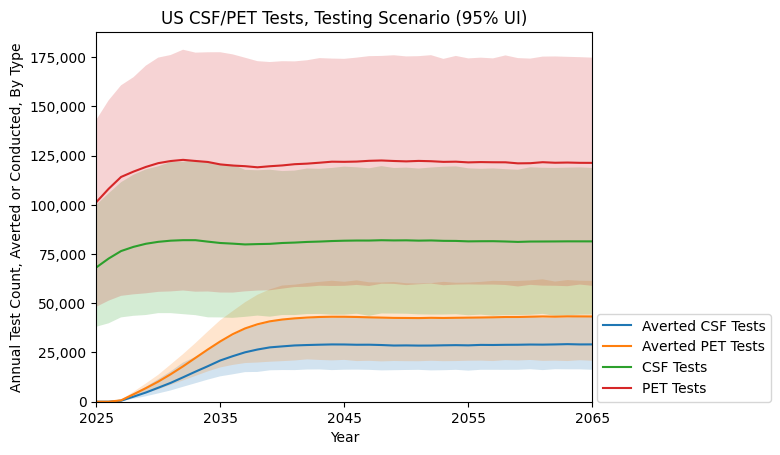

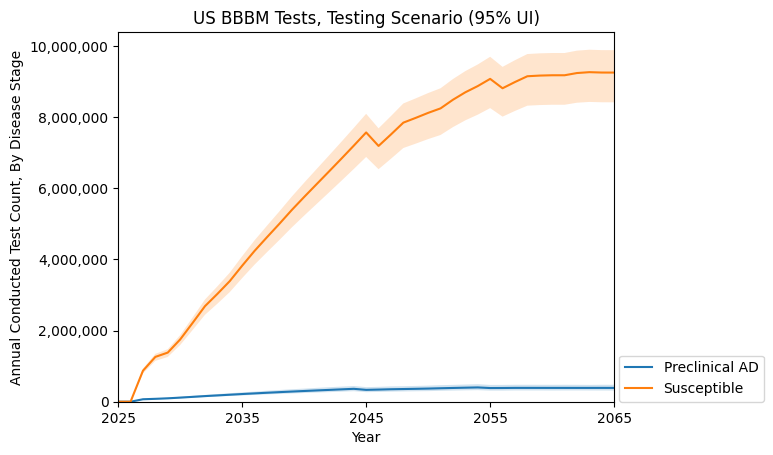

In [33]:
make_forecast_plot(
    filter_results(
        res2,
        ["Year"],
        location=["United States of America"],
        measure=[
            "Averted CSF Tests",
            "Averted PET Tests",
            "CSF Tests",
            "PET Tests",
        ],  # BBBM Tests results in this scenario dont yet include MSLT
        scenario=["BBBM Testing Only"],
    ),
    "US CSF/PET Tests, Testing Scenario (95% UI)",
    "Annual Test Count, Averted or Conducted, By Type",
    "Measure",
)

make_forecast_plot(
    filter_results(
        res2,
        ["Year", "Disease Stage"],
        location=["United States of America"],
        measure=["BBBM Tests"],
        scenario=["BBBM Testing and Treatment"],
    ),
    "US BBBM Tests, Testing Scenario (95% UI)",
    "Annual Conducted Test Count, By Disease Stage",
    "Disease Stage",
)

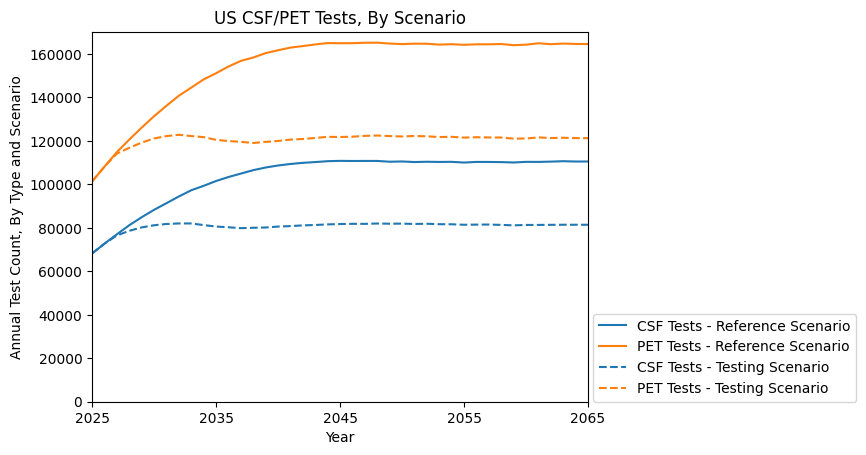

In [34]:
base = filter_results(
    # v1_res2,
    res2,
    ["Year"],
    location=["United States of America"],
    measure=[
        "CSF Tests",
        "PET Tests",
    ],
    scenario=["Reference"],
)
# make_forecast_plot(
#    base,
#    "US CSF/PET Tests, Reference Scenario (95% UI)",
#    "Annual Test Count, By Type",
#    "Measure",
# )
test = filter_results(
    # v1_res2,
    res2,
    ["Year"],
    location=["United States of America"],
    measure=[
        "CSF Tests",
        "PET Tests",
    ],
    scenario=["BBBM Testing Only"],
)
# make_forecast_plot(
#    test,
#    "US CSF/PET Tests, Testing Scenario (95% UI)",
#    "Annual Test Count, By Type",
#    "Measure",
# )

base["Measure"] = base["Measure"].replace(
    {
        "CSF Tests": "CSF Tests - Reference Scenario",
        "PET Tests": "PET Tests - Reference Scenario",
    }
)
test["Measure"] = test["Measure"].replace(
    {
        "CSF Tests": "CSF Tests - Testing Scenario",
        "PET Tests": "PET Tests - Testing Scenario",
    }
)
mixed = pd.concat([base, test])
# TODO solid for reference, dotted for testing, same color
# thinner solid line in same color and style for uncertainty intervals, make main line thicker?
# try grid?
make_forecast_plot(
    # mixed,
    mixed.drop(["95% UI Lower", "95% UI Upper"], axis=1),
    "US CSF/PET Tests, By Scenario",
    "Annual Test Count, By Type and Scenario",
    "Measure",
    set_formatters_and_legend=False,
)
ax = plt.gca()
colors = ["tab:blue", "tab:orange", "tab:blue", "tab:orange"]
styles = ["-", "-", "--", "--"]
measures = [
    "CSF Tests - Reference Scenario",
    "PET Tests - Reference Scenario",
    "CSF Tests - Testing Scenario",
    "PET Tests - Testing Scenario",
]
for idx, c in enumerate(colors):
    line = ax.lines[idx]
    line.set_color(c)
    line.set_linestyle(styles[idx])
    # line.set_linewidth(3)
    # df = mixed[mixed["Measure"] == measures[idx]]
    # ax.plot(df["Year"], df["95% UI Lower"], color=c, linestyle=styles[idx], linewidth=1)
    # ax.plot(df["Year"], df["95% UI Upper"], color=c, linestyle=styles[idx], linewidth=1)

plt.legend(loc=(1.01, 0))
# plt.ylim(top=650000)
plt.show()

,Year,Location,Age,Sex,Scenario,Metric,draw_1,draw_6,draw_7,draw_24,...,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249,Mean,Plot
0,2025,China,65_plus,Both,Reference,Rate,0.000557,0.000494,0.000360,0.000582,...,0.000423,0.000413,0.000458,0.000513,0.000264,0.000567,0.000372,0.000533,0.000453,China - Reference
1,2025,Spain,65_plus,Both,Reference,Rate,0.002456,0.002242,0.001575,0.002599,...,0.001847,0.001783,0.001989,0.002273,0.001145,0.002476,0.001640,0.002319,0.002002,Spain - Reference
2,2025,Sweden,65_plus,Both,Reference,Rate,0.004888,0.004627,0.003275,0.005135,...,0.003389,0.003291,0.003754,0.004121,0.002097,0.004550,0.002977,0.004303,0.003796,Sweden - Reference
3,2025,United States of America,65_plus,Both,Reference,Rate,0.001229,0.001069,0.000781,0.001211,...,0.000918,0.000878,0.000973,0.001117,0.000580,0.001231,0.000820,0.001171,0.000974,United States of America - Reference
4,2026,China,65_plus,Both,Reference,Rate,0.000581,0.000521,0.000377,0.000613,...,0.000444,0.000422,0.000477,0.000529,0.000273,0.000591,0.000383,0.000560,0.000473,China - Reference
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,2099,United States of America,65_plus,Both,BBBM Testing Only,Rate,0.001178,0.001073,0.000778,0.001181,...,0.000867,0.000882,0.000948,0.001101,0.000543,0.001176,0.000790,0.001194,0.000951,United States of America - BBBM Testing Only
300,2100,China,65_plus,Both,BBBM Testing Only,Rate,0.000589,0.000530,0.000399,0.000574,...,0.000465,0.000444,0.000510,0.000546,0.000270,0.000566,0.000371,0.000627,0.000496,China - BBBM Testing Only
301,2100,Spain,65_plus,Both,BBBM Testing Only,Rate,0.002354,0.002066,0.001460,0.002342,...,0.001696,0.001681,0.001894,0.002141,0.001058,0.002362,0.001526,0.002286,0.001885,Spain - BBBM Testing Only
302,2100,Sweden,65_plus,Both,BBBM Testing Only,Rate,0.004352,0.004067,0.002875,0.004525,...,0.002960,0.002935,0.003352,0.003730,0.001876,0.003905,0.002611,0.003860,0.003371,Sweden - BBBM Testing Only


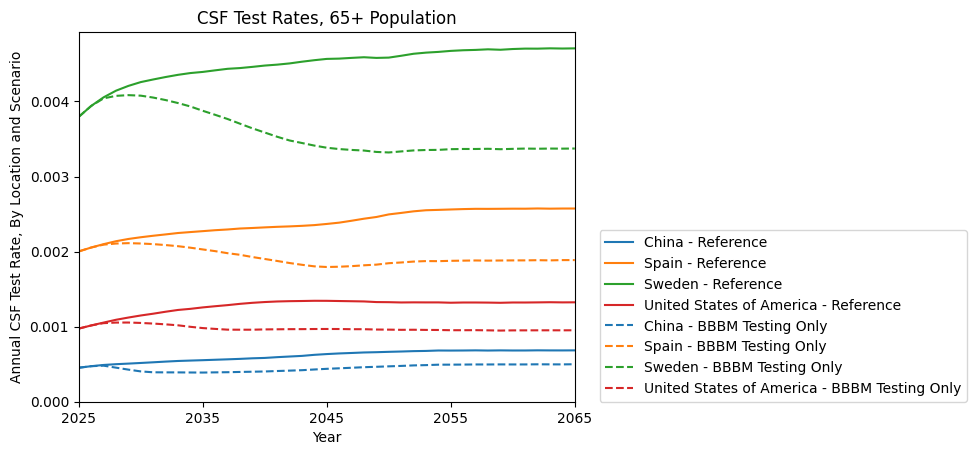

In [35]:
base_csf = filter_results(
    res2,
    ["Year"],
    location=["United States of America", "Spain", "Sweden", "China"],
    sex=["Both"],
    age=["65_plus"],
    measure=[
        "CSF Tests",
    ],
    metric=["Rate"],
    scenario=["Reference"],
).drop(["Measure"] + UI_COLS, axis=1)
base_csf = base_csf.groupby(base_csf.columns.drop("Mean").tolist()).sum().reset_index()
test_csf = filter_results(
    res2,
    ["Year"],
    location=["United States of America", "Spain", "Sweden", "China"],
    sex=["Both"],
    age=["65_plus"],
    measure=[
        "CSF Tests",
    ],
    metric=["Rate"],
    scenario=["BBBM Testing Only"],
).drop(["Measure"] + UI_COLS, axis=1)
test_csf = test_csf.groupby(test_csf.columns.drop("Mean").tolist()).sum().reset_index()
base_csf["Plot"] = (
    base_csf["Location"].astype(str) + " - " + base_csf["Scenario"].astype(str)
)
test_csf["Plot"] = (
    test_csf["Location"].astype(str) + " - " + test_csf["Scenario"].astype(str)
)
display(pd.concat([base_csf, test_csf]))
make_forecast_plot(
    pd.concat([base_csf, test_csf]),
    "CSF Test Rates, 65+ Population",
    "Annual CSF Test Rate, By Location and Scenario",
    "Plot",
    set_formatters_and_legend=False,
)

ax = plt.gca()

# assumes reference and testing lines are plotted in same location order (ref first)
for idx, line in enumerate(ax.lines[len(ax.lines) // 2 :]):
    ref_line = ax.lines[idx]  # idx starts from 0
    line.set_color(ref_line.get_color())
    line.set_linestyle("--")

plt.legend(loc=(1.05, 0))
plt.show()

,Year,Location,Age,Sex,Scenario,Metric,draw_1,draw_6,draw_7,draw_24,...,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249,Mean,Plot
0,2025,China,65_plus,Both,Reference,Rate,0.000771,0.000752,0.000933,0.000590,...,0.000530,0.000789,0.000637,0.000492,0.000552,0.000888,0.000624,0.000432,0.000675,China - Reference
1,2025,Spain,65_plus,Both,Reference,Rate,0.002609,0.002552,0.003082,0.001976,...,0.001772,0.002649,0.002075,0.001664,0.001863,0.002945,0.002105,0.001429,0.002264,Spain - Reference
2,2025,Sweden,65_plus,Both,Reference,Rate,0.000542,0.000557,0.000678,0.000408,...,0.000347,0.000505,0.000412,0.000315,0.000364,0.000591,0.000412,0.000276,0.000455,Sweden - Reference
3,2025,United States of America,65_plus,Both,Reference,Rate,0.001722,0.001622,0.001976,0.001224,...,0.001147,0.001719,0.001331,0.001074,0.001230,0.001955,0.001381,0.000946,0.001454,United States of America - Reference
4,2026,China,65_plus,Both,Reference,Rate,0.000801,0.000786,0.000988,0.000608,...,0.000560,0.000820,0.000645,0.000507,0.000598,0.000935,0.000654,0.000447,0.000707,China - Reference
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,2099,United States of America,65_plus,Both,BBBM Testing Only,Rate,0.001641,0.001605,0.001991,0.001179,...,0.001091,0.001713,0.001297,0.001075,0.001193,0.001869,0.001361,0.000963,0.001423,United States of America - BBBM Testing Only
300,2100,China,65_plus,Both,BBBM Testing Only,Rate,0.000819,0.000787,0.001029,0.000585,...,0.000590,0.000873,0.000691,0.000538,0.000579,0.000908,0.000630,0.000509,0.000743,China - BBBM Testing Only
301,2100,Spain,65_plus,Both,BBBM Testing Only,Rate,0.002487,0.002358,0.002861,0.001788,...,0.001618,0.002481,0.001962,0.001579,0.001748,0.002866,0.001996,0.001389,0.002137,Spain - BBBM Testing Only
302,2100,Sweden,65_plus,Both,BBBM Testing Only,Rate,0.000487,0.000487,0.000583,0.000366,...,0.000307,0.000450,0.000364,0.000286,0.000323,0.000500,0.000362,0.000244,0.000405,Sweden - BBBM Testing Only


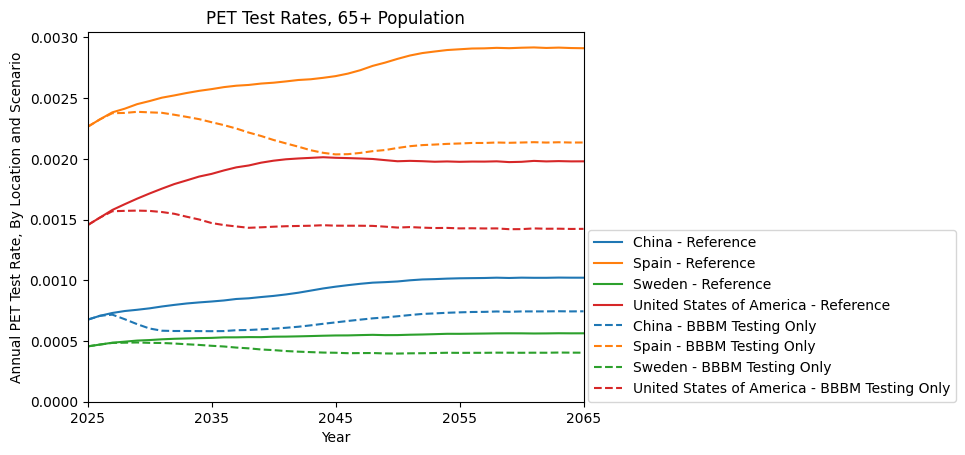

In [36]:
base_pet = filter_results(
    res2,
    ["Year"],
    location=["United States of America", "Spain", "Sweden", "China"],
    sex=["Both"],
    age=["65_plus"],
    measure=[
        "PET Tests",
    ],
    metric=["Rate"],
    scenario=["Reference"],
).drop(["Measure"] + UI_COLS, axis=1)
base_pet = base_pet.groupby(base_pet.columns.drop("Mean").tolist()).sum().reset_index()
test_pet = filter_results(
    res2,
    ["Year"],
    location=["United States of America", "Spain", "Sweden", "China"],
    sex=["Both"],
    age=["65_plus"],
    measure=[
        "PET Tests",
    ],
    metric=["Rate"],
    scenario=["BBBM Testing Only"],
).drop(["Measure"] + UI_COLS, axis=1)
test_pet = test_pet.groupby(test_pet.columns.drop("Mean").tolist()).sum().reset_index()
base_pet["Plot"] = (
    base_pet["Location"].astype(str) + " - " + base_pet["Scenario"].astype(str)
)
test_pet["Plot"] = (
    test_pet["Location"].astype(str) + " - " + test_pet["Scenario"].astype(str)
)
display(pd.concat([base_pet, test_pet]))
make_forecast_plot(
    pd.concat([base_pet, test_pet]),
    "PET Test Rates, 65+ Population",
    "Annual PET Test Rate, By Location and Scenario",
    "Plot",
    set_formatters_and_legend=False,
)

ax = plt.gca()

# assumes reference and testing lines are plotted in same location order (ref first)
for idx, line in enumerate(ax.lines[len(ax.lines) // 2 :]):
    ref_line = ax.lines[idx]  # idx starts from 0
    line.set_color(ref_line.get_color())
    line.set_linestyle("--")

plt.legend(loc=(1.01, 0))
plt.show()

In [37]:
# COMBINING REQUIRES ADDITIONAL CALCULATIONS FOR UNCERTAINTY

# mixed_combined = mixed
# mixed_combined["Measure"] = mixed_combined["Measure"].replace(
#    {
#        "CSF Tests - Testing Scenario": "CSF/PET Tests - Testing Scenario",
#        "PET Tests - Testing Scenario": "CSF/PET Tests - Testing Scenario",
#        "CSF Tests - Reference Scenario": "CSF/PET Tests - Reference Scenario",
#        "PET Tests - Reference Scenario": "CSF/PET Tests - Reference Scenario",
#    }
# )
# make_forecast_plot(
#    mixed_combined.groupby(mixed_combined.columns.drop(["Mean", "95% UI Lower", "95% UI Upper"]).tolist()).sum()),
#    "US CSF/PET Tests, By Scenario (95% UI)",
#    "Annual Test Count",
#    "Measure",
# )

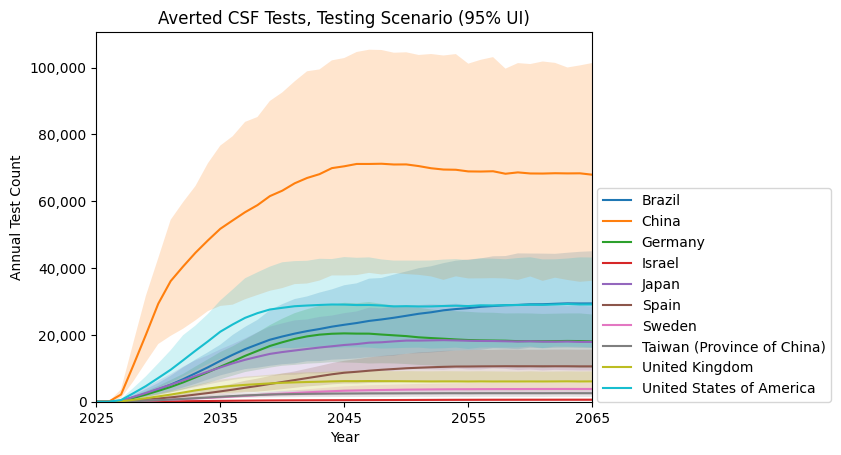

In [38]:
make_forecast_plot(
    filter_results(
        res2,
        ["Year", "Location"],
        measure=["Averted CSF Tests"],
        scenario=["BBBM Testing Only"],
    ),
    "Averted CSF Tests, Testing Scenario (95% UI)",
    "Annual Test Count",
)

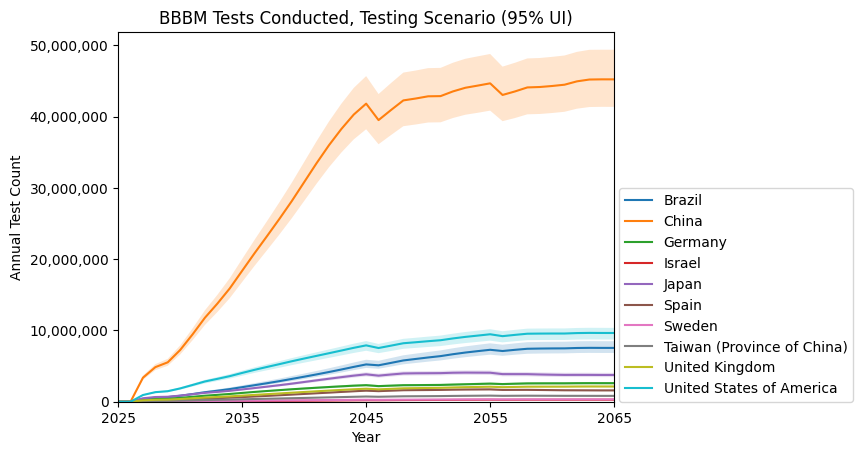

In [39]:
make_forecast_plot(
    filter_results(
        res2,
        ["Year", "Location"],
        measure=["BBBM Tests"],
        scenario=["BBBM Testing and Treatment"],
    ),
    "BBBM Tests Conducted, Testing Scenario (95% UI)",
    "Annual Test Count",
)

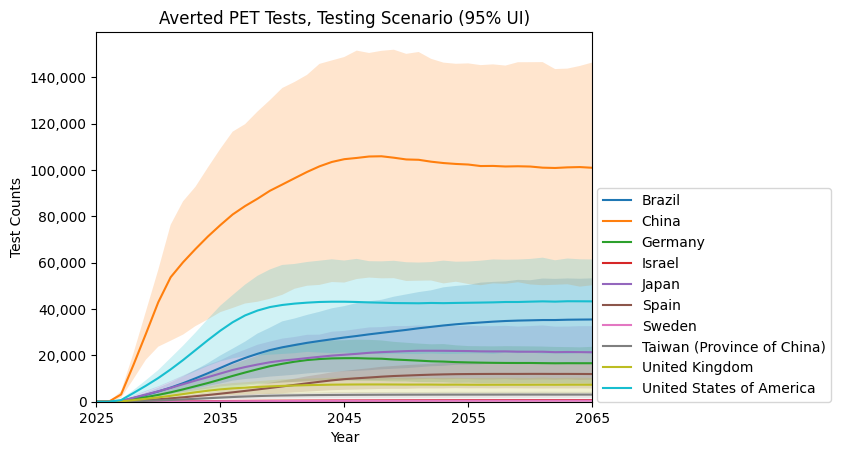

In [40]:
make_forecast_plot(
    filter_results(
        res2,
        ["Year", "Location"],
        measure=["Averted PET Tests"],
        scenario=["BBBM Testing Only"],
    ),
    "Averted PET Tests, Testing Scenario (95% UI)",
    "Test Counts",
)

In [41]:
res2[
    (res2["Year"] == 2100)
    & (res2["Location"] == "United States of America")
    & (res2["Age"] == "65_plus")
    & (res2["Sex"] == "Both")
    & (res2["Disease Stage"] == "Preclinical AD")
    & (res2["Scenario"] == "BBBM Testing Only")
    & (res2["Measure"] == "Positive BBBM Tests")
    & (res2["Metric"] == "Number")
]

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
127670,2100,United States of America,65_plus,Both,Preclinical AD,BBBM Testing Only,Positive BBBM Tests,Number,194404.591676,174102.010132,...,207863.304946,214620.98646,219832.873733,193832.468854,200388.685006,196869.829197,190074.648546,203964.221859,198328.399928,190717.490796


In [42]:
# PPV, true pos, false neg estimated for now
def get_true_pos(strat_col="Measure"):
    # True Pos = Positive in Preclinical state
    pos_sim = filter_results(
        res2,
        ["Year", strat_col],
        location=["United States of America"],
        scenario=["BBBM Testing Only"],
        stage=[
            "Preclinical AD",
            "MCI due to AD",
            "AD Dementia",
        ],  # should only be in preclinical state
        measure=["Positive BBBM Tests"],
    ).drop(["Measure", "Disease Stage", "95% UI Lower", "95% UI Upper"], axis=1)
    pos_sim = pos_sim.set_index(pos_sim.columns.drop("Mean").tolist())
    return pos_sim


def get_false_neg(strat_col="Measure"):
    # False Neg = Negative in Preclinical state
    all_preclinical = filter_results(
        res2,
        ["Year", strat_col],
        location=["United States of America"],
        scenario=["BBBM Testing Only"],
        stage=[
            "Preclinical AD",
            "MCI due to AD",
            "AD Dementia",
        ],  # should only be in preclinical state
        measure=["BBBM Tests"],
    ).drop(["Measure", "Disease Stage", "95% UI Lower", "95% UI Upper"], axis=1)
    all_preclinical = all_preclinical.set_index(
        all_preclinical.columns.drop("Mean").tolist()
    )
    # all preclinical - positive preclinical
    return all_preclinical - get_true_pos(strat_col)


def get_false_pos(strat_col="Measure"):
    # False Pos = Positive in Susceptible state
    pos_susc = filter_results(
        res2,
        ["Year", strat_col],
        location=["United States of America"],
        scenario=["BBBM Testing Only"],
        stage=["Susceptible"],
        measure=["Positive BBBM Tests"],
    )
    pos_susc = pos_susc.drop(
        ["Measure", "Disease Stage", "95% UI Lower", "95% UI Upper"], axis=1
    )

    pos_susc = pos_susc.set_index(pos_susc.columns.drop("Mean").tolist())
    return pos_susc


def get_true_neg(strat_col="Measure"):
    # True Neg = Negative in Susceptible state
    # outside sim negatives = outside sim tests - outside sim positives

    all_susc = filter_results(
        res2,
        ["Year", strat_col],
        location=["United States of America"],
        scenario=["BBBM Testing Only"],
        stage=["Susceptible"],
        measure=["BBBM Tests"],
    )
    all_susc = all_susc.drop(
        ["Measure", "Disease Stage", "95% UI Lower", "95% UI Upper"], axis=1
    )

    all_susc = all_susc.set_index(all_susc.columns.drop("Mean").tolist())

    # all suseptible - positive susceptible
    return all_susc - get_false_pos(strat_col)


def calc_ppv(strat_col="Measure"):
    true_pos = get_true_pos(strat_col)
    ppv = true_pos / (get_false_pos(strat_col) + true_pos)
    ppv = ppv.reset_index()
    ppv["Measure"] = "Positive Predictive Value"
    return ppv


def concat_all_tests(strat_col="Measure"):
    true_pos = get_true_pos(strat_col).reset_index()
    true_pos["Measure"] = "True Positive BBBM Tests"
    false_pos = get_false_pos(strat_col).reset_index()
    false_pos["Measure"] = "False Positive BBBM Tests"
    true_neg = get_true_neg(strat_col).reset_index()
    true_neg["Measure"] = "True Negative BBBM Tests"
    false_neg = get_false_neg(strat_col).reset_index()
    false_neg["Measure"] = "False Negative BBBM Tests"
    return pd.concat([true_pos, false_pos, true_neg, false_neg])

In [43]:
get_true_neg()

Mean
Year Location                 Scenario          Metric draw_1       draw_6       draw_7       draw_24      draw_35      draw_41      draw_50      draw_63      draw_69      draw_103     draw_122     draw_123     draw_161     draw_172     draw_183     draw_187     draw_199     draw_204     draw_211     draw_219     draw_235     draw_236     draw_245     draw_248     draw_249          
2025 United States of America BBBM Testing Only Number 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00   0.0
2026 United States of America BBBM Testing Only Number 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00   0.0
2027 United States of America BBBM Testing Only Number 1.838294e+03 1.676265e+03 1.739952e+03 1.787834e+03 1.808300e+03 1.768198e+03 1.710530e+03 1.737290e+03 1.812383e+03 1.799321e+03 1.670473e+03 1.821046e+03 1.526438e+03 1.666209e+03 1.816961e+03 1.764907e+03 1.793760e+03 1.892870e+03 1.697571e+03 1.661531e+03 1.734994e+03 1.629361e+03 1.741230e+03 1.770410e+03 1.683263e+03   NaN
                                                       9.191472e+05 8.381324e+05 8.699759e+05 8.939169e+05 9.041500e+05 8.840991e+05 8.552649e+05 8.686448e+05 9.061913e+05 8.996605e+05 8.352367e+05 9.105228e+05 7.632191e+05 8.331044e+05 9.084803e+05 8.824534e+05 8.968798e+05 9.464348e+05 8.487855e+05 8.307657e+05 8.674968e+05 8.146807e+05 8.706150e+05 8.852052e+05 8.416314e+05   NaN
2028 United States of America BBBM Testing Only Number 2.660465e+03 2.425328e+03 2.519459e+03 2.589222e+03 2.616943e+03 2.560030e+03 2.478215e+03 2.513918e+03 2.619676e+03 2.597995e+03 2.414025e+03 2.633692e+03 2.205553e+03 2.413689e+03 2.631272e+03 2.555784e+03 2.595310e+03 2.741207e+03 2.460334e+03 2.406812e+03 2.509213e+03 2.357793e+03 2.519515e+03 2.558167e+03 2.438241e+03   NaN
...                                                                                                                                                                                                                                                                                                                                                                                           ...
2098 United States of America BBBM Testing Only Number 9.750247e+06 8.910906e+06 9.283794e+06 9.461116e+06 9.639813e+06 9.308133e+06 9.077987e+06 9.163945e+06 9.619876e+06 9.601055e+06 8.914851e+06 9.748478e+06 8.150766e+06 8.840890e+06 9.637366e+06 9.374584e+06 9.536117e+06 1.008072e+07 9.093141e+06 8.833577e+06 9.271791e+06 8.609441e+06 9.241912e+06 9.449903e+06 8.964246e+06   NaN
2099 United States of America BBBM Testing Only Number 1.950049e+04 1.782181e+04 1.856759e+04 1.892223e+04 1.927963e+04 1.861627e+04 1.815597e+04 1.832789e+04 1.923975e+04 1.920211e+04 1.782970e+04 1.949696e+04 1.630153e+04 1.768178e+04 1.927473e+04 1.874917e+04 1.907223e+04 2.016143e+04 1.818628e+04 1.766715e+04 1.854358e+04 1.721888e+04 1.848382e+04 1.889981e+04 1.792849e+04   NaN
                                                       9.750247e+06 8.910906e+06 9.283794e+06 9.461116e+06 9.639813e+06 9.308133e+06 9.077987e+06 9.163945e+06 9.619876e+06 9.601055e+06 8.914851e+06 9.748478e+06 8.150766e+06 8.840890e+06 9.637366e+06 9.374584e+06 9.536117e+06 1.008072e+07 9.093141e+06 8.833577e+06 9.271791e+06 8.609441e+06 9.241912e+06 9.449903e+06 8.964246e+06   NaN
2100 United States of America BBBM Testing Only Number 1.950049e+04 1.782181e+04 1.856759e+04 1.892223e+04 1.927963e+04 1.861627e+04 1.

,Year,Location,Scenario,Metric,draw_1,draw_6,draw_7,draw_24,draw_35,draw_41,...,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249,Measure,Mean
436,2099,United States of America,BBBM Testing Only,Number,1.950049e+04,1.782181e+04,1.856759e+04,1.892223e+04,1.927963e+04,1.861627e+04,...,2.016143e+04,1.818628e+04,1.766715e+04,1.854358e+04,1.721888e+04,1.848382e+04,1.889981e+04,1.792849e+04,Negative BBBM Tests,0.000000
437,2099,United States of America,BBBM Testing Only,Number,1.950049e+04,1.782181e+04,1.856759e+04,1.892223e+04,1.927963e+04,1.861627e+04,...,2.016143e+04,1.818628e+04,1.766715e+04,1.854358e+04,1.721888e+04,1.848382e+04,1.889981e+04,1.792849e+04,Positive BBBM Tests,18525.172079
438,2099,United States of America,BBBM Testing Only,Number,1.959202e+05,1.841056e+05,1.876900e+05,1.859623e+05,1.961781e+05,1.754415e+05,...,2.194160e+05,1.939128e+05,1.984229e+05,2.000096e+05,1.894587e+05,2.053585e+05,1.967112e+05,1.906827e+05,Negative BBBM Tests,0.000000
439,2099,United States of America,BBBM Testing Only,Number,1.959202e+05,1.841056e+05,1.876900e+05,1.859623e+05,1.961781e+05,1.754415e+05,...,2.194160e+05,1.939128e+05,1.984229e+05,2.000096e+05,1.894587e+05,2.053585e+05,1.967112e+05,1.906827e+05,Positive BBBM Tests,194369.390890
440,2099,United States of America,BBBM Testing Only,Number,3.898400e+05,3.672914e+05,3.765996e+05,3.724350e+05,3.908294e+05,3.504236e+05,...,4.394752e+05,3.900968e+05,3.965965e+05,3.987976e+05,3.788757e+05,4.110070e+05,3.948953e+05,3.823071e+05,Negative BBBM Tests,0.000000
441,2099,United States of America,BBBM Testing Only,Number,9.750247e+06,8.910906e+06,9.283794e+06,9.461116e+06,9.639813e+06,9.308133e+06,...,1.008072e+07,9.093141e+06,8.833577e+06,9.271791e+06,8.609441e+06,9.241912e+06,9.449903e+06,8.964246e+06,Negative BBBM Tests,0.000000


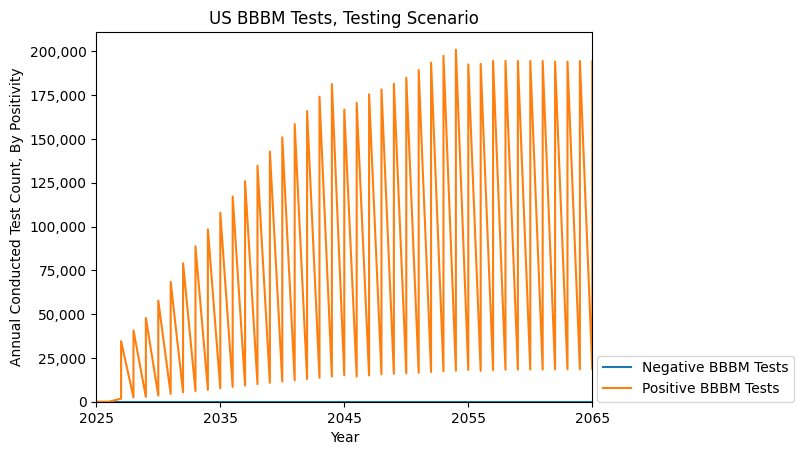

In [44]:
# This ignores out of sim tests
# make_forecast_plot(
#     filter_results(
#         res2,
#         ["Year"],
#         location=["United States of America"],
#         measure=["BBBM Tests"],
#         scenario=["BBBM Testing and Treatment"],
#     ),
#     "US BBBM Tests, Testing Scenario (95% UI)",
#     "Annual Conducted Test Count",
#     "Measure",
# )

df = concat_all_tests()
df["Measure"] = df["Measure"].replace(
    {
        "True Positive BBBM Tests": "Positive BBBM Tests",
        "False Positive BBBM Tests": "Positive BBBM Tests",
        "True Negative BBBM Tests": "Negative BBBM Tests",
        "False Negative BBBM Tests": "Negative BBBM Tests",
    }
)
# tmp = df.groupby(list(df.columns.difference(["Mean"], sort=False))).sum().reset_index()
make_forecast_plot(
    df.groupby(list(df.columns.difference(["Mean"], sort=False))).sum().reset_index(),
    "US BBBM Tests, Testing Scenario",
    "Annual Conducted Test Count, By Positivity",
    "Measure",
)
tmp = df.groupby(list(df.columns.difference(["Mean"], sort=False))).sum().reset_index()
tmp[tmp["Year"] == 2099]

/tmp/ipykernel_3848047/167465172.py:97: RuntimeWarning: All-NaN axis encountered
  np.nanmin(data["Mean"]),
/tmp/ipykernel_3848047/167465172.py:98: RuntimeWarning: All-NaN axis encountered
  np.nanmax(data["Mean"]),
/tmp/ipykernel_3848047/167465172.py:97: RuntimeWarning: All-NaN axis encountered
  np.nanmin(data["Mean"]),
/tmp/ipykernel_3848047/167465172.py:98: RuntimeWarning: All-NaN axis encountered
  np.nanmax(data["Mean"]),


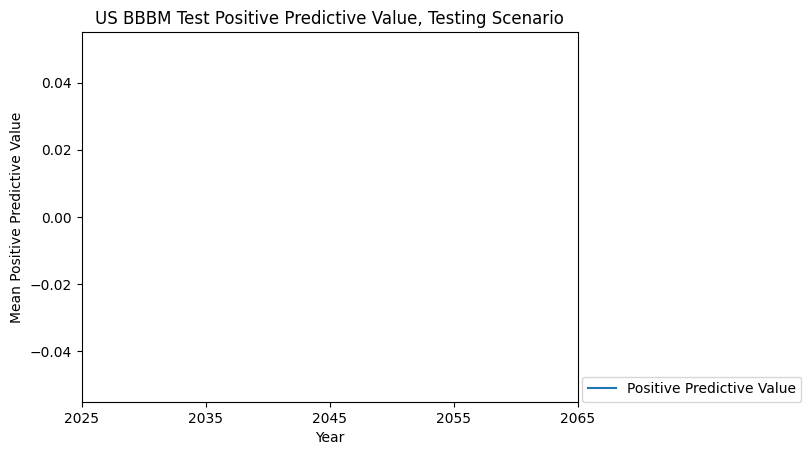

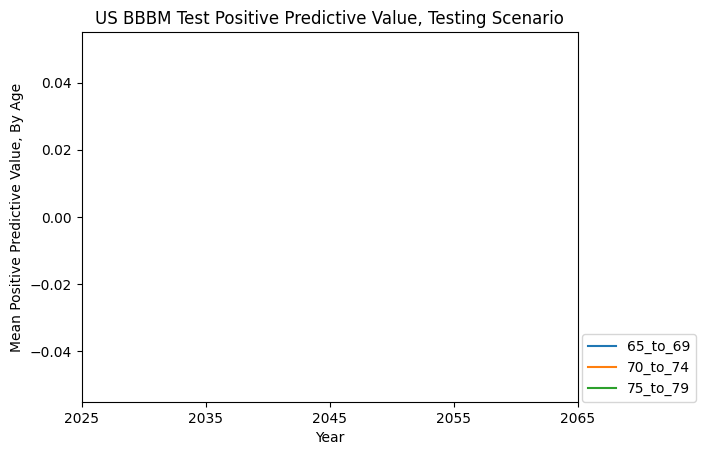

In [45]:
make_forecast_plot(
    calc_ppv("Measure"),
    "US BBBM Test Positive Predictive Value, Testing Scenario",
    "Mean Positive Predictive Value",
    "Measure",
)
make_forecast_plot(
    calc_ppv("Age"),
    "US BBBM Test Positive Predictive Value, Testing Scenario",
    "Mean Positive Predictive Value, By Age",
    "Age",
)

# TBD need to filter by stage once Testing Only scenario includes susceptible tests

,Year,Location,Age,Scenario,Metric,draw_1,draw_6,draw_7,draw_24,draw_35,...,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249,Mean,Measure
234,2065,United States of America,65_to_69,BBBM Testing Only,Number,7853.836003,7177.745683,7478.107466,7620.940657,7764.881924,...,8120.028842,7324.536337,7115.457478,7468.439267,6934.915680,7444.372060,7611.908656,7220.711861,NaN,Positive Predictive Value
235,2065,United States of America,65_to_69,BBBM Testing Only,Number,43509.944726,41162.030895,43295.024653,45393.115286,52043.396348,...,56129.315980,54107.897509,44927.103429,49704.289482,46074.590316,44750.325828,44686.061896,42566.587352,NaN,Positive Predictive Value
236,2065,United States of America,70_to_74,BBBM Testing Only,Number,5918.152115,5408.693380,5635.026947,5742.656971,5851.121969,...,6118.738136,5519.305496,5361.756943,5627.741606,5225.712108,5609.606087,5735.851028,5441.069963,NaN,Positive Predictive Value
237,2065,United States of America,70_to_74,BBBM Testing Only,Number,66165.530129,75842.902712,77698.655678,69015.765402,73939.056475,...,71167.002445,69681.536521,71219.197417,67620.443130,67777.423923,80298.503400,81334.183714,77854.013778,NaN,Positive Predictive Value
238,2065,United States of America,75_to_79,BBBM Testing Only,Number,5712.288199,5219.940121,5439.267275,5543.461608,5647.691279,...,5906.185351,5328.160310,5175.594868,5432.047320,5044.257738,5414.425205,5536.014927,5251.990611,NaN,Positive Predictive Value
239,2065,United States of America,75_to_79,BBBM Testing Only,Number,85820.302412,67574.685145,67428.807357,71024.729781,69062.829691,...,91548.069582,70565.199039,83530.517403,82619.250367,74423.633991,79357.839356,70742.754386,71241.964498,NaN,Positive Predictive Value


(0.0, 100.0)

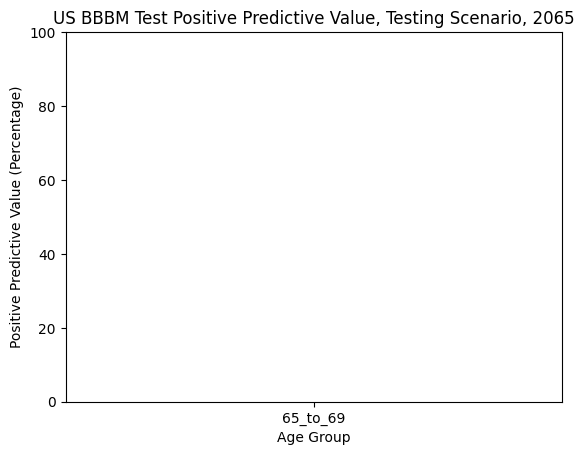

In [46]:
# df = calc_ppv("Age").drop("Year", axis=1)
# df = df.groupby(list(df.columns.difference(["Mean"], sort=False))).mean().reset_index()
df = calc_ppv("Age")
df = df[df["Year"] == 2065]
df = df[df["Age"] != "65_plus"]
display(df)

plt.bar(df["Age"], df["Mean"] * 100)
plt.xlabel("Age Group")
plt.ylabel("Positive Predictive Value (Percentage)")
plt.title("US BBBM Test Positive Predictive Value, Testing Scenario, 2065")
plt.ylim(0, 100)

,Year,Location,Age,Scenario,Metric,draw_1,draw_6,draw_7,draw_24,draw_35,...,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249,Mean,Measure
24,2030,United States of America,65_to_69,BBBM Testing Only,Number,1751.961062,1596.923263,1661.211318,1711.059620,1732.094351,...,1811.426075,1627.089747,1580.160187,1655.730783,1548.037411,1662.091361,1700.453708,1598.753203,NaN,Positive Predictive Value
25,2030,United States of America,65_to_69,BBBM Testing Only,Number,11637.839814,10957.582602,11742.124539,12075.662476,14086.877375,...,14851.104822,14573.128557,11548.863714,13029.598409,12071.048547,11771.313690,12119.822171,11177.594605,NaN,Positive Predictive Value
26,2030,United States of America,70_to_74,BBBM Testing Only,Number,1107.560256,1002.947072,1050.461370,1087.855067,1091.556555,...,1145.754558,1033.281917,1005.382474,1044.185341,980.410854,1046.176952,1063.930660,1012.380309,NaN,Positive Predictive Value
27,2030,United States of America,70_to_74,BBBM Testing Only,Number,20706.717841,22740.231500,23311.040112,21642.854003,22994.421406,...,22556.529698,21591.307732,21908.873811,20257.324143,20370.111903,24126.359613,25124.113806,23387.127538,NaN,Positive Predictive Value
28,2030,United States of America,75_to_79,BBBM Testing Only,Number,835.180555,765.559238,788.724089,802.774247,812.192452,...,853.657037,763.556918,760.535413,783.605318,742.763751,788.468497,786.001879,775.563630,NaN,Positive Predictive Value
29,2030,United States of America,75_to_79,BBBM Testing Only,Number,25959.063561,21069.033385,21243.358071,21475.136469,21819.883486,...,27363.984373,21748.322146,25334.506728,25121.999284,23895.039023,24684.065568,23418.086930,22549.763441,NaN,Positive Predictive Value


(0.0, 100.0)

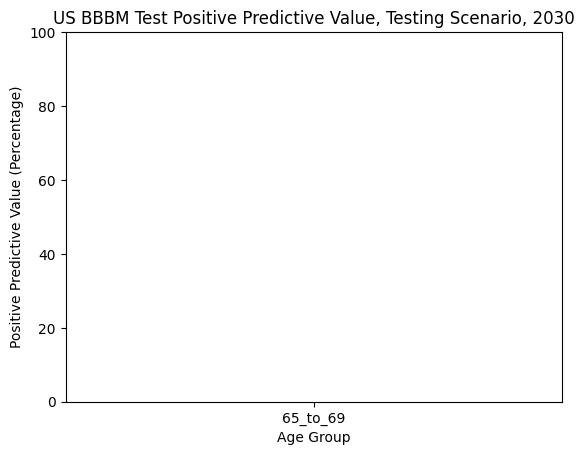

In [47]:
df = calc_ppv("Age")
df = df[df["Year"] == 2030]
df = df[df["Age"] != "65_plus"]
display(df)

plt.bar(df["Age"], df["Mean"] * 100)
plt.xlabel("Age Group")
plt.ylabel("Positive Predictive Value (Percentage)")
plt.title("US BBBM Test Positive Predictive Value, Testing Scenario, 2030")
plt.ylim(0, 100)  

,Year,Location,Scenario,Metric,draw_1,draw_6,draw_7,draw_24,draw_35,draw_41,...,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249,Mean,Measure
22,2025,United States of America,BBBM Testing Only,Number,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True Positive BBBM Tests
58,2026,United States of America,BBBM Testing Only,Number,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True Positive BBBM Tests
94,2027,United States of America,BBBM Testing Only,Number,35160.818923,33199.263403,34017.519370,34294.589749,34955.764029,31796.994601,...,39098.778774,35047.077898,34538.185038,34997.216886,33091.862692,36604.100846,36366.867930,33650.918170,34585.305914,True Positive BBBM Tests
130,2028,United States of America,BBBM Testing Only,Number,41579.532350,39185.382704,39679.287472,39001.618812,41131.560189,37262.159117,...,46486.617874,41499.274881,40832.966199,41758.167194,39261.355074,43233.365631,41399.832251,39908.564389,40704.258900,True Positive BBBM Tests
166,2029,United States of America,BBBM Testing Only,Number,47869.059480,45438.331955,46585.995022,46585.368194,47708.972541,43089.754110,...,54362.745104,47538.852589,48782.747229,49098.940101,47170.693023,50200.972029,49371.159566,47361.452305,47867.761839,True Positive BBBM Tests
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2578,2096,United States of America,BBBM Testing Only,Number,194809.244376,184003.827804,187971.422671,186789.934877,194420.125234,175362.524450,...,218387.858455,194442.269021,199506.982019,197952.894052,187715.417957,204179.868162,196644.577306,190623.678221,193892.281369,True Positive BBBM Tests
2614,2097,United States of America,BBBM Testing Only,Number,194580.400079,185868.126542,188473.006970,185229.432601,196791.934066,173837.445711,...,218737.202808,194358.284567,199376.894693,198904.678319,189253.441439,204771.036474,197880.614132,192062.137707,194176.165731,True Positive BBBM Tests
2650,2098,United States of America,BBBM Testing Only,Number,193772.062966,185299.357435,188523.526252,187858.222651,195973.546354,176564.645338,...,217693.139571,195059.372185,197584.580425,198295.682256,187865.044676,205931.064861,199035.235359,190536.814726,194187.889683,True Positive BBBM Tests
2686,2099,United States of America,BBBM Testing Only,Number,195920.246528,184105.644496,187689.958100,185962.285305,196178.143282,175441.469702,...,219416.042403,193912.801810,198422.920970,200009.623272,189458.743216,205358.486747,196711.190069,190682.745398,194369.390890,True Positive BBBM Tests


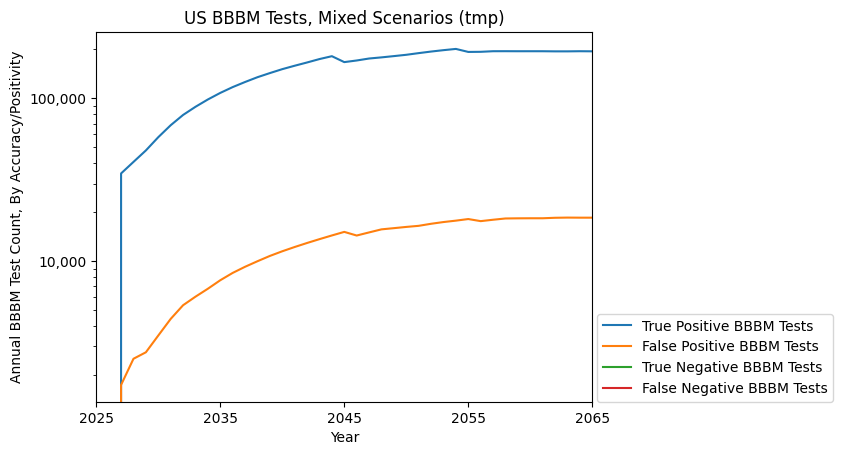

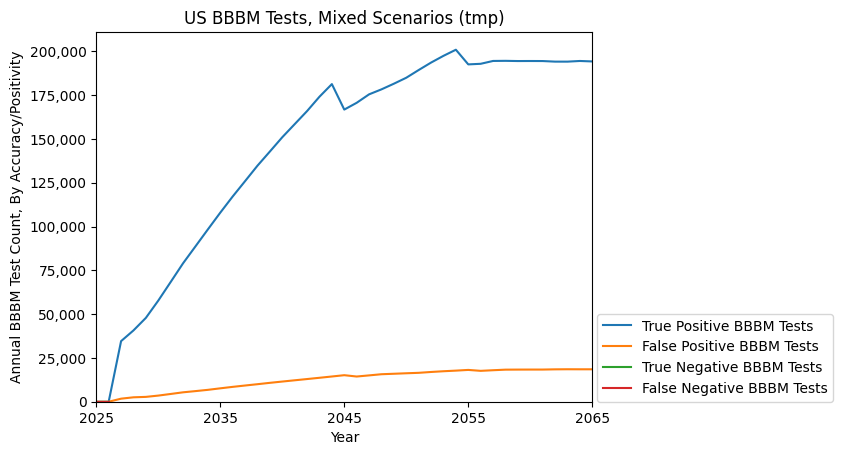

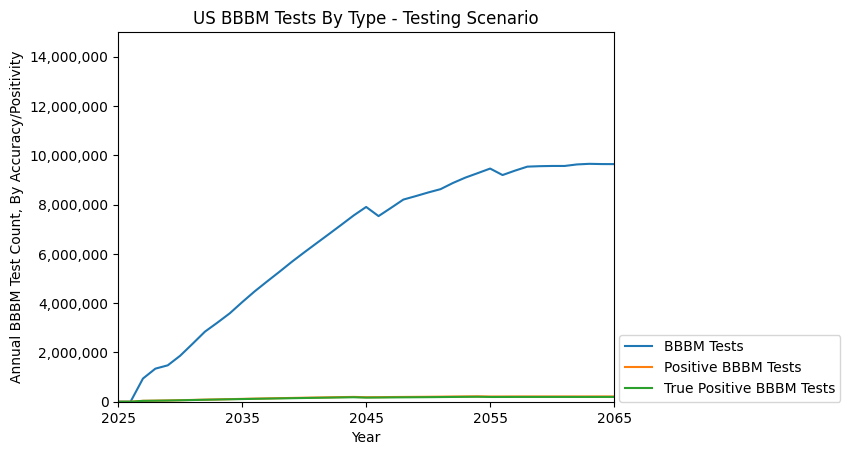

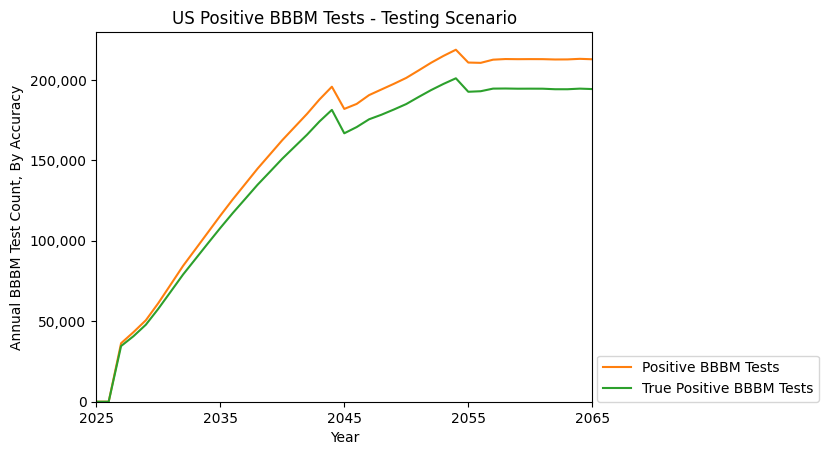

In [48]:
# Test accuracy by stage (outside vs inside sim)

# Inside sim- stage=preclinical, positive vs negative
# true pos vs false neg

# Outside sim- stage=susceptible, positive vs negative
# false pos vs true neg
make_forecast_plot(
    concat_all_tests(),
    "US BBBM Tests, Mixed Scenarios (tmp)",
    "Annual BBBM Test Count, By Accuracy/Positivity",
    "Measure",
    scale="log",
)

make_forecast_plot(
    concat_all_tests(),
    "US BBBM Tests, Mixed Scenarios (tmp)",
    "Annual BBBM Test Count, By Accuracy/Positivity",
    "Measure",
)


all = filter_results(
    res2,
    ["Year"],
    location=["United States of America"],
    scenario=["BBBM Testing Only"],
    measure=["BBBM Tests"],
).drop(["Measure", "95% UI Lower", "95% UI Upper"], axis=1)

pos = filter_results(
    res2,
    ["Year"],
    location=["United States of America"],
    scenario=["BBBM Testing Only"],
    measure=["Positive BBBM Tests", "Positive BBBM Tests"],
).drop(["Measure", "95% UI Lower", "95% UI Upper"], axis=1)
pos = pos.groupby(pos.columns.drop("Mean").tolist()).sum().reset_index()

true_pos = filter_results(
    res2,
    ["Year"],
    location=["United States of America"],
    scenario=["BBBM Testing Only"],
    stage=[
        "Preclinical AD",
        "MCI due to AD",
        "AD Dementia",
    ],  # should only be in preclinical state
    measure=["Positive BBBM Tests"],
).drop(["Measure", "Disease Stage", "95% UI Lower", "95% UI Upper"], axis=1)

all["Measure"] = "BBBM Tests"
pos["Measure"] = "Positive BBBM Tests"
true_pos["Measure"] = "True Positive BBBM Tests"
df = pd.concat([all, pos, true_pos])

# TODO: label highest points with dot and value, can include uncertainty
make_forecast_plot(
    df,
    "US BBBM Tests By Type - Testing Scenario",
    "Annual BBBM Test Count, By Accuracy/Positivity",
    "Measure",
)
# NOTE: Set y-limit of "US BBBM Tests By Type - Testing Scenario" for
# new results higher to match higher value from old results, for easier
# comparison.
plt.ylim(0, 15_000_000)

save_for_maxes = df
df = pd.concat([pos, true_pos])
make_forecast_plot(
    df,
    "US Positive BBBM Tests - Testing Scenario",
    "Annual BBBM Test Count, By Accuracy",
    "Measure",
    colors=["tab:orange", "tab:green"],
)
df[df["Measure"] == "True Positive BBBM Tests"]

In [49]:
# NOTE: Fails with IndexError: single positional indexer is out-of-bounds

# df = save_for_maxes
# tests = df[df["Measure"] == "BBBM Tests"]
# positives = df[df["Measure"] == "Positive BBBM Tests"]
# true_positives = df[df["Measure"] == "True Positive BBBM Tests"]

# display(tests.iloc[tests["Mean"].idxmax()])
# display(positives.iloc[positives["Mean"].idxmax()])
# display(true_positives[true_positives["Mean"].idxmax()])

In [50]:
# Pop 60-65 * 60% * 90% * 1/3 = true negative tests
# True negative increase?

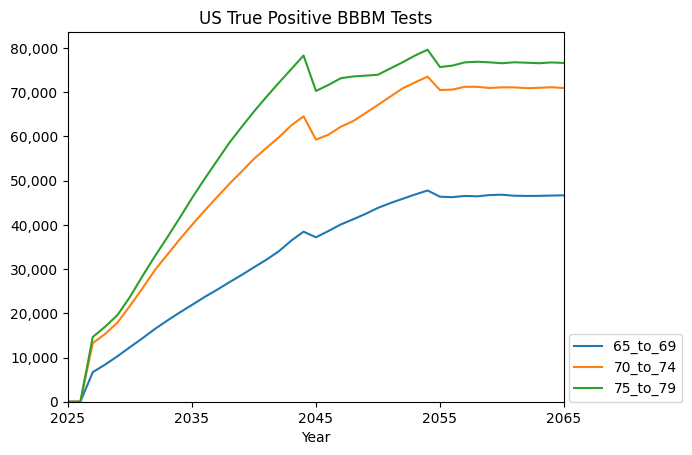

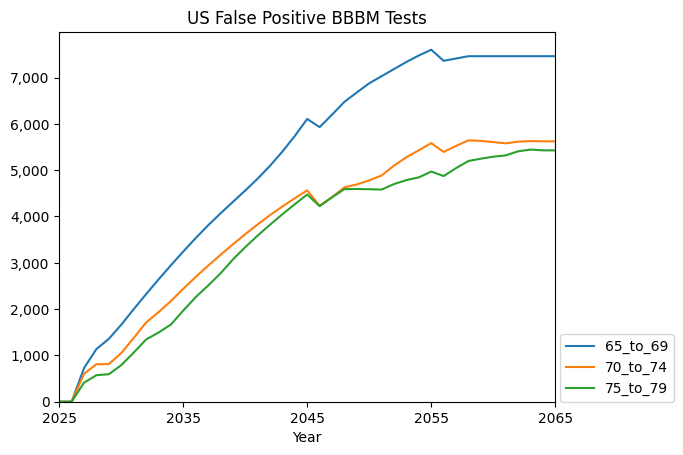

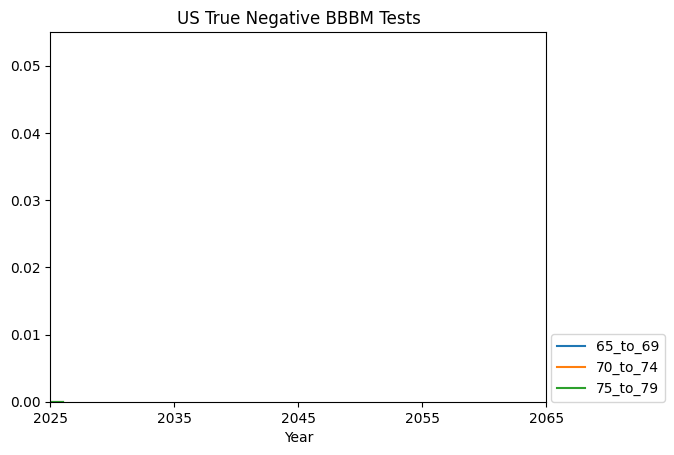

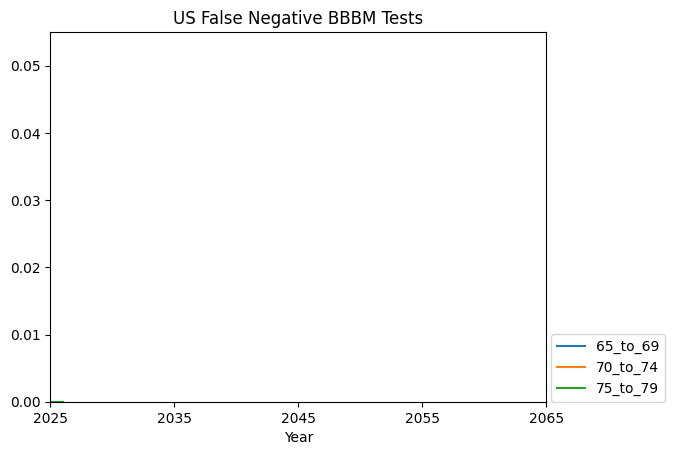

In [51]:
make_forecast_plot(
    get_true_pos("Age").reset_index(), "US True Positive BBBM Tests", "", "Age"
)
# also plot US population with these age groups to check false positive age group order (inside sim vs outsdie sim, also PPV)
make_forecast_plot(
    get_false_pos("Age").reset_index(), "US False Positive BBBM Tests", "", "Age"
)
make_forecast_plot(
    get_true_neg("Age").reset_index(), "US True Negative BBBM Tests", "", "Age"
)
make_forecast_plot(
    get_false_neg("Age").reset_index(), "US False Negative BBBM Tests", "", "Age"
)

In [52]:
art = Artifact(
    "/mnt/team/simulation_science/pub/models/vivarium_csu_alzheimers/artifacts/model10.0/united_states_of_america.hdf"
)
df = art.load("population.structure").mean(axis=1)
df = df.reset_index()

In [53]:
df[
    (df["year_start"] == 2050)
    # & (df["sex"] == "Female")
    & (df["age_start"] >= 60)
    & (df["age_start"] < 80)
][0].sum()

71772396.44467545

# Treatment

In [54]:
dalys = pd.read_csv(Path(results_dir_new) / "dalys.csv")
deaths = pd.read_csv(Path(results_dir_new) / "deaths.csv")
medication = pd.read_csv(Path(results_dir_new) / "medication.csv")
res3 = pd.concat([dalys, deaths, medication])

# Load Dec 2025 results for comparison for Feb 2026 updates
v3_res3 = pd.concat(
    [
        pd.read_csv(Path(results_dir_v3) / "dalys.csv"),
        pd.read_csv(Path(results_dir_v3) / "deaths.csv"),
        pd.read_csv(Path(results_dir_v3) / "medication.csv"),
    ]
)
display(res3["Measure"].unique())
res3

array(['DALYs Associated with AD', 'Averted DALYs Associated with AD',
       'Deaths Associated with AD', 'Averted Deaths Associated with AD',
       'Medication Discontinuation', 'Medication Completion',
       'Medication Initiation'], dtype=object)

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
0,2025,Brazil,65_to_69,Female,Preclinical AD,Reference,DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2025,Brazil,65_to_69,Male,Preclinical AD,Reference,DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2025,Brazil,65_to_69,Both,Preclinical AD,Reference,DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2025,Brazil,65_to_69,Female,Preclinical AD,BBBM Testing Only,DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2025,Brazil,65_to_69,Male,Preclinical AD,BBBM Testing Only,DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72955,2100,United States of America,65_plus,Male,Susceptible,BBBM Testing and Treatment,Medication Initiation,Number,7005.536753,6363.678942,...,7156.996365,7258.181202,7647.701249,6897.053865,6681.825102,7001.962143,6507.254994,6992.756367,7147.730345,6781.399068
72956,2100,United States of America,65_plus,Both,Susceptible,BBBM Testing and Treatment,Medication Initiation,Number,14679.795450,13353.887512,...,14857.294954,15113.300563,15976.406224,14411.250281,13999.881201,14694.383715,13644.659666,14647.030746,14976.664146,14206.972434
72957,2100,United States of America,65_plus,Female,Susceptible,BBBM Testing and Treatment,Medication Initiation,Rate,0.000179,0.000175,...,0.000177,0.000180,0.000179,0.000176,0.000178,0.000178,0.000180,0.000180,0.000183,0.000175
72958,2100,United States of America,65_plus,Male,Susceptible,BBBM Testing and Treatment,Medication Initiation,Rate,0.000198,0.000194,...,0.000199,0.000197,0.000201,0.000198,0.000195,0.000196,0.000200,0.000199,0.000200,0.000193


In [55]:
# Check 2099 vs 2100 data
display(
    res3[
        (res3["Year"] == 2099)
        & ((res3["Age"] == "70_to_74") | (res3["Age"] == "70_to_75"))
        & (res3["Location"] == "United States of America")
        & (res3["Sex"] == "Female")
    ]
)
display(
    res3[
        (res3["Year"] == 2100)
        & ((res3["Age"] == "70_to_74") | (res3["Age"] == "70_to_75"))
        & (res3["Location"] == "United States of America")
        & (res3["Sex"] == "Female")
    ]
)

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
132180,2099,United States of America,70_to_74,Female,Preclinical AD,Reference,DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132183,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132186,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132189,2099,United States of America,70_to_74,Female,Preclinical AD,Reference,DALYs Associated with AD,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132192,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,DALYs Associated with AD,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132195,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,DALYs Associated with AD,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132198,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,Averted DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132201,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,Averted DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132204,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,Averted DALYs Associated with AD,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132207,2099,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,Averted DALYs Associated with AD,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
132210,2100,United States of America,70_to_74,Female,Preclinical AD,Reference,DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132213,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132216,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132219,2100,United States of America,70_to_74,Female,Preclinical AD,Reference,DALYs Associated with AD,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132222,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,DALYs Associated with AD,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132225,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,DALYs Associated with AD,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132228,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,Averted DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132231,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,Averted DALYs Associated with AD,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132234,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing Only,Averted DALYs Associated with AD,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
132237,2100,United States of America,70_to_74,Female,Preclinical AD,BBBM Testing and Treatment,Averted DALYs Associated with AD,Rate,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Get the number of treatments in a specific year

In [56]:
# Hmm, looks like MSLT didn't start treatment until 2035, whereas it
# should have been a slow ramp-up starting in 2027
display(
    res3[
        (res3["Year"].isin([2030, 2065, 2100]))
        & (res3["Age"] == "65_plus")
        & (res3["Location"] == "United States of America")
        & (res3["Sex"] == "Both")
        & (res3["Scenario"] == "BBBM Testing and Treatment")
        & (res3["Measure"] == "Medication Initiation")
        & (res3["Metric"] == "Number")
    ]
)

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
55796,2030,United States of America,65_plus,Both,Preclinical AD,BBBM Testing and Treatment,Medication Initiation,Number,7607.120537,6786.057814,...,7610.746031,8082.531710,8678.031313,7449.055940,7592.040884,7668.974379,7592.686056,7978.913196,8371.003893,7710.003864
62096,2065,United States of America,65_plus,Both,Preclinical AD,BBBM Testing and Treatment,Medication Initiation,Number,103510.708270,93265.956184,...,110567.436996,114420.163637,116772.319793,103669.679996,106454.795064,106946.272753,99265.149002,108990.615764,105396.194021,101647.662475
68396,2100,United States of America,65_plus,Both,Preclinical AD,BBBM Testing and Treatment,Medication Initiation,Number,155498.278836,139131.995247,...,165924.844445,171562.145164,175176.343889,155597.633193,160123.044090,157861.260996,152062.502590,163218.224788,158679.003063,152685.177911
68756,2030,United States of America,65_plus,Both,Susceptible,BBBM Testing and Treatment,Medication Initiation,Number,421.170134,383.319588,...,427.355509,433.687064,458.491407,411.941408,402.575018,419.111174,393.567696,420.701148,427.155845,407.462000
70856,2065,United States of America,65_plus,Both,Susceptible,BBBM Testing and Treatment,Medication Initiation,Number,9759.735434,8878.259740,...,9877.988607,10047.867346,10621.883955,9581.601130,9307.844898,9769.429411,9071.666914,9737.885404,9956.899340,9445.443648
72956,2100,United States of America,65_plus,Both,Susceptible,BBBM Testing and Treatment,Medication Initiation,Number,14679.795450,13353.887512,...,14857.294954,15113.300563,15976.406224,14411.250281,13999.881201,14694.383715,13644.659666,14647.030746,14976.664146,14206.972434


In [57]:
# Add up all treatments in 2065
103510.708270 + 9759.735434

113270.443704

In [58]:
# Check that treatments start in 2027 as expected
display(
    res3[
        (res3["Year"].isin([2026, 2027, 2028, 2034, 2035, 2036]))
        & (res3["Age"] == "65_plus")
        & (res3["Location"] == "United States of America")
        & (res3["Sex"] == "Both")
        & (res3["Scenario"] == "BBBM Testing and Treatment")
        & (res3["Measure"] == "Medication Initiation")
        & (res3["Metric"] == "Number")
    ]
)

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
55076,2026,United States of America,65_plus,Both,Preclinical AD,BBBM Testing and Treatment,Medication Initiation,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
55256,2027,United States of America,65_plus,Both,Preclinical AD,BBBM Testing and Treatment,Medication Initiation,Number,905.102789,799.484068,...,990.077190,957.295523,952.757326,909.223004,993.722629,856.970508,849.044637,985.280520,899.272302,917.278513
55436,2028,United States of America,65_plus,Both,Preclinical AD,BBBM Testing and Treatment,Medication Initiation,Number,2507.660636,2180.442835,...,2667.917923,2731.794540,2735.207491,2567.003101,2471.659193,2567.264842,2585.410513,2710.450941,2564.591378,2213.281866
56516,2034,United States of America,65_plus,Both,Preclinical AD,BBBM Testing and Treatment,Medication Initiation,Number,26838.314151,24100.326554,...,28096.274448,29734.532883,29650.601956,26743.571424,27097.912701,27313.655775,26299.505597,28844.551992,27570.282495,26503.789758
56696,2035,United States of America,65_plus,Both,Preclinical AD,BBBM Testing and Treatment,Medication Initiation,Number,32547.521230,29427.076151,...,34282.367423,36260.486507,36339.752350,32611.528725,33461.351062,32634.166293,31369.415580,34518.280574,33720.860952,31986.613596
56876,2036,United States of America,65_plus,Both,Preclinical AD,BBBM Testing and Treatment,Medication Initiation,Number,36144.104270,32674.043850,...,38590.336874,39696.632631,41095.599337,36390.829166,36590.673959,35941.707787,35144.880461,38359.015584,37480.781357,35256.155568
68516,2026,United States of America,65_plus,Both,Susceptible,BBBM Testing and Treatment,Medication Initiation,Number,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
68576,2027,United States of America,65_plus,Both,Susceptible,BBBM Testing and Treatment,Medication Initiation,Number,21.774695,19.852401,...,22.061336,22.421994,23.660869,21.219639,20.769143,21.687419,20.367017,21.765376,22.130130,21.040784
68636,2028,United States of America,65_plus,Both,Susceptible,BBBM Testing and Treatment,Medication Initiation,Number,122.104850,111.255944,...,123.795795,125.710328,132.777205,119.172451,116.579946,121.540007,114.205601,122.038987,123.911234,118.102289
68996,2034,United States of America,65_plus,Both,Susceptible,BBBM Testing and Treatment,Medication Initiation,Number,1790.823782,1627.806215,...,1820.016111,1846.631791,1953.710420,1758.165087,1710.757374,1782.346510,1670.758835,1787.114135,1816.877874,1730.042896


## Plot number of treatments over time

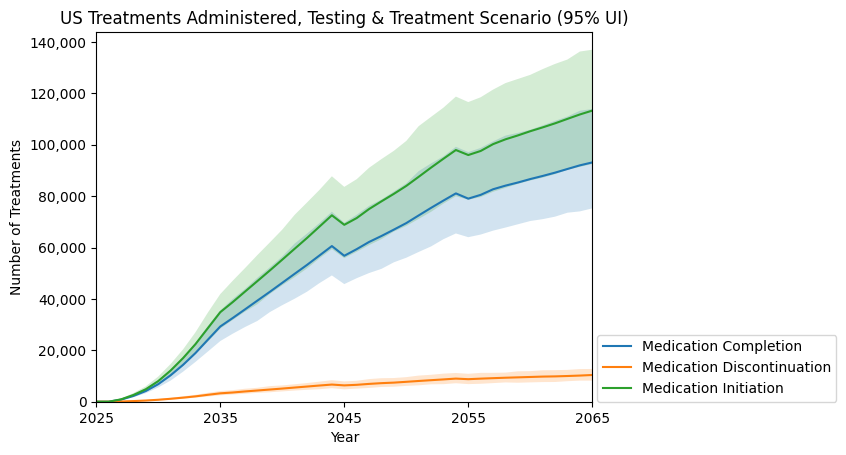

In [59]:
make_forecast_plot(
    filter_results(
        res3,
        ["Year"],
        location=["United States of America"],
        measure=[
            "Medication Initiation",
            "Medication Completion",
            "Medication Discontinuation",
        ],
        scenario=["BBBM Testing and Treatment"],
    ),
    "US Treatments Administered, Testing & Treatment Scenario (95% UI)",
    "Number of Treatments",
    strat_col="Measure",
)

## Plot annual averted DALYs over time

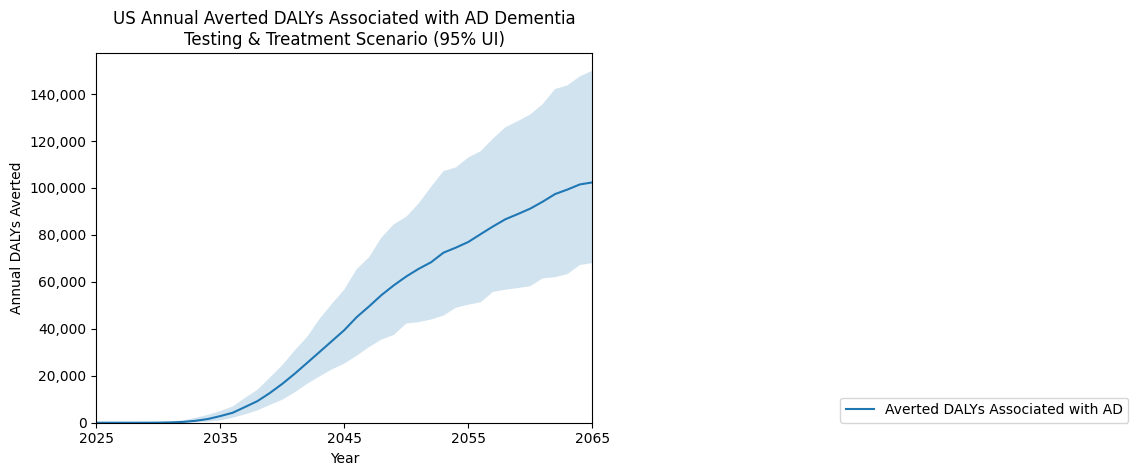

In [60]:
make_forecast_plot(
    filter_results(
        res3,
        ["Year"],
        location=["United States of America"],
        measure=[
            "Averted DALYs Associated with AD",
        ],
        scenario=["BBBM Testing and Treatment"],
    ),
    "US Annual Averted DALYs Associated with AD Dementia\nTesting & Treatment Scenario (95% UI)",
    "Annual DALYs Averted",
    strat_col="Measure",
    # min_year=2050,
    # max_year=2100,
)
plt.legend(loc=(1.5, 0))

## Plot annual averted deaths over time

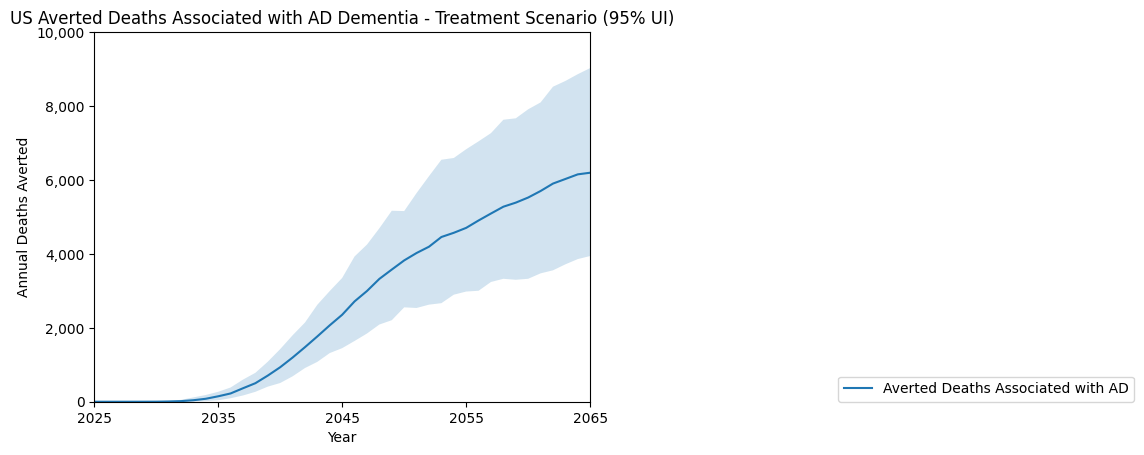

In [61]:
make_forecast_plot(
    filter_results(
        res3,
        ["Year"],
        location=["United States of America"],
        measure=[
            "Averted Deaths Associated with AD",
        ],
        scenario=["BBBM Testing and Treatment"],
    ),
    "US Averted Deaths Associated with AD Dementia - Treatment Scenario (95% UI)",
    "Annual Deaths Averted",
    "Measure",
)

# Explicitly set y-limit to match plot below
plt.ylim(0, 10_000)
# Move the legend over so it doesn't show up in screenshot
plt.legend(loc=(1.5, 0))
plt.show()

## Draw previous version of averted deaths for comparison

OLD VERSION! (v3, 12/2025)


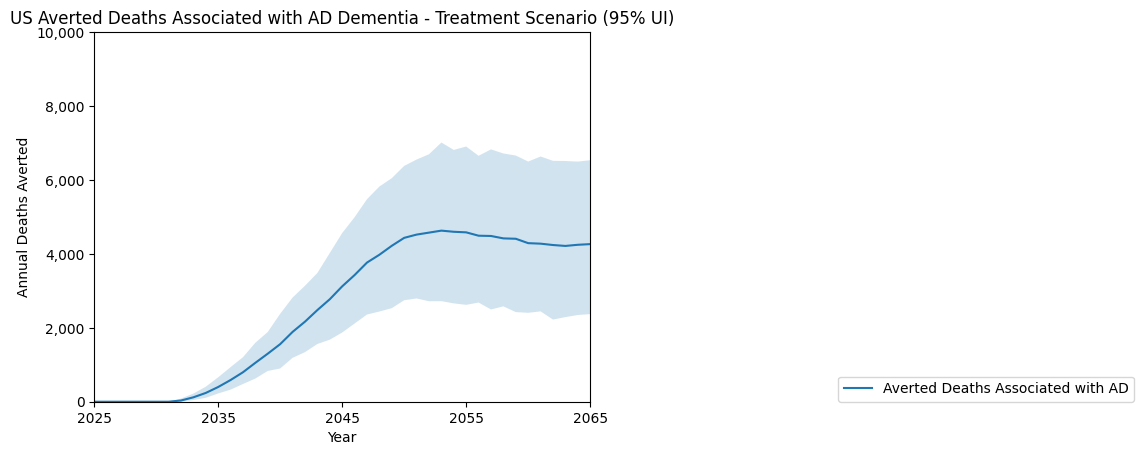

In [62]:
print("OLD VERSION! (v3, 12/2025)")

make_forecast_plot(
    filter_results(
        v3_res3,
        ["Year"],
        location=["United States of America"],
        measure=[
            "Averted Deaths Associated with AD",
        ],
        scenario=["BBBM Testing and Treatment"],
    ),
    "US Averted Deaths Associated with AD Dementia - Treatment Scenario (95% UI)",
    "Annual Deaths Averted",
    "Measure",
)
# NOTE: Set ylim higher to match new results for easier comparison
plt.ylim(0, 10_000)
plt.legend(loc=(1.5, 0))
plt.show()

## Averted DALYS and deaths by age group

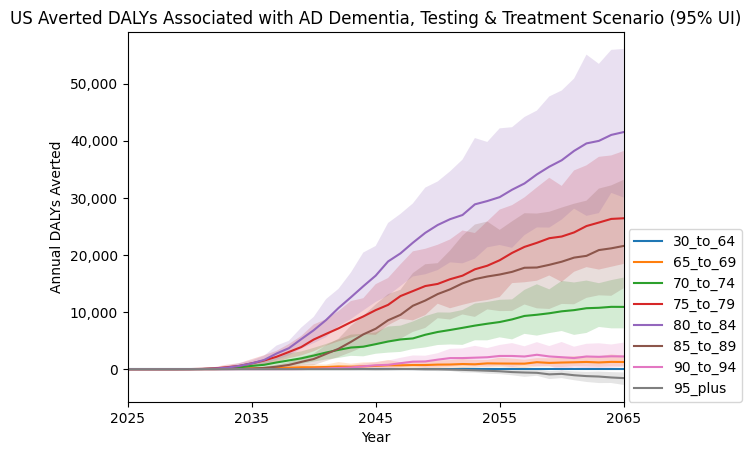

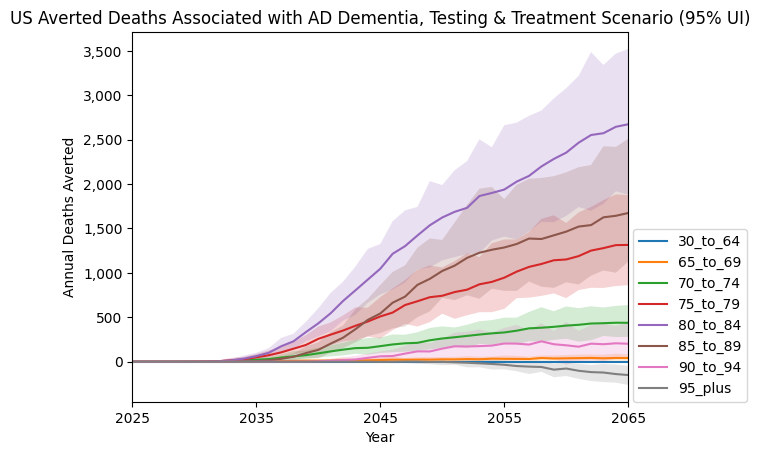

In [63]:
make_forecast_plot(
    filter_results(
        res3,
        ["Year", "Age"],
        location=["United States of America"],
        measure=["Averted DALYs Associated with AD"],
        scenario=["BBBM Testing and Treatment"],
    ),
    "US Averted DALYs Associated with AD Dementia, Testing & Treatment Scenario (95% UI)",
    "Annual DALYs Averted",
    "Age",
)
make_forecast_plot(
    filter_results(
        res3,
        ["Year", "Age"],
        location=["United States of America"],
        measure=["Averted Deaths Associated with AD"],
        scenario=["BBBM Testing and Treatment"],
    ),
    "US Averted Deaths Associated with AD Dementia, Testing & Treatment Scenario (95% UI)",
    "Annual Deaths Averted",
    "Age",
)

## Averted DALYs and deaths by location

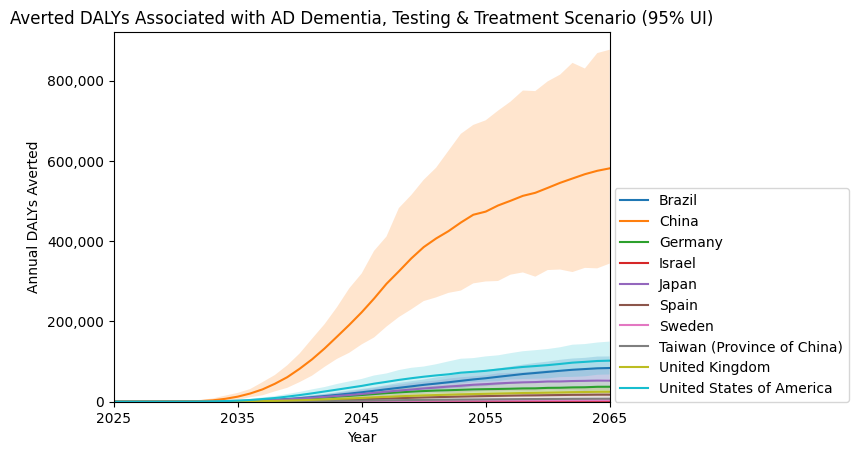

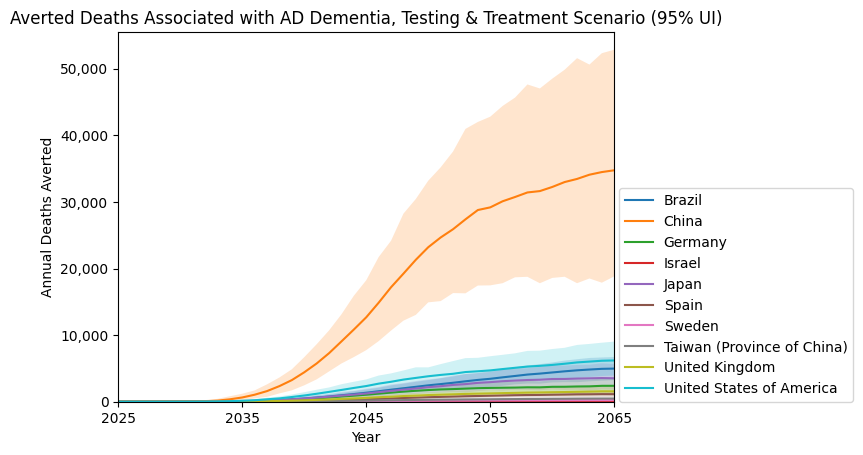

In [64]:
make_forecast_plot(
    filter_results(
        res3,
        ["Year", "Location"],
        measure=[
            "Averted DALYs Associated with AD",
        ],
        scenario=["BBBM Testing and Treatment"],
    ),
    "Averted DALYs Associated with AD Dementia, Testing & Treatment Scenario (95% UI)",
    "Annual DALYs Averted",
    "Location",
)
make_forecast_plot(
    filter_results(
        res3,
        ["Year", "Location"],
        measure=[
            "Averted Deaths Associated with AD",
        ],
        scenario=["BBBM Testing and Treatment"],
    ),
    "Averted Deaths Associated with AD Dementia, Testing & Treatment Scenario (95% UI)",
    "Annual Deaths Averted",
    "Location",
)

## Percent reduction in deaths and DALYs in US

In [65]:
def mean_lower_upper(df, method='groupby'):
    """Compute mean, lower, upper over draws"""
    def lower(x):
        return x.quantile(0.025)
    def upper(x):
        return x.quantile(0.975)

    # Find draw columns in the dataframe
    draw_cols = [c for c in df if c.startswith('draw_')]

    # If the dataframe doesn't contain draws, return it as is to just
    # use whatever mean, lower, upper are already there. This allows us
    # to use this function for both draw-level data and earlier data
    # that didn't contain draws.
    if not draw_cols:
        return df
    elif n_draws := len(draw_cols) < 25:
        print(f"Warning: DataFrame only contains {n_draws} draws")

    # Reset any columns that have been set to the index. All columns
    # have names, so the index will have a nontrivial .names array,
    # whereas the original index is unnamed, so its .names array is
    # [None]. This is a bit hacky, but it works as long as we don't name
    # the original index.
    if df.index.names[0] is not None:
        df = df.reset_index()

    # "index" columns will be the groupby columns
    index_cols = df.columns.difference(VAL_COLS + draw_cols).to_list()
    
    # Set index columns and keep only draw coumns (drop value columns)
    draws_df = df.set_index(index_cols)[draw_cols]

    # These two methods give the same result, but the 'groupby' method
    # seems to be about 4 times faster than the 'agg' method
    if method == 'groupby':
        result = draws_df.stack().groupby(index_cols).agg(['mean', lower, upper])
    elif method == 'agg':
        result = draws_df.agg(['mean', lower, upper], axis=1)
    else:
        raise ValueError(f"Unknown method: {method}. Must pass one of 'groupby' or 'agg'.")

    result = result.rename(
        columns={'mean': 'Mean', 'lower': '95% UI Lower', 'upper': '95% UI Upper'}
    )
    return result

# mean_lower_upper(averted)

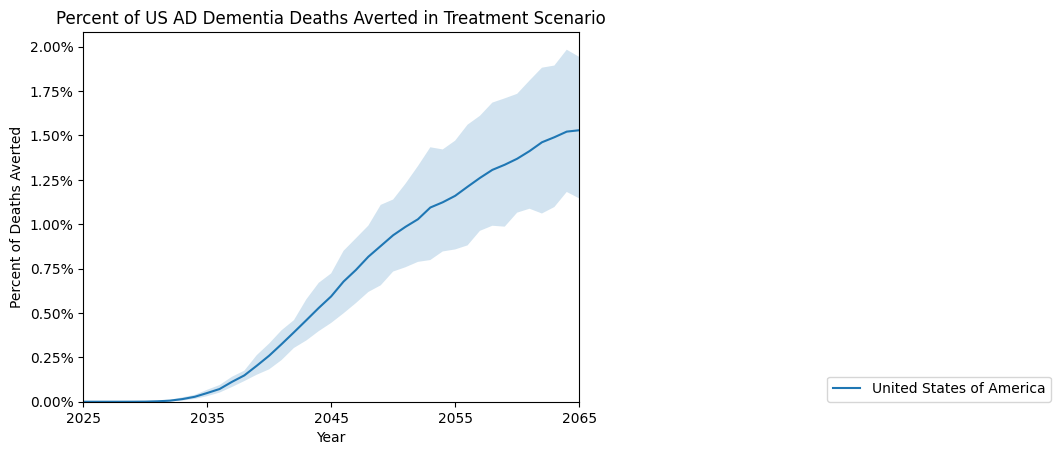

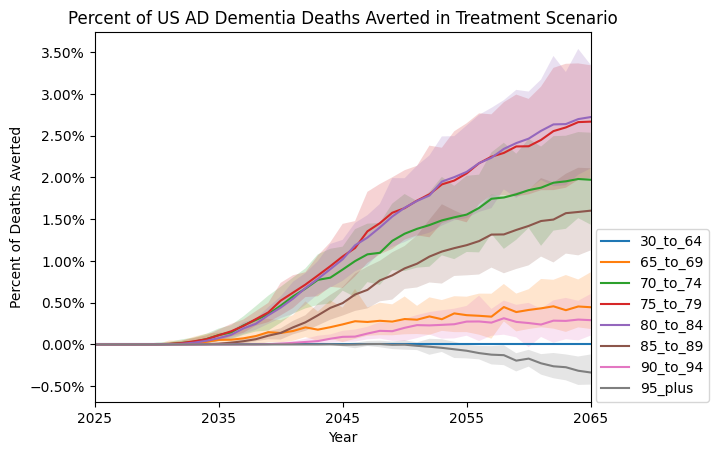

In [66]:
# Total percent deaths averted
averted = filter_results(
    res3,
    ["Year"],
    location=["United States of America"],
    measure=[
        "Averted Deaths Associated with AD",
    ],
    scenario=["BBBM Testing and Treatment"],
).drop(["Scenario", "Measure", "95% UI Lower", "95% UI Upper"], axis=1)
averted = averted.set_index(list(averted.columns.difference(["Mean"] + DRAW_COLS, sort=False)))
total = filter_results(
    res3,
    ["Year"],
    location=["United States of America"],
    measure=["Deaths Associated with AD"],
).drop(["Scenario", "Measure", "95% UI Lower", "95% UI Upper"], axis=1)
total = total.set_index(list(total.columns.difference(["Mean"] + DRAW_COLS, sort=False)))

fraction_averted = averted / total
if not fraction_averted.columns.intersection(DRAW_COLS).empty:
    fraction_averted = mean_lower_upper(fraction_averted)

make_forecast_plot(
    (fraction_averted).reset_index(),
    "Percent of US AD Dementia Deaths Averted in Treatment Scenario",
    "Percent of Deaths Averted",
    "Location",
    percent=True,
)
# Move legend over to avoid including it in screenshot
plt.legend(loc=(1.5, 0))

# Percent deaths averted, stratified by age
averted = filter_results(
    res3,
    ["Year", "Age"],
    location=["United States of America"],
    measure=[
        "Averted Deaths Associated with AD",
    ],
    scenario=["BBBM Testing and Treatment"],
).drop(["Scenario", "Measure", "95% UI Lower", "95% UI Upper"], axis=1)
averted = averted.set_index(list(averted.columns.difference(["Mean"] + DRAW_COLS, sort=False)))
total = filter_results(
    res3,
    ["Year", "Age"],
    location=["United States of America"],
    measure=["Deaths Associated with AD"],
).drop(["Scenario", "Measure", "95% UI Lower", "95% UI Upper"], axis=1)
total = total.set_index(list(total.columns.difference(["Mean"] + DRAW_COLS, sort=False)))

fraction_averted = averted / total
if not fraction_averted.columns.intersection(DRAW_COLS).empty:
    fraction_averted = mean_lower_upper(fraction_averted)

make_forecast_plot(
    (fraction_averted).reset_index(),
    "Percent of US AD Dementia Deaths Averted in Treatment Scenario",
    "Percent of Deaths Averted",
    strat_col="Age",
    percent=True,
)

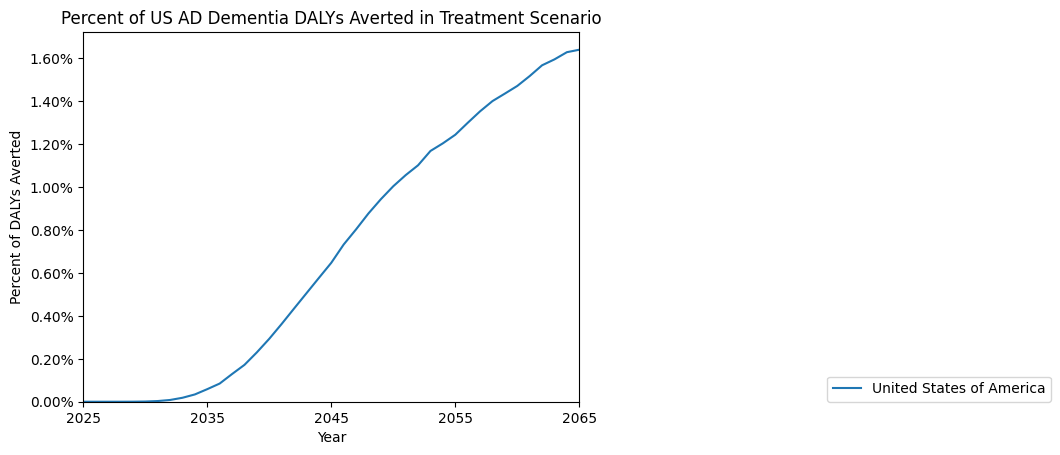

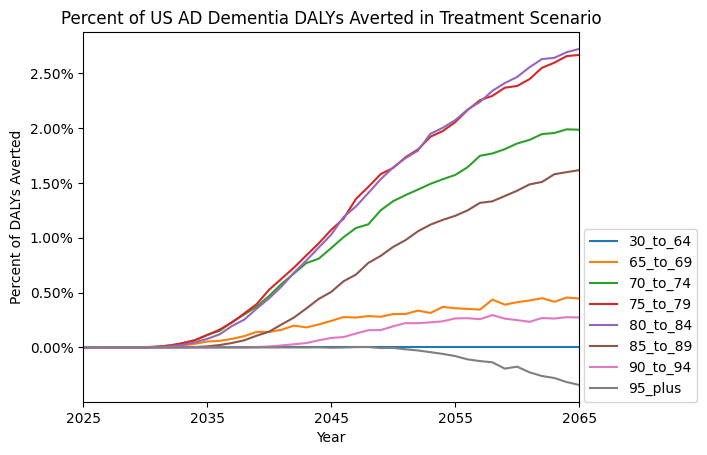

In [67]:
# Total percent DALYs averted
averted = filter_results(
    res3,
    ["Year"],
    location=["United States of America"],
    measure=[
        "Averted DALYs Associated with AD",
    ],
    scenario=["BBBM Testing and Treatment"],
).drop(["Scenario", "Measure", "95% UI Lower", "95% UI Upper"], axis=1)
averted = averted.set_index(list(averted.columns.difference(["Mean"] + DRAW_COLS, sort=False)))
total = filter_results(
    res3,
    ["Year"],
    location=["United States of America"],
    measure=["DALYs Associated with AD"],
).drop(["Scenario", "Measure", "95% UI Lower", "95% UI Upper"], axis=1)
total = total.set_index(list(total.columns.difference(["Mean"] + DRAW_COLS, sort=False)))
make_forecast_plot(
    (averted / total).reset_index(),
    "Percent of US AD Dementia DALYs Averted in Treatment Scenario",
    "Percent of DALYs Averted",
    "Location",
    percent=True,
)
# Move legend over to avoid including it in screenshot
plt.legend(loc=(1.5, 0))

# Percent DALYs averted, stratified by age
averted = filter_results(
    res3,
    ["Year", "Age"],
    location=["United States of America"],
    measure=[
        "Averted DALYs Associated with AD",
    ],
    scenario=["BBBM Testing and Treatment"],
).drop(["Scenario", "Measure", "95% UI Lower", "95% UI Upper"], axis=1)
averted = averted.set_index(list(averted.columns.difference(["Mean"] + DRAW_COLS, sort=False)))
total = filter_results(
    res3,
    ["Year", "Age"],
    location=["United States of America"],
    measure=["DALYs Associated with AD"],
).drop(["Scenario", "Measure", "95% UI Lower", "95% UI Upper"], axis=1)
total = total.set_index(list(total.columns.difference(["Mean"] + DRAW_COLS, sort=False)))
make_forecast_plot(
    (averted / total).reset_index(),
    "Percent of US AD Dementia DALYs Averted in Treatment Scenario",
    "Percent of DALYs Averted",
    strat_col="Age",
    percent=True,
)

## Changes in AD prevalence

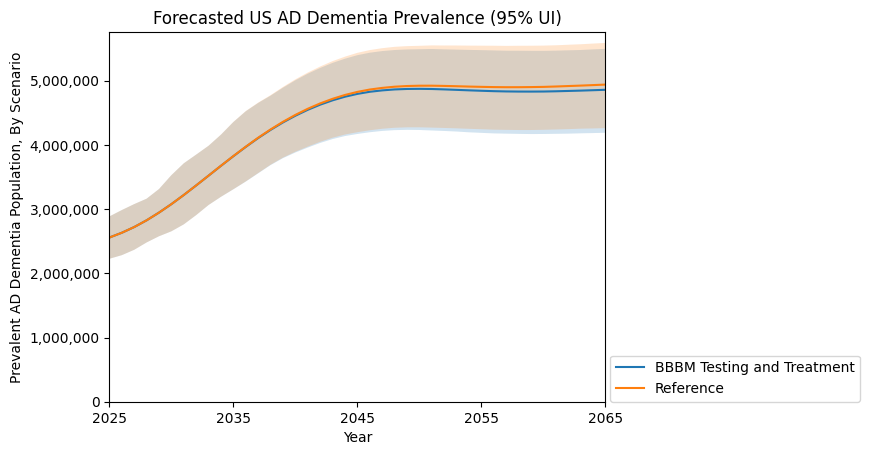

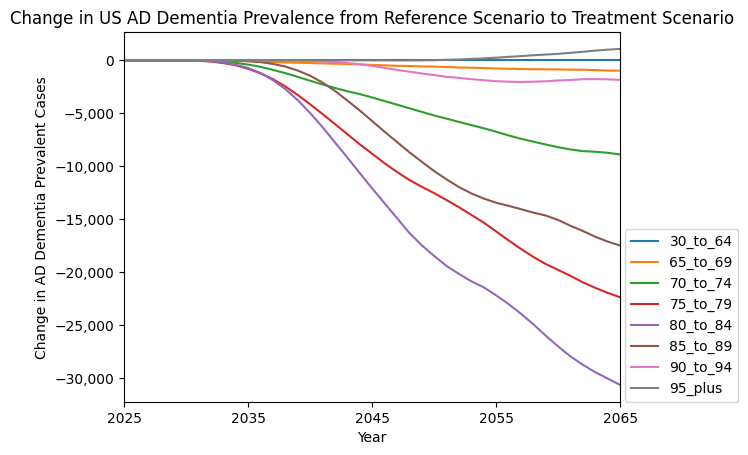

In [68]:
make_forecast_plot(
    filter_results(
        res,
        ["Year", "Scenario"],
        location=["United States of America"],
        stage=["AD Dementia"],
        measure=["Prevalence"],
        scenario=["Reference", "BBBM Testing and Treatment"],
    ),
    "Forecasted US AD Dementia Prevalence (95% UI)",
    "Prevalent AD Dementia Population, By Scenario",
    "Scenario",
)
change = filter_results(
    res,
    ["Year", "Age", "Scenario"],
    age=AGES,
    location=["United States of America"],
    stage=["AD Dementia"],
    measure=["Prevalence"],
    scenario=["Reference", "BBBM Testing and Treatment"],
)
change = change.set_index(
    list(change.columns.difference(["Mean", "95% UI Lower", "95% UI Upper"] + DRAW_COLS))
).unstack("Scenario")

for x in ["Mean", "95% UI Lower", "95% UI Upper"]:
    change[(x, "Difference")] = (
        change[(x, "BBBM Testing and Treatment")] - change[(x, "Reference")]
    )
    change = change.drop(
        [(x, "BBBM Testing and Treatment"), (x, "Reference")],
        axis=1,
    )
change = (
    change.droplevel("Scenario", axis=1)
    .reset_index()
    .drop(["95% UI Lower", "95% UI Upper"], axis=1)
)
make_forecast_plot(
    change,
    "Change in US AD Dementia Prevalence from Reference Scenario to Treatment Scenario",
    "Change in AD Dementia Prevalent Cases",
    "Age",
)
change = change.set_index(list(change.columns.difference(["Mean"] + DRAW_COLS, sort=False)))

,Age,Disease Stage,Location,Measure,Metric,Year,Mean,draw_1,draw_1,draw_103,...,draw_50,draw_50,draw_6,draw_6,draw_63,draw_63,draw_69,draw_69,draw_7,draw_7
0,30_to_64,AD Dementia,United States of America,Prevalence,Number,2025,0.000000e+00,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
1,30_to_64,AD Dementia,United States of America,Prevalence,Number,2026,0.000000e+00,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
2,30_to_64,AD Dementia,United States of America,Prevalence,Number,2027,0.000000e+00,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
3,30_to_64,AD Dementia,United States of America,Prevalence,Number,2028,0.000000e+00,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
4,30_to_64,AD Dementia,United States of America,Prevalence,Number,2029,1.872277e-16,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603,95_plus,AD Dementia,United States of America,Prevalence,Number,2096,7.987962e-03,1.007801,1.0,1.007364,...,1.008587,1.0,1.006746,1.0,1.009046,1.0,1.006647,1.0,1.007766,1.0
604,95_plus,AD Dementia,United States of America,Prevalence,Number,2097,7.920122e-03,1.007244,1.0,1.007408,...,1.008141,1.0,1.006908,1.0,1.008759,1.0,1.006738,1.0,1.008129,1.0
605,95_plus,AD Dementia,United States of America,Prevalence,Number,2098,8.058858e-03,1.007545,1.0,1.007475,...,1.008371,1.0,1.007097,1.0,1.009238,1.0,1.006466,1.0,1.008054,1.0
606,95_plus,AD Dementia,United States of America,Prevalence,Number,2099,8.234229e-03,1.007731,1.0,1.007128,...,1.008801,1.0,1.007261,1.0,1.010231,1.0,1.006581,1.0,1.008074,1.0


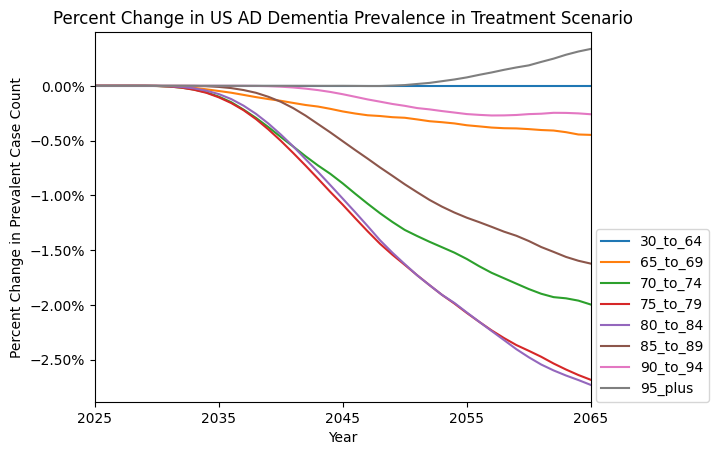

In [69]:
prev = filter_results(
    res,
    ["Year", "Age"],
    age=AGES,
    location=["United States of America"],
    stage=["AD Dementia"],
    measure=["Prevalence"],
).drop(["Scenario", "95% UI Lower", "95% UI Upper"], axis=1)
prev = prev.set_index(list(prev.columns.difference(["Mean"] + DRAW_COLS, sort=False)))
# change = change.set_index(list(change.columns.difference(["Mean"], sort=False)))
display((change / prev).reset_index())
make_forecast_plot(
    (change / prev).reset_index(),
    "Percent Change in US AD Dementia Prevalence in Treatment Scenario",
    "Percent Change in Prevalent Case Count",
    "Age",
    percent=True,
)

,Age,Disease Stage,Location,Measure,Metric,Year,Mean,draw_1,draw_1,draw_103,...,draw_50,draw_50,draw_6,draw_6,draw_63,draw_63,draw_69,draw_69,draw_7,draw_7
0,30_to_64,AD Dementia,Brazil,Prevalence,Number,2025,0.000000e+00,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
1,30_to_64,AD Dementia,Brazil,Prevalence,Number,2026,1.434630e-16,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
2,30_to_64,AD Dementia,Brazil,Prevalence,Number,2027,0.000000e+00,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
3,30_to_64,AD Dementia,Brazil,Prevalence,Number,2028,0.000000e+00,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
4,30_to_64,AD Dementia,Brazil,Prevalence,Number,2029,0.000000e+00,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603,95_plus,AD Dementia,Brazil,Prevalence,Number,2096,9.986565e-03,1.009459,1.0,1.008869,...,1.010511,1.0,1.008206,1.0,1.011449,1.0,1.007861,1.0,1.009824,1.0
604,95_plus,AD Dementia,Brazil,Prevalence,Number,2097,1.006879e-02,1.009455,1.0,1.008794,...,1.010490,1.0,1.008459,1.0,1.011386,1.0,1.008032,1.0,1.009909,1.0
605,95_plus,AD Dementia,Brazil,Prevalence,Number,2098,1.020005e-02,1.009240,1.0,1.009424,...,1.010665,1.0,1.008404,1.0,1.011603,1.0,1.008053,1.0,1.010082,1.0
606,95_plus,AD Dementia,Brazil,Prevalence,Number,2099,1.038644e-02,1.009580,1.0,1.009469,...,1.011001,1.0,1.008738,1.0,1.012185,1.0,1.008255,1.0,1.010151,1.0


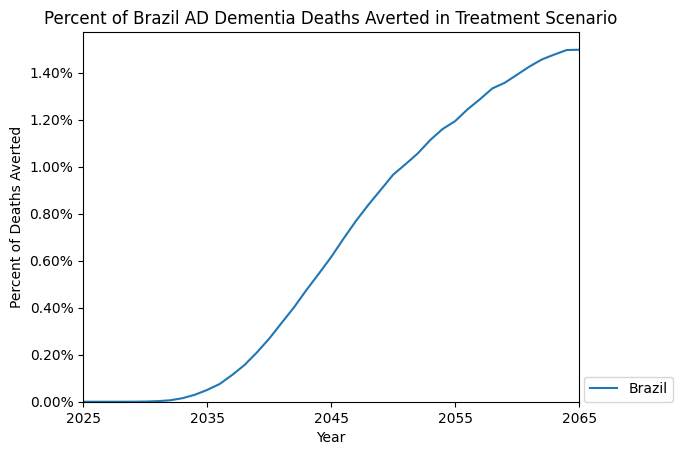

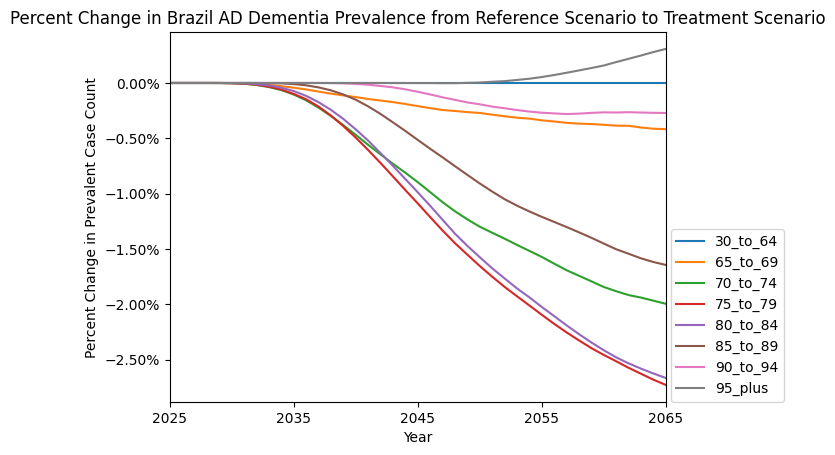

In [70]:
averted = filter_results(
    res3,
    ["Year"],
    location=["Brazil"],
    measure=[
        "Averted Deaths Associated with AD",
    ],
    scenario=["BBBM Testing and Treatment"],
).drop(["Scenario", "Measure", "95% UI Lower", "95% UI Upper"], axis=1)
averted = averted.set_index(list(averted.columns.difference(["Mean"] + DRAW_COLS, sort=False)))
total = filter_results(
    res,
    ["Year"],
    location=["Brazil"],
    measure=["Deaths Associated with AD"],
).drop(["Scenario", "Measure", "95% UI Lower", "95% UI Upper"], axis=1)
total = total.set_index(list(total.columns.difference(["Mean"] + DRAW_COLS, sort=False)))
make_forecast_plot(
    (averted / total).reset_index(),
    "Percent of Brazil AD Dementia Deaths Averted in Treatment Scenario",
    "Percent of Deaths Averted",
    "Location",
    percent=True,
)
prev = filter_results(
    res,
    ["Year", "Age"],
    location=["Brazil"],
    stage=["AD Dementia"],
    measure=["Prevalence"],
).drop(["Scenario", "95% UI Lower", "95% UI Upper"], axis=1)
prev = prev.set_index(list(prev.columns.difference(["Mean"] + DRAW_COLS, sort=False)))

change = filter_results(
    res,
    ["Year", "Age", "Scenario"],
    location=["Brazil"],
    stage=["AD Dementia"],
    measure=["Prevalence"],
    scenario=["Reference", "BBBM Testing and Treatment"],
)
change = change.set_index(
    list(change.columns.difference(["Mean", "95% UI Lower", "95% UI Upper"] + DRAW_COLS))
).unstack("Scenario")

for x in ["Mean", "95% UI Lower", "95% UI Upper"]:
    change[(x, "Difference")] = (
        change[(x, "BBBM Testing and Treatment")] - change[(x, "Reference")]
    )
    change = change.drop(
        [(x, "BBBM Testing and Treatment"), (x, "Reference")],
        axis=1,
    )
change = (
    change.droplevel("Scenario", axis=1)
    .reset_index()
    .drop(["95% UI Lower", "95% UI Upper"], axis=1)
)
change = change.set_index(list(change.columns.difference(["Mean"] + DRAW_COLS, sort=False)))

display((change / prev).reset_index())
make_forecast_plot(
    (change / prev).reset_index(),
    "Percent Change in Brazil AD Dementia Prevalence from Reference Scenario to Treatment Scenario",
    "Percent Change in Prevalent Case Count",
    "Age",
    percent=True,
)

,Age,Disease Stage,Location,Measure,Metric,Year,Mean,draw_1,draw_1,draw_103,...,draw_50,draw_50,draw_6,draw_6,draw_63,draw_63,draw_69,draw_69,draw_7,draw_7
0,30_to_64,AD Dementia,Japan,Prevalence,Number,2025,-1.524106e-16,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
1,30_to_64,AD Dementia,Japan,Prevalence,Number,2026,0.000000e+00,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
2,30_to_64,AD Dementia,Japan,Prevalence,Number,2027,0.000000e+00,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
3,30_to_64,AD Dementia,Japan,Prevalence,Number,2028,0.000000e+00,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
4,30_to_64,AD Dementia,Japan,Prevalence,Number,2029,0.000000e+00,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603,95_plus,AD Dementia,Japan,Prevalence,Number,2096,1.029419e-02,1.010687,1.0,1.011713,...,1.010445,1.0,1.008265,1.0,1.011514,1.0,1.008841,1.0,1.009148,1.0
604,95_plus,AD Dementia,Japan,Prevalence,Number,2097,1.044256e-02,1.010972,1.0,1.011353,...,1.010544,1.0,1.008438,1.0,1.011520,1.0,1.008857,1.0,1.009264,1.0
605,95_plus,AD Dementia,Japan,Prevalence,Number,2098,1.047426e-02,1.010957,1.0,1.011469,...,1.010575,1.0,1.008140,1.0,1.012117,1.0,1.008623,1.0,1.009595,1.0
606,95_plus,AD Dementia,Japan,Prevalence,Number,2099,1.058598e-02,1.011136,1.0,1.011521,...,1.011642,1.0,1.008471,1.0,1.012457,1.0,1.008831,1.0,1.009540,1.0


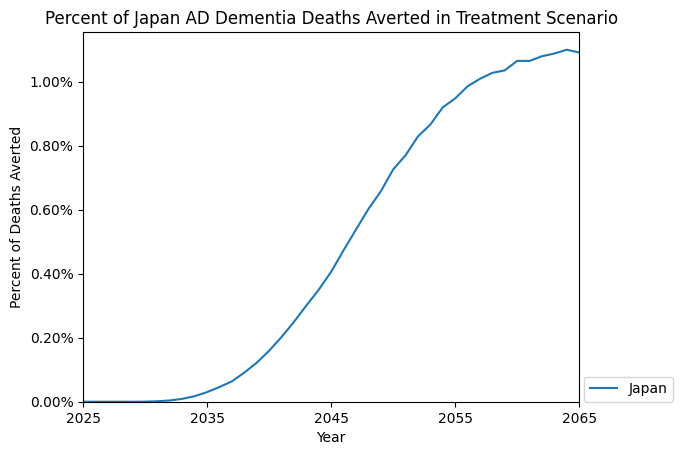

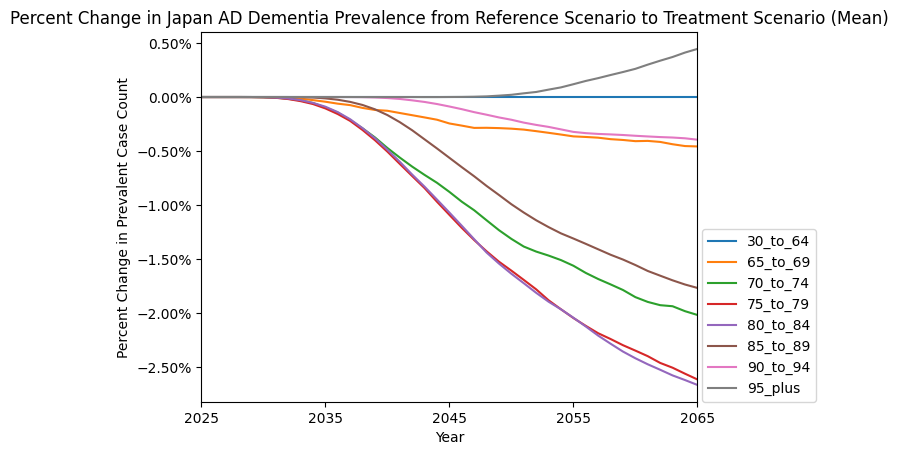

In [71]:
averted = filter_results(
    res3,
    ["Year"],
    location=["Japan"],
    measure=[
        "Averted Deaths Associated with AD",
    ],
    scenario=["BBBM Testing and Treatment"],
).drop(["Scenario", "Measure", "95% UI Lower", "95% UI Upper"], axis=1)
averted = averted.set_index(list(averted.columns.difference(["Mean"] + DRAW_COLS, sort=False)))
total = filter_results(
    res,
    ["Year"],
    location=["Japan"],
    measure=["Deaths Associated with AD"],
).drop(["Scenario", "Measure", "95% UI Lower", "95% UI Upper"], axis=1)
total = total.set_index(list(total.columns.difference(["Mean"] + DRAW_COLS, sort=False)))
make_forecast_plot(
    (averted / total).reset_index(),
    "Percent of Japan AD Dementia Deaths Averted in Treatment Scenario",
    "Percent of Deaths Averted",
    "Location",
    percent=True,
)
prev = filter_results(
    res,
    ["Year", "Age"],
    location=["Japan"],
    stage=["AD Dementia"],
    measure=["Prevalence"],
).drop(["Scenario", "95% UI Lower", "95% UI Upper"], axis=1)
prev = prev.set_index(list(prev.columns.difference(["Mean"] + DRAW_COLS, sort=False)))

change = filter_results(
    res,
    ["Year", "Age", "Scenario"],
    location=["Japan"],
    stage=["AD Dementia"],
    measure=["Prevalence"],
    scenario=["Reference", "BBBM Testing and Treatment"],
)
change = change.set_index(
    list(change.columns.difference(["Mean", "95% UI Lower", "95% UI Upper"] + DRAW_COLS))
).unstack("Scenario")

for x in ["Mean", "95% UI Lower", "95% UI Upper"]:
    change[(x, "Difference")] = (
        change[(x, "BBBM Testing and Treatment")] - change[(x, "Reference")]
    )
    change = change.drop(
        [(x, "BBBM Testing and Treatment"), (x, "Reference")],
        axis=1,
    )
change = (
    change.droplevel("Scenario", axis=1)
    .reset_index()
    .drop(["95% UI Lower", "95% UI Upper"], axis=1)
)
change = change.set_index(list(change.columns.difference(["Mean"] + DRAW_COLS, sort=False)))

display((change / prev).reset_index())
make_forecast_plot(
    (change / prev).reset_index(),
    "Percent Change in Japan AD Dementia Prevalence from Reference Scenario to Treatment Scenario (Mean)",
    "Percent Change in Prevalent Case Count",
    "Age",
    percent=True,
)

# Calculate increased time in preclinical

I want to compute (change in person-time in each dementia state) / (number of treatments). Looks like that will require `res` and `res3`.

In [72]:
display(res["Measure"].unique())
display(res2["Measure"].unique())
display(res3["Measure"].unique())

array(['Prevalence', 'Change in Prevalence from Reference', 'Incidence',
       'Deaths Associated with AD', 'Averted Deaths Associated with AD'],
      dtype=object)

array(['CSF Tests', 'PET Tests', 'Averted CSF Tests', 'Averted PET Tests',
       'BBBM Tests', 'Positive BBBM Tests'], dtype=object)

array(['DALYs Associated with AD', 'Averted DALYs Associated with AD',
       'Deaths Associated with AD', 'Averted Deaths Associated with AD',
       'Medication Discontinuation', 'Medication Completion',
       'Medication Initiation'], dtype=object)

In [73]:
UI_COLS

['95% UI Lower', '95% UI Upper']

In [74]:
res.head(1)

,Year,Location,Age,Sex,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
0,2025,Brazil,65_to_69,Female,Preclinical AD,Reference,Prevalence,Number,187036.882381,162433.461894,...,196009.840992,193474.100426,182652.646418,182955.906262,173085.356946,185232.393837,185910.998505,201850.237628,184571.056742,163842.155638


In [75]:
def value(df, include_mean=True, include_ui=True, include_draws=True):
    """Sets all non-value columns to the index, and leaves the specified
    value columns as columns. The "value" columns are the mean, UI, and
    draw columns, if they exist.
    """
    draw_cols = [c for c in df if c.startswith('draw_')]
    index_cols = df.columns.difference(VAL_COLS + draw_cols).to_list()
    mean_col = ['Mean'] if include_mean else []
    ui_cols = UI_COLS if include_ui else []
    if not include_draws:
        draw_cols = []
    value_df = df.set_index(index_cols)[mean_col + ui_cols + draw_cols]
    return value_df

In [81]:
treatment_initiations

,Year,Location,Age,Sex,Scenario,Measure,Metric,Mean,95% UI Lower,95% UI Upper,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
20,2025,United States of America,65_plus,Both,BBBM Testing and Treatment,Medication Initiation,Number,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
46,2026,United States of America,65_plus,Both,BBBM Testing and Treatment,Medication Initiation,Number,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
72,2027,United States of America,65_plus,Both,BBBM Testing and Treatment,Medication Initiation,Number,926.877483,819.336469,1018.372562,...,1012.138525,979.717517,976.418196,930.442643,1014.491772,878.657927,869.411653,1007.045897,921.402432,938.319297
98,2028,United States of America,65_plus,Both,BBBM Testing and Treatment,Medication Initiation,Number,2629.765485,2291.698779,2875.196263,...,2791.713718,2857.504868,2867.984696,2686.175552,2588.239139,2688.804849,2699.616114,2832.489928,2688.502612,2331.384155
124,2029,United States of America,65_plus,Both,BBBM Testing and Treatment,Medication Initiation,Number,4872.806747,4313.756158,5413.937948,...,5073.488449,5291.116287,5589.118114,4843.318800,4876.971194,4815.844528,4588.444535,5215.080465,4991.766276,4877.977808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1866,2096,United States of America,65_plus,Both,BBBM Testing and Treatment,Medication Initiation,Number,163862.204217,147444.148533,182698.233245,...,174061.900114,180559.972703,183975.711770,163677.462687,168380.450410,166534.633519,158052.011122,171735.516165,166084.904994,160452.568604
1892,2097,United States of America,65_plus,Both,BBBM Testing and Treatment,Medication Initiation,Number,165919.412309,149118.852612,184523.485061,...,176478.849447,182751.359507,186466.675151,166353.028663,169359.860105,169490.354486,161115.836825,174366.631738,168381.898013,164733.516527
1918,2098,United States of America,65_plus,Both,BBBM Testing and Treatment,Medication Initiation,Number,167408.407952,151667.805667,186338.312431,...,175687.495215,183534.043143,186956.848146,167451.147499,169649.084265,170867.061708,161862.188233,176651.969620,171974.139202,164268.243054
1944,2099,United States of America,65_plus,Both,BBBM Testing and Treatment,Medication Initiation,Number,169352.634863,152987.638159,190032.597969,...,180175.293020,188974.786701,191115.136848,168454.327387,172073.908693,173961.356629,164031.733315,178178.827403,171347.572063,164953.042262


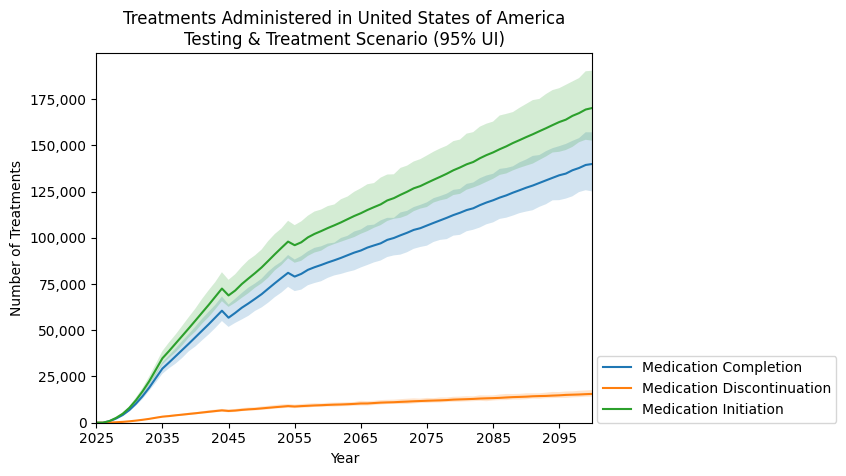

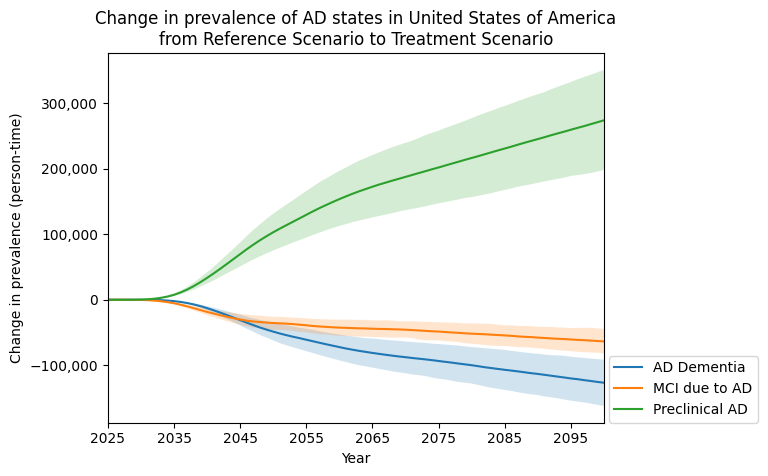

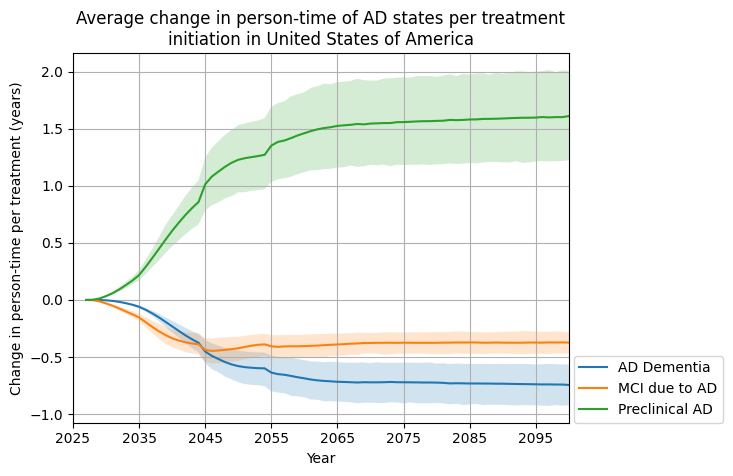

In [119]:
location = 'United States of America'

change_in_prev = filter_results(
    res,
    ["Year", "Disease Stage"],
    location=[location],
    # NOTE: If we don't specify the aggregate age group and sex, it will
    # aggregate by default, but the uncertainty intervals won't be
    # correct -- they'll be slightly wider than they should be
    age=['65_plus'],
    sex=['Both'],
    scenario=["BBBM Testing and Treatment"],
    measure=["Change in Prevalence from Reference"],
    metric=["Number"],
)

treatments = filter_results(
    res3,
    ["Year"],
    location=[location],
    age=['65_plus'],
    sex=['Both'],
    measure=[
        "Medication Initiation",
        "Medication Completion",
        "Medication Discontinuation",
    ],
    scenario=["BBBM Testing and Treatment"],
)

# We want to divide change in person-time by the number of treatment initiations
treatment_initiations = treatments.query("Measure == 'Medication Initiation'")

# Drop the "Measure" column from at least one of the dataframes since
# the measures don't match -- otherwise, the indexes won't align
# properly when dividing
change_in_pt_per_treatment = value(change_in_prev) / value(
    treatment_initiations
    .drop(columns='Measure')
)

# Set max_year = 2100 in these plots to see full time trend
make_forecast_plot(
    treatments,
    f"Treatments Administered in {location}\nTesting & Treatment Scenario (95% UI)",
    "Number of Treatments",
    strat_col="Measure",
    max_year=2100,
)

make_forecast_plot(
    change_in_prev,
    f"Change in prevalence of AD states in {location}\nfrom Reference Scenario to Treatment Scenario",
    "Change in prevalence (person-time)",
    "Disease Stage",
    max_year=2100,
)

make_forecast_plot(
    # Compute mean, lower, upper of draws, assuming they exist
    mean_lower_upper(change_in_pt_per_treatment).reset_index(),
    f"Average change in person-time of AD states per treatment\ninitiation in {location}",
    "Change in person-time per treatment (years)",
    "Disease Stage",
    max_year=2100,
)
plt.grid(True)

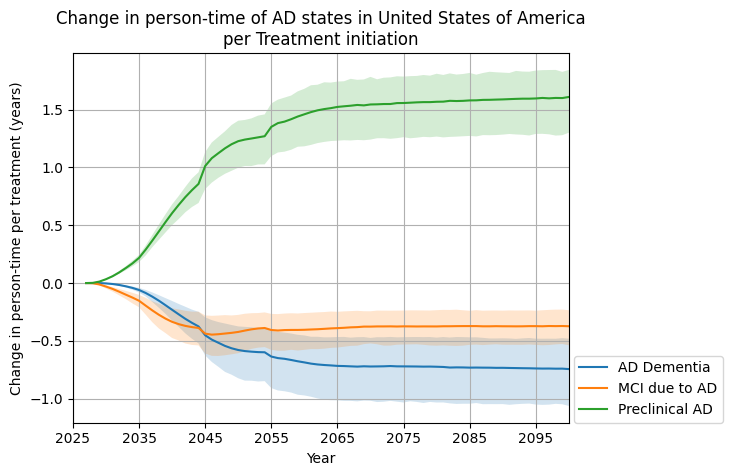

In [118]:
# Compare this plot with the one above: The uncertainty intervals should
# be different (and wrong) in the plot below, since we're incorrectly
# dividing the upper and lower bounds, whereas in the plot above,
# divided draw, which propagates the uncertainty correctly. The means
# should also be different, since in general the mean of a ratio is not
# the ratio of the means, but they appear close enough to be
# indistinguishable by eye.
make_forecast_plot(
    change_in_pt_per_treatment.reset_index(),
    f"Change in person-time of AD states in {location}\nper Treatment initiation",
    "Change in person-time per treatment (years)",
    "Disease Stage",
    max_year=2100,
)
ax = plt.gca()
ax.grid(True)

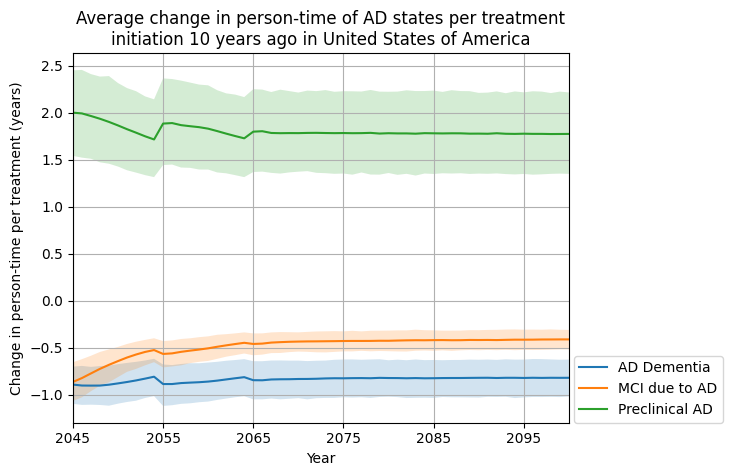

In [ ]:
# See what happens if we divide by treatments in a previous year,
# since the effect of treatment should be delayed by some amount

delay = 10 # years

# Drop the "Measure" column from at least one of the dataframes since
# the measures don't match -- otherwise, the indexes won't align
# properly when dividing
change_in_pt_per_earlier_treatment = (
    value(change_in_prev) / value(
        treatment_initiations
        .drop(columns='Measure')
        .assign(Year=lambda df: df['Year'].map(lambda y: y+delay))
    )
# Remove all infinities and NaNs to avoid subtraction error when
# interpolating in quantile function in mean_lower_upper
).replace({np.inf: np.nan, -np.inf: np.nan}).dropna()

make_forecast_plot(
    # Compute mean, lower, upper of draws, assuming they exist
    mean_lower_upper(change_in_pt_per_earlier_treatment).reset_index(),
    f"Average change in person-time of AD states per treatment\ninitiation {delay} years ago in {location}",
    "Change in person-time per treatment (years)",
    "Disease Stage",
    min_year=2045,
    max_year=2100,
)
plt.grid(True)

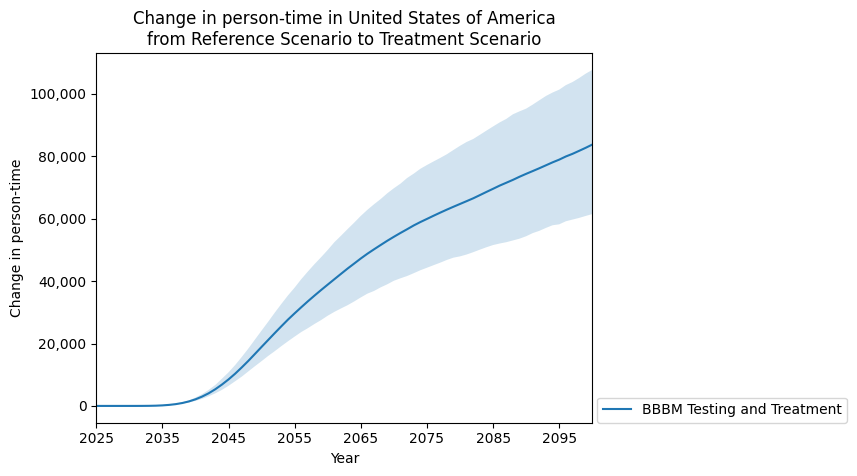

In [78]:

make_forecast_plot(
    mean_lower_upper(filter_results(
        res,
        ["Year"],
        location=[location],
        age=['65_plus'],
        sex=['Both'],
        scenario=["BBBM Testing and Treatment"],
        measure=["Change in Prevalence from Reference"],
        metric=["Number"],
    )).reset_index(),
    f"Change in person-time in {location}\nfrom Reference Scenario to Treatment Scenario",
    "Change in person-time",
    "Scenario",
    max_year=2100,
)

In [79]:
change_in_pt_per_treatment.drop(columns=[])

Mean  \
Age     Location                 Metric Scenario                   Sex  Year Disease Stage  Measure                                         
65_plus United States of America Number BBBM Testing and Treatment Both 2025 AD Dementia    Change in Prevalence from Reference       NaN   
                                                                             MCI due to AD  Change in Prevalence from Reference       NaN   
                                                                             Preclinical AD Change in Prevalence from Reference       NaN   
                                                                        2026 AD Dementia    Change in Prevalence from Reference       NaN   
                                                                             MCI due to AD  Change in Prevalence from Reference       NaN   
...                                                                                                                                   ...   
                                                                        2099 MCI due to AD  Change in Prevalence from Reference -0.371727   
                                                                             Preclinical AD Change in Prevalence from Reference  1.600933   
                                                                        2100 AD Dementia    Change in Prevalence from Reference -0.744421   
                                                                             MCI due to AD  Change in Prevalence from Reference -0.373708   
                                                                             Preclinical AD Change in Prevalence from Reference  1.610435   

                                                                                                                                 95% UI Lower  \
Age     Location                 Metric Scenario                   Sex  Year Disease Stage  Measure                                             
65_plus United States of America Number BBBM Testing and Treatment Both 2025 AD Dementia    Change in Prevalence from Reference           NaN   
                                                                             MCI due to AD  Change in Prevalence from Reference           NaN   
                                                                             Preclinical AD Change in Prevalence from Reference           NaN   
                                                                        2026 AD Dementia    Change in Prevalence from Reference           NaN   
                                                                             MCI due to AD  Change in Prevalence from Reference           NaN   
...                                                                                                                                       ...   
                                                                        2099 MCI due to AD  Change in Prevalence from Reference     -0.527633   
                                                                             Preclinical AD Change in Prevalence from Reference      1.279408   
                                                                        2100 AD Dementia    Change in Prevalence from Reference     -1.063238   
                                                                             MCI due to AD  Change in Prevalence from Reference     -0.538242   
                                                                             Preclinical AD Change in Prevalence from Reference      1.301382   

                                                                                                                                 95% UI Upper  \
Age     Location                 Metric Scenario                   Sex  Year Disease Stage  Measure                                             
65_plus United States of America Number BBBM Testing and Treatment Both 2025 AD Dementia    Change in Prevalence from Refer

In [80]:
make_forecast_plot(
    (filter_results(
        change_in_pt_per_treatment.reset_index(),
        ["Year"],
        location=[location],
        # age=['65_plus'], # unneeded, aggregates by default
        # sex=['Both'], # unneeded, aggregates by default
        scenario=["BBBM Testing and Treatment"],
        measure=["Change in Prevalence from Reference"],
        metric=["Number"],
    )),
    f"Change in person-time in {location}\nfrom Reference Scenario to Treatment Scenario",
    "Change in person-time",
    "Scenario",
    max_year=2100,
)

ValueError: zero-size array to reduction operation minimum which has no identity

<Figure size 640x480 with 0 Axes>

In [ ]:
change_in_pt_per_treatment

Mean  \
Age     Location                 Metric Scenario                   Sex  Year Disease Stage  Measure                                         
65_plus United States of America Number BBBM Testing and Treatment Both 2025 AD Dementia    Change in Prevalence from Reference       NaN   
                                                                             MCI due to AD  Change in Prevalence from Reference       NaN   
                                                                             Preclinical AD Change in Prevalence from Reference       NaN   
                                                                        2026 AD Dementia    Change in Prevalence from Reference       NaN   
                                                                             MCI due to AD  Change in Prevalence from Reference       NaN   
...                                                                                                                                   ...   
                                                                        2099 MCI due to AD  Change in Prevalence from Reference -0.371727   
                                                                             Preclinical AD Change in Prevalence from Reference  1.600933   
                                                                        2100 AD Dementia    Change in Prevalence from Reference -0.744421   
                                                                             MCI due to AD  Change in Prevalence from Reference -0.373708   
                                                                             Preclinical AD Change in Prevalence from Reference  1.610435   

                                                                                                                                 95% UI Lower  \
Age     Location                 Metric Scenario                   Sex  Year Disease Stage  Measure                                             
65_plus United States of America Number BBBM Testing and Treatment Both 2025 AD Dementia    Change in Prevalence from Reference           NaN   
                                                                             MCI due to AD  Change in Prevalence from Reference           NaN   
                                                                             Preclinical AD Change in Prevalence from Reference           NaN   
                                                                        2026 AD Dementia    Change in Prevalence from Reference           NaN   
                                                                             MCI due to AD  Change in Prevalence from Reference           NaN   
...                                                                                                                                       ...   
                                                                        2099 MCI due to AD  Change in Prevalence from Reference     -0.527633   
                                                                             Preclinical AD Change in Prevalence from Reference      1.279408   
                                                                        2100 AD Dementia    Change in Prevalence from Reference     -1.063238   
                                                                             MCI due to AD  Change in Prevalence from Reference     -0.538242   
                                                                             Preclinical AD Change in Prevalence from Reference      1.301382   

                                                                                                                                 95% UI Upper  \
Age     Location                 Metric Scenario                   Sex  Year Disease Stage  Measure                                             
65_plus United States of America Number BBBM Testing and Treatment Both 2025 AD Dementia    Change in Prevalence from Refer

In [ ]:
display(change_in_prev)
display(treatment_initiations)

value(change_in_prev) / value(treatment_initiations.drop(columns='Measure'))

,Year,Location,Disease Stage,Scenario,Measure,Metric,Mean,95% UI Lower,95% UI Upper,draw_1,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
12,2025,United States of America,AD Dementia,BBBM Testing and Treatment,Change in Prevalence from Reference,Number,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
32,2025,United States of America,MCI due to AD,BBBM Testing and Treatment,Change in Prevalence from Reference,Number,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
48,2025,United States of America,Preclinical AD,BBBM Testing and Treatment,Change in Prevalence from Reference,Number,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
70,2026,United States of America,AD Dementia,BBBM Testing and Treatment,Change in Prevalence from Reference,Number,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
90,2026,United States of America,MCI due to AD,BBBM Testing and Treatment,Change in Prevalence from Reference,Number,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4324,2099,United States of America,MCI due to AD,BBBM Testing and Treatment,Change in Prevalence from Reference,Number,-62953.015700,-97970.458543,-30827.418655,-63987.697005,...,-53456.315537,-72850.624503,-54230.107938,-57274.243647,-58398.376158,-68157.658693,-65286.208006,-71492.208034,-72575.175295,-72232.586480
4340,2099,United States of America,Preclinical AD,BBBM Testing and Treatment,Change in Prevalence from Reference,Number,271122.276068,192642.773385,363356.852917,265119.212886,...,237019.981752,303938.545056,233346.724522,259952.067789,253805.072246,301217.274955,272676.942864,298702.148518,301967.828604,321261.098296
4362,2100,United States of America,AD Dementia,BBBM Testing and Treatment,Change in Prevalence from Reference,Number,-126684.055353,-173398.402681,-86384.310167,-121676.125168,...,-114728.939004,-140260.236167,-108531.428127,-120907.642309,-120054.010741,-144261.502075,-129618.775813,-141439.299546,-143900.103648,-151715.959666
4382,2100,United States of America,MCI due to AD,BBBM Testing and Treatment,Change in Prevalence from Reference,Number,-63596.862632,-98895.874941,-31915.785179,-64315.075064,...,-53919.532052,-73288.852907,-54259.779709,-57487.125231,-59930.674068,-68084.974635,-64906.485818,-72349.988550,-73672.368406,-72667.148911


,Year,Location,Scenario,Measure,Metric,Mean,95% UI Lower,95% UI Upper,draw_1,draw_6,...,draw_187,draw_199,draw_204,draw_211,draw_219,draw_235,draw_236,draw_245,draw_248,draw_249
20,2025,United States of America,BBBM Testing and Treatment,Medication Initiation,Number,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
46,2026,United States of America,BBBM Testing and Treatment,Medication Initiation,Number,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
72,2027,United States of America,BBBM Testing and Treatment,Medication Initiation,Number,926.877483,650.008405,1243.085830,886.681349,874.106970,...,1012.138525,979.717517,976.418196,930.442643,1014.491772,878.657927,869.411653,1007.045897,921.402432,938.319297
98,2028,United States of America,BBBM Testing and Treatment,Medication Initiation,Number,2629.765485,2044.850442,3350.756345,2756.884676,2497.880842,...,2791.713718,2857.504868,2867.984696,2686.175552,2588.239139,2688.804849,2699.616114,2832.489928,2688.502612,2331.384155
124,2029,United States of America,BBBM Testing and Treatment,Medication Initiation,Number,4872.806747,3914.362702,6005.283950,4708.519075,4714.668913,...,5073.488449,5291.116287,5589.118114,4843.318800,4876.971194,4815.844528,4588.444535,5215.080465,4991.766276,4877.977808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1866,2096,United States of America,BBBM Testing and Treatment,Medication Initiation,Number,163862.204217,133838.335174,198115.802992,165437.595984,156181.923677,...,174061.900114,180559.972703,183975.711770,163677.462687,168380.450410,166534.633519,158052.011122,171735.516165,166084.904994,160452.568604
1892,2097,United States of America,BBBM Testing and Treatment,Medication Initiation,Number,165919.412309,135602.403542,199646.263338,166674.182923,159231.001338,...,176478.849447,182751.359507,186466.675151,166353.028663,169359.860105,169490.354486,161115.836825,174366.631738,168381.898013,164733.516527
1918,2098,United States of America,BBBM Testing and Treatment,Medication Initiation,Number,167408.407952,137045.934323,202004.256099,167870.168454,159488.897273,...,175687.495215,183534.043143,186956.848146,167451.147499,169649.084265,170867.061708,161862.188233,176651.969620,171974.139202,164268.243054
1944,2099,United States of America,BBBM Testing and Treatment,Medication Initiation,Number,169352.634863,138814.882779,206074.236182,171863.960069,160789.536570,...,180175.293020,188974.786701,191115.136848,168454.327387,172073.908693,173961.356629,164031.733315,178178.827403,171347.572063,164953.042262


Mean  \
Location                 Metric Scenario                   Year Disease Stage  Measure                                         
United States of America Number BBBM Testing and Treatment 2025 AD Dementia    Change in Prevalence from Reference       NaN   
                                                                MCI due to AD  Change in Prevalence from Reference       NaN   
                                                                Preclinical AD Change in Prevalence from Reference       NaN   
                                                           2026 AD Dementia    Change in Prevalence from Reference       NaN   
                                                                MCI due to AD  Change in Prevalence from Reference       NaN   
...                                                                                                                      ...   
                                                           2099 MCI due to AD  Change in Prevalence from Reference -0.371727   
                                                                Preclinical AD Change in Prevalence from Reference  1.600933   
                                                           2100 AD Dementia    Change in Prevalence from Reference -0.744421   
                                                                MCI due to AD  Change in Prevalence from Reference -0.373708   
                                                                Preclinical AD Change in Prevalence from Reference  1.610435   

                                                                                                                    95% UI Lower  \
Location                 Metric Scenario                   Year Disease Stage  Measure                                             
United States of America Number BBBM Testing and Treatment 2025 AD Dementia    Change in Prevalence from Reference           NaN   
                                                                MCI due to AD  Change in Prevalence from Reference           NaN   
                                                                Preclinical AD Change in Prevalence from Reference           NaN   
                                                           2026 AD Dementia    Change in Prevalence from Reference           NaN   
                                                                MCI due to AD  Change in Prevalence from Reference           NaN   
...                                                                                                                          ...   
                                                           2099 MCI due to AD  Change in Prevalence from Reference     -0.705763   
                                                                Preclinical AD Change in Prevalence from Reference      1.387767   
                                                           2100 AD Dementia    Change in Prevalence from Reference     -1.245204   
                                                                MCI due to AD  Change in Prevalence from Reference     -0.710189   
                                                                Preclinical AD Change in Prevalence from Reference      1.400319   

                                                                                                                    95% UI Upper  \
Location                 Metric Scenario                   Year Disease Stage  Measure                                             
United States of America Number BBBM Testing and Treatment 2025 AD Dementia    Change in Prevalence from Reference           NaN   
                                                                MCI due to AD  Change in Prevalence from Reference           NaN   
                                                                Preclinical AD Change in Prevalence from Reference           NaN   
                                                           2026 AD Dementia   

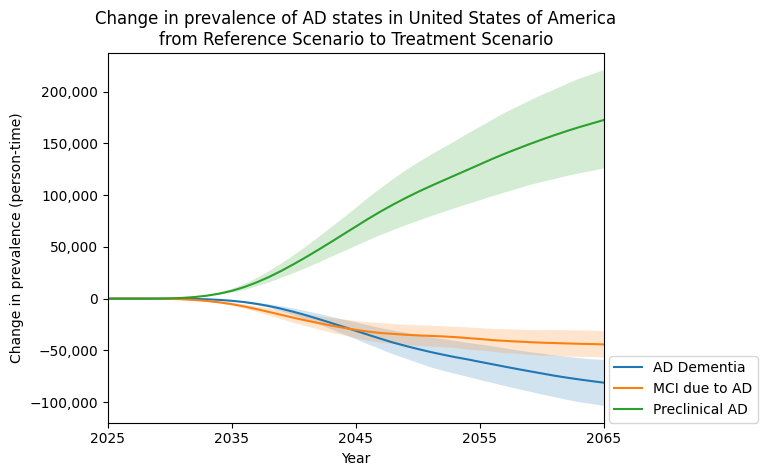

In [ ]:
change_in_prev2 = filter_results(
    res,
    ["Year", "Disease Stage"],
    location=[location],
    age=['65_plus'],
    sex=['Both'],
    scenario=["BBBM Testing and Treatment"],
    measure=["Change in Prevalence from Reference"],
    metric=["Number"],
)
make_forecast_plot(
    change_in_prev2,
    f"Change in prevalence of AD states in {location}\nfrom Reference Scenario to Treatment Scenario",
    "Change in prevalence (person-time)",
    "Disease Stage",
)

In [ ]:
# Record time to see how long notebook takes to run after hitting Run All
!date

Wed Mar 11 15:32:51 PDT 2026
